# Results for Paper "Evaluating the Educational Impact of a Large Language Model (LLM)Based Virtual Assistant in Video-Based Learning"

---

In [5]:
import os, sys
import polars as pl
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable, Independence

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact.educational_impact_analysis import (
    group_stats,
    compute_correlations,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison,
    plot_quant_comparison_faceted,
    plot_quant_scatter,
    plot_quant_pie,
    plot_cat_comparison_faceted,
    plot_cat_comparison_heatmap,
    plot_cat_comparison_faceted_heatmap
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [6]:
forms_interactions_df['group'].value_counts()

group,count
str,u32
"""experimental""",94
"""control""",97


In [7]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
null,100
"""High""",37
"""Low""",25
"""Not Used""",29


In [8]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [9]:
forms_interactions_df['group'].value_counts().filter(pl.col('group') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [10]:
forms_interactions_df.filter(
    pl.col('group') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,improvement_retention_hake_gain,improvement_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,score_tc_pre,…,chat_freq_use_v2,chat_freq_use,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat_v2,WSDI_cat,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,group_segmented_v1,group_segmented_v2,group_segmented_quality,group_segmented_freq_quality,group_segmented_v5,group_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,str,bool,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [11]:
forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,improvement_retention_hake_gain,improvement_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,score_tc_pre,…,chat_freq_use_v2,chat_freq_use,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat_v2,WSDI_cat,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,group_segmented_v1,group_segmented_v2,group_segmented_quality,group_segmented_freq_quality,group_segmented_v5,group_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,str,bool,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,-1.0,"""Low""","""Low""","""Low""",-0.1,0.0,-0.2,"""Low""","""Low""","""Low""",0.41,"""Medium""",0.25,"""Worsen""",false,false,"""Not Improve""","""Worsen""","""Improve""","""Worsenmiento-Alto""","""Worsenmiento-Alto""","""Excellent""","""Very Good-Excellent""","""Very Good-Excellent""","""Very Good-Excellent""","""Very Good""","""Very Good-Excellent""","""Very Good-Excellent""","""Fail-Pass-Good""","""11/03/2026 9:48:45""","""11/03/2026 10:27:34""",0.9,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,38.816667,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.0,"""Low""","""Low""","""Low""",0.0,-0.2,0.0,"""Low""","""Low""","""Low""",0.562,"""High""",0.18,"""Not Improve""",false,false,"""Worsen""","""Not Improve""","""Improve""","""Not Improve""","""Not Improve""","""Very Good""","""Very Good-Excellent""","""Very Good-Excellent""","""Fail-Pass-Good""","""Very Good""","""Very Good-Excellent""","""Fail-Pass-Good""","""Fail-Pass-Good""","""11/03/2026 9:50:39""","""11/03/2026 10:30:02""",0.7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.383333,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Low""","""Low""","""Low""",-0.5,-0.6,-0.4,"""Low""","""Low""","""Low""",0.111,"""Medium""",0.04,"""Worsen""",false,false,"""Worsen""","""Worsen""","""Improve""","""Worsenmiento-Alto""","""Worsenmiento-Alto""","""Good""","""Fail-Pass-Good""","""Very Good-Excellent""","""Fail-Pass-Good""","""Fail""","""Fail-Pass-Good""","""Fail-Pass-Good""","""Fail-Pass-Good""","""1

---

## Descripción general

In [12]:
forms_interactions_df.describe()

statistic,id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,improvement_retention_hake_gain,improvement_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,…,chat_freq_use_v2,chat_freq_use,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat_v2,WSDI_cat,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,group_segmented_v1,group_segmented_v2,group_segmented_quality,group_segmented_freq_quality,group_segmented_v5,group_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,f64,str,str,f64,f64,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,"""191""",191.0,"""191""",191.0,191.0,"""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""",…,"""91""","""91""",62.0,62.0,62.0,62.0,62.0,"""91""","""91""","""91""",62.0,51.0,51.0,"""91""","""91""","""91""","""91""","""91""","""91""","""188""","""188""","""188""","""188""","""188""","""188""",191.0,"""163""","""163""","""163""",163.0,163.0,163.0,"""163""","""163""",163.0,163.0,163.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,"""0""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",…,"""100""","""100""",129.0,129.0,129.0,129.0,129.0,"""100""","""100""","""100""",129.0,140.0,140.0,"""100""","""100""","""100""","""100""","""100""","""100""","""3""","""3""","""3""","""3""","""3""","""3""",0.0,"""28""","""28""","""28""",28.0,28.0,28.0,"""28""","""28""",28.0,28.0,28.0
"""mean""",null,null,null,0.312508,0.209445,0.168932,null,null,null,0.162304,0.125654,0.147644,null,null,null,0.111822,null,0.095707,null,0.717277,0.717277,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,1.737468,1.306452,0.451613,1.080645,0.854839,null,null,null,0.367665,2.176471,0.176471,null,null,null,null,null,null,null,null,null,null,null,null,32.646248,null,null,null,40.399811,-3.678199,2.8075e9,null,null,26842.638037,59652.404908,21326.760736
"""std""",null,null,null,0.632694,0.839672,0.493354,null,null,null,0.21062,0.271684,0.246624,null,null,null,0.826736,null,0.192185,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,0.70161,1.409438,1.096603,1.07579,1.099132,null,null,null,0.351898,1.260252,0.47774,null,null,null,null,null,null,null,null,null,null,null,null,7.847541,null,null,null,0.057662,0.03281

In [13]:
forms_interactions_df.columns

['id',
 'school',
 'group',
 'score_tc_hake_gain',
 'score_tc_retention_hake_gain',
 'score_tc_transfer_hake_gain',
 'score_tc_hake_gain_cat',
 'score_tc_retention_hake_gain_cat',
 'score_tc_transfer_hake_gain_cat',
 'score_tc_units_hake_gain',
 'score_tc_retention_units_hake_gain',
 'score_tc_transfer_units_hake_gain',
 'score_tc_units_hake_gain_cat',
 'score_tc_retention_units_hake_gain_cat',
 'score_tc_transfer_units_hake_gain_cat',
 'score_ta_hake_gain',
 'score_ta_hake_gain_cat',
 'score_ta_units_hake_gain',
 'improvement_hake_gain',
 'improvement_hake_gain_v2',
 'improvement_units_hake_gain',
 'improvement_retention_hake_gain',
 'improvement_transfer_hake_gain',
 'improvement_ta_hake_gain',
 'improvement_levels_hake_gain',
 'improvement_levels_hake_gain_v2',
 'score_tc_cat_trad_scale_pre',
 'score_tc_cat_trad_scale_v2_pre',
 'score_tc_retention_cat_trad_scale_v2_pre',
 'score_tc_transfer_cat_trad_scale_v2_pre',
 'score_tc_cat_trad_scale_post',
 'score_tc_cat_trad_scale_v2_post',


---

## Análisis de resultados


### Definición de variables

In [14]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64, pl.UInt32]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

context_cols = ['school', 'group']

schools_cols = [ 
    'nombre',
    'direccion',
    'curso',
    'lat',
    'lon',
    'seccion_censal',
    'municipio',
    'provincia',
    'mediana_renta_uc_eur',
    'renta_media_hogar_eur',
    'renta_media_persona_eur'
]

time_cols = [col for col in forms_interactions_df.columns if 'temp' in col or 'time' in col]

group_segmented_cols = [ 
    'group_segmented_v1',
    'group_segmented_v2',
    'group_segmented_freq_quality',
    'group_segmented_quality',
    'group_segmented_v5',
    'group_segmented_v6'
]

forms_cols = [col for col in forms_interactions_df.columns if 'score' in col or 'mejora' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + schools_cols + time_cols + group_segmented_cols + ['id']]
chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

### Variables de contexto

### Métricas de Rendimiento Forms

#### TC-Hake

In [15]:
hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' not in col and "tc" in col]
units_hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' in col and "tc" in col]

hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' not in col and 'mejora' not in col and "tc" in col]
units_hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' in col and 'mejora' not in col and "tc" in col]

#### TC-Pre-Post

In [16]:
tc_pre_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col]
tc_pre_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col and 'trad' not in col]

tc_post_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col]
tc_post_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col and  'trad' not in col] 

#### TC-Pre-Post Mejora

#### TA-Pre-Post

In [17]:
ta_quant_cols = [col for col in forms_quant_cols if 'ta_' in col]
ta_cat_cols = [col for col in forms_cat_cols if 'ta_' in col]

#### TCC-Post

In [18]:
tcc_quant_cols = [col for col in forms_quant_cols if 'tcc_' in col]
tcc_cat_cols = [col for col in forms_cat_cols if 'tcc_' in col]

### Métricas Interacciones Herramienta

### Análisis Cruzado 

#### Filtrado de participantes problematicos

In [19]:
q25 = forms_interactions_df['score_tc_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('score_tc_hake_gain') < outliers_lower_bound
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""RamiroMaeztu-86g""","""experimental""",0.8,0.5,-0.3,-1.5
"""RamiroMaeztu-4bc""","""experimental""",0.9,0.6,-0.3,-3.0
"""JesusMaria-ub4""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-yxb""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25
"""Laguna-chk""","""experimental""",0.9,0.6,-0.3,-3.0


In [20]:
q25 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('score_tc_units_hake_gain') < outliers_lower_bound
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25


In [21]:
forms_interactions_df.filter(
    pl.col('score_tc_pre') == 1
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""JoseGarciaNieto-lp9""","""control""",1.0,0.9,0.0,0.0
"""JesusMaria-86o""","""control""",1.0,1.0,0.0,0.0
"""Laguna-o61""","""experimental""",1.0,0.5,0.0,0.0
"""Laguna-yno""","""experimental""",1.0,0.8,0.0,0.0
"""Laguna-9wq""","""experimental""",1.0,0.9,0.0,0.0


In [22]:
forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain', 'chat_freq_use']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain,chat_freq_use
str,str,f64,f64,f64,f64,str
"""JesusMaria-nre""","""experimental""",0.9,0.8,-0.1,-1.0,null
"""JesusMaria-3ci""","""experimental""",0.7,0.7,0.0,0.0,null
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25,null


In [23]:
problematic_ids = forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

q25 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr
problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('score_tc_units_hake_gain') < outliers_lower_bound
)['id'].to_list()

problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('score_tc_pre') == 1
)['id'].to_list()

problematic_ids = list(set(problematic_ids)) + ['JoseGarciaNieto-9ba']

forms_interactions_df = forms_interactions_df.filter(~pl.col('id').is_in(problematic_ids))

In [24]:
problematic_ids

['Laguna-9wq',
 'Laguna-yno',
 'JesusMaria-33y',
 'Laguna-o61',
 'JesusMaria-86o',
 'JoseGarciaNieto-lp9',
 'JesusMaria-nre',
 'JesusMaria-3ci',
 'JoseGarciaNieto-9ba']

In [25]:
#Define paths
plots_path = os.path.join(project_path, 'plots')
os.makedirs(plots_path, exist_ok=True)

## Baseline Results

In [26]:
baseline_path = os.path.join(plots_path, '5_1')
os.makedirs(baseline_path, exist_ok=True)

### TC Pre

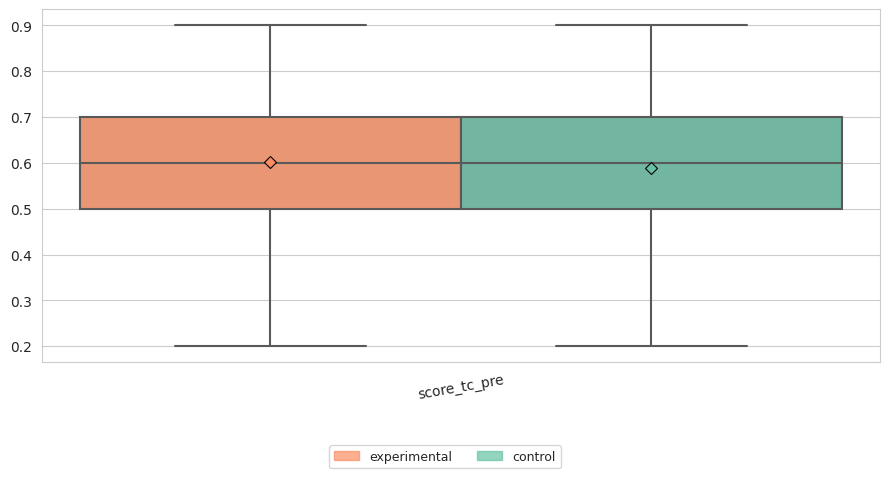

In [27]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(baseline_path, 'tc_pre.pdf')
)

In [28]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME = 'score_tc_pre'
d = df.dropna(subset=[OUTCOME, 'group', 'school']).copy()

# 1 = experimental: beta > 0 y g > 0 significan lo mismo
d['group_binary'] = (d['group'] == 'experimental').astype(int)

e = d.loc[d['group_binary'] == 1, OUTCOME]   # experimental
c = d.loc[d['group_binary'] == 0, OUTCOME]   # control
n1, n2 = len(e), len(c)

# ================== DESCRIPTIVOS ==================
desc = (d.groupby('group')[OUTCOME]
          .agg(n='size', mean='mean', sd='std', median='median',
               q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75),
               min='min', max='max')
          .round(4))
desc['iqr'] = (desc['q3'] - desc['q1']).round(4)
print("--- Descriptivos por condición ---")
print(desc, "\n")

print(f"diferencia de medias   = {e.mean() - c.mean():+.4f}")
print(f"diferencia de medianas = {e.median() - c.median():+.4f}")
print(f"IQR: exp [{e.quantile(.25):.2f}, {e.quantile(.75):.2f}] "
      f"vs ctrl [{c.quantile(.25):.2f}, {c.quantile(.75):.2f}]\n")

print("--- Forma ---")
for lbl, s in [('experimental', e), ('control', c)]:
    print(f"{lbl:<13} skew = {s.skew():+.3f}, kurtosis = {s.kurt():+.3f}, "
          f"valores únicos = {s.nunique()}")

qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("\n--- Cuantiles comparados ---")
print(pd.DataFrame({'exp': e.quantile(qs).round(3),
                    'ctrl': c.quantile(qs).round(3)}), "\n")

# ---- Contexto del ICC: variación entre centros ----
school_means = d.groupby('school')[OUTCOME].mean()
print("--- Media del pre por centro y condición ---")
print(d.pivot_table(index='school', columns='group',
                    values=OUTCOME, aggfunc=['size', 'mean']).round(4), "\n")
print("media por centro:", school_means.round(4).to_dict())
print(f"rango entre centros = {school_means.max() - school_means.min():.4f}\n")

# ================== MODELO M1 ==================
res = smf.mixedlm(f"{OUTCOME} ~ group_binary", data=d,
                  groups=d['school'], re_formula="1").fit(reml=True)

beta, se = res.params['group_binary'], res.bse['group_binary']
p_val = res.pvalues['group_binary']              # Wald z, sin corrección de gl
ci_lo, ci_hi = res.conf_int().loc['group_binary']

var_school, var_resid = float(res.cov_re.iloc[0, 0]), float(res.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

# ---- Hedges' g (descriptivo, no ajustado por clustering) ----
s_pooled = np.sqrt(((n1 - 1) * e.std(ddof=1)**2 + (n2 - 1) * c.std(ddof=1)**2)
                   / (n1 + n2 - 2))
g = ((e.mean() - c.mean()) / s_pooled) * (1 - 3 / (4 * (n1 + n2) - 9))
se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
z = stats.norm.ppf(0.975)

# ---- Salida ----
print("--- Modelo M1 ---")
print(f"n = {n1 + n2} (exp {n1}, ctrl {n2}) | schools = {d['school'].nunique()} "
      f"| converged = {res.converged}")
print(f"beta = {beta:.4f} (SE {se:.4f}, p {p_val:.4f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Hedges' g = {g:.4f} (95% CI [{g - z*se_g:.4f}, {g + z*se_g:.4f}])")

--- Descriptivos por condición ---
               n    mean      sd  median   q1   q3  min  max  iqr
group                                                            
control       95  0.5884  0.1809     0.6  0.5  0.7  0.2  0.9  0.2
experimental  88  0.6011  0.1636     0.6  0.5  0.7  0.2  0.9  0.2 

diferencia de medias   = +0.0127
diferencia de medianas = +0.0000
IQR: exp [0.50, 0.70] vs ctrl [0.50, 0.70]

--- Forma ---
experimental  skew = -0.421, kurtosis = -0.201, valores únicos = 8
control       skew = -0.352, kurtosis = -0.377, valores únicos = 8

--- Cuantiles comparados ---
       exp  ctrl
0.05  0.30  0.27
0.10  0.37  0.30
0.25  0.50  0.50
0.50  0.60  0.60
0.75  0.70  0.70
0.90  0.80  0.80
0.95  0.80  0.90 

--- Media del pre por centro y condición ---
                   size                 mean             
group           control experimental control experimental
school                                                   
JesusMaria           26           22  0.6538       0.5

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


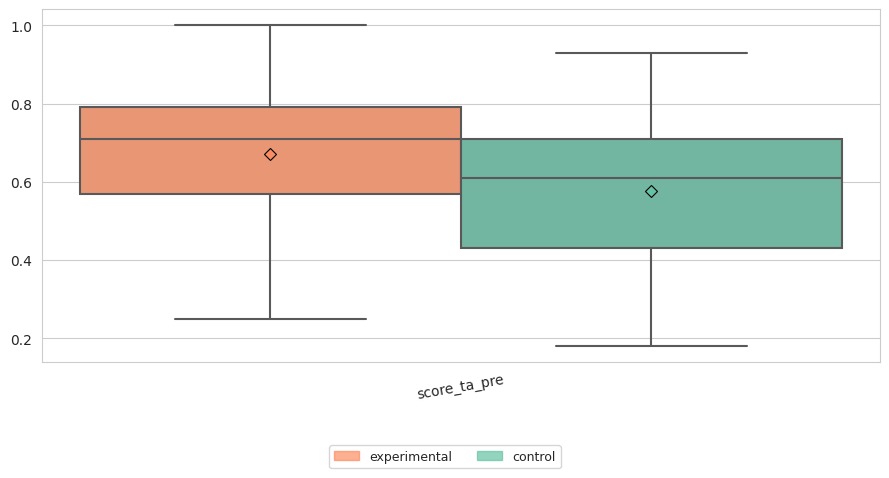

In [29]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_ta_pre"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(baseline_path, 'ta_pre.pdf')
)

In [30]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME = 'score_ta_pre'
d = df.dropna(subset=[OUTCOME, 'group', 'school']).copy()

# 1 = experimental: beta > 0 y g > 0 significan lo mismo
d['group_binary'] = (d['group'] == 'experimental').astype(int)

e = d.loc[d['group_binary'] == 1, OUTCOME]   # experimental
c = d.loc[d['group_binary'] == 0, OUTCOME]   # control
n1, n2 = len(e), len(c)

# ================== DESCRIPTIVOS ==================
desc = (d.groupby('group')[OUTCOME]
          .agg(n='size', mean='mean', sd='std', median='median',
               q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75),
               min='min', max='max')
          .round(4))
desc['iqr'] = (desc['q3'] - desc['q1']).round(4)
print("--- Descriptivos por condición ---")
print(desc, "\n")

print(f"diferencia de medias   = {e.mean() - c.mean():+.4f}")
print(f"diferencia de medianas = {e.median() - c.median():+.4f}")
print(f"IQR: exp [{e.quantile(.25):.3f}, {e.quantile(.75):.3f}] "
      f"vs ctrl [{c.quantile(.25):.3f}, {c.quantile(.75):.3f}]\n")

print("--- Forma ---")
for lbl, s in [('experimental', e), ('control', c)]:
    print(f"{lbl:<13} skew = {s.skew():+.3f}, kurtosis = {s.kurt():+.3f}, "
          f"valores únicos = {s.nunique()}")

qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("\n--- Cuantiles comparados ---")
print(pd.DataFrame({'exp': e.quantile(qs).round(3),
                    'ctrl': c.quantile(qs).round(3)}), "\n")

# ---- Contexto del ICC: variación entre centros ----
school_means = d.groupby('school')[OUTCOME].mean()
print("--- Media por centro y condición ---")
print(d.pivot_table(index='school', columns='group',
                    values=OUTCOME, aggfunc=['size', 'mean']).round(4), "\n")
print("media por centro:", school_means.round(4).to_dict())
print(f"rango entre centros = {school_means.max() - school_means.min():.4f}\n")

# ---- Rango observado de la escala (comprobación del escalado) ----
print(f"rango global observado: [{d[OUTCOME].min():.4f}, {d[OUTCOME].max():.4f}]\n")

# ================== MODELO M1 ==================
res = smf.mixedlm(f"{OUTCOME} ~ group_binary", data=d,
                  groups=d['school'], re_formula="1").fit(reml=True)

beta, se = res.params['group_binary'], res.bse['group_binary']
p_val = res.pvalues['group_binary']              # Wald z, sin corrección de gl
ci_lo, ci_hi = res.conf_int().loc['group_binary']

var_school, var_resid = float(res.cov_re.iloc[0, 0]), float(res.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

# ---- Hedges' g (descriptivo, no ajustado por clustering) ----
s_pooled = np.sqrt(((n1 - 1) * e.std(ddof=1)**2 + (n2 - 1) * c.std(ddof=1)**2)
                   / (n1 + n2 - 2))
g = ((e.mean() - c.mean()) / s_pooled) * (1 - 3 / (4 * (n1 + n2) - 9))
se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
z = stats.norm.ppf(0.975)

# ---- Salida ----
print("--- Modelo M1 ---")
print(f"OUTCOME = {OUTCOME}")
print(f"n = {n1 + n2} (exp {n1}, ctrl {n2}) | schools = {d['school'].nunique()} "
      f"| converged = {res.converged}")
print(f"beta = {beta:.4f} (SE {se:.4f}, p {p_val:.4f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Hedges' g = {g:.4f} (95% CI [{g - z*se_g:.4f}, {g + z*se_g:.4f}])")

--- Descriptivos por condición ---
               n    mean      sd  median    q1    q3   min   max   iqr
group                                                                 
control       95  0.5755  0.1877    0.61  0.43  0.71  0.18  0.93  0.28
experimental  88  0.6703  0.1632    0.71  0.57  0.79  0.25  1.00  0.22 

diferencia de medias   = +0.0949
diferencia de medianas = +0.1000
IQR: exp [0.570, 0.790] vs ctrl [0.430, 0.710]

--- Forma ---
experimental  skew = -0.605, kurtosis = +0.005, valores únicos = 20
control       skew = -0.063, kurtosis = -0.784, valores únicos = 22

--- Cuantiles comparados ---
       exp   ctrl
0.05  0.32  0.278
0.10  0.46  0.320
0.25  0.57  0.430
0.50  0.71  0.610
0.75  0.79  0.710
0.90  0.86  0.820
0.95  0.89  0.860 

--- Media por centro y condición ---
                   size                 mean             
group           control experimental control experimental
school                                                   
JesusMaria           26     

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Experiment Results

### Experimental group

In [31]:
# plot_cat_distribution(
#     df = forms_interactions_df, 
#     cat_cols = [
#         "group"
#     ], 
#     max_cols=2, 
#     palette="Set2",
#     show_counts=True
# )

In [32]:
# plot_cat_distribution(
#     df = forms_interactions_df.filter(pl.col('group') == 'experimental'), 
#     cat_cols = [
#         'experimental_type_freq_quality',
#         'experimental_type_quality',
#         'experimental_type_v6',
#         'chat_freq_use'
#     ], 
#     max_cols=2, 
#     palette="Set2",
#     show_counts=True
# )

### Knowledge

In [33]:
knowledge_path = os.path.join(plots_path, '5_2', '5_2_2')

os.makedirs(knowledge_path, exist_ok=True)

#### Pre-Post Comparison

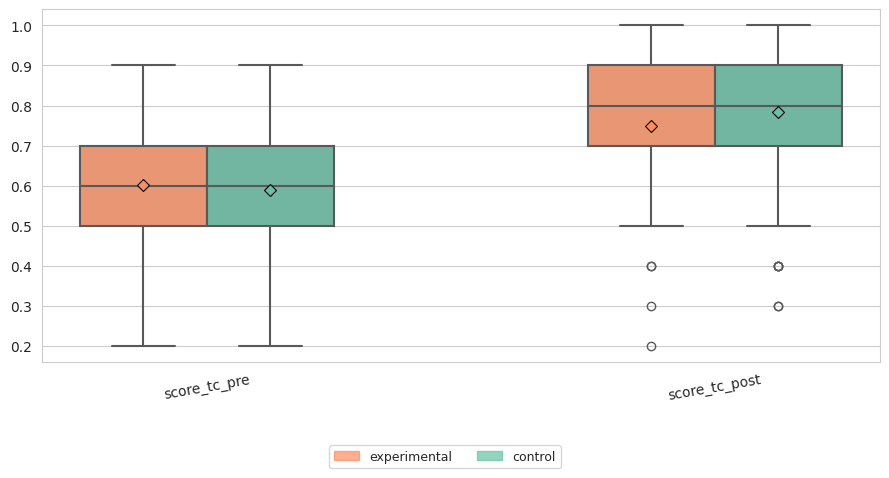

In [34]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_comparison.pdf')
)

In [35]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'
GRP       = 'group'
LEVELS    = ['control', 'experimental']

d = df.dropna(subset=[OUTCOME, COVARIATE, GRP, 'school']).copy()

# 1 = experimental: beta1 > 0 significa ventaja del grupo experimental
d['group_binary'] = (d['group'] == 'experimental').astype(int)

pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean

e = d.loc[d['group_binary'] == 1]   # experimental
c = d.loc[d['group_binary'] == 0]   # control
n1, n2 = len(e), len(c)

# ================== DESCRIPTIVOS GENERALES ==================
print("--- Descriptivos por condición y momento ---")
print((d.melt(id_vars=GRP, value_vars=[COVARIATE, OUTCOME],
              var_name='moment', value_name='score')
         .groupby(['moment', GRP])['score']
         .agg(n='size', mean='mean', sd='std', median='median',
              q1=lambda s: s.quantile(0.25),
              q3=lambda s: s.quantile(0.75),
              min='min', max='max')
         .round(4)), "\n")

print("--- Cambio pre -> post (crudo) ---")
for lbl, s in [('experimental', e), ('control', c)]:
    delta = s[OUTCOME] - s[COVARIATE]
    print(f"{lbl:<13} mean {s[COVARIATE].mean():.3f} -> {s[OUTCOME].mean():.3f} "
          f"(cambio {delta.mean():+.3f}, SD {delta.std(ddof=1):.3f}) | "
          f"median {s[COVARIATE].median():.2f} -> {s[OUTCOME].median():.2f}")
print(f"\ndiferencia entre condiciones en el cambio medio = "
      f"{(e[OUTCOME]-e[COVARIATE]).mean() - (c[OUTCOME]-c[COVARIATE]).mean():+.4f}")
print(f"diferencia en el post (cruda) = "
      f"{e[OUTCOME].mean() - c[OUTCOME].mean():+.4f}\n")

print("--- Dirección del cambio ---")
for lbl, s in [('experimental', e), ('control', c)]:
    delta = s[OUTCOME] - s[COVARIATE]
    print(f"{lbl:<13} mejora {(delta > 0).mean():.1%} | "
          f"igual {(delta == 0).mean():.1%} | empeora {(delta < 0).mean():.1%}")

print("\n--- Techo en el post ---")
for lbl, s in [('experimental', e), ('control', c)]:
    print(f"{lbl:<13} en el máximo (1.0): {(s[OUTCOME] == 1.0).sum()} "
          f"({(s[OUTCOME] == 1.0).mean():.1%}) | "
          f">= 0.9: {(s[OUTCOME] >= 0.9).mean():.1%}")

qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("\n--- Cuantiles del post ---")
print(pd.DataFrame({'exp': e[OUTCOME].quantile(qs).round(3),
                    'ctrl': c[OUTCOME].quantile(qs).round(3)}), "\n")

print(f"correlación pre-post: exp r = {e[COVARIATE].corr(e[OUTCOME]):.3f}, "
      f"ctrl r = {c[COVARIATE].corr(c[OUTCOME]):.3f}\n")

school_means = d.groupby('school')[OUTCOME].mean()
print("--- Media del post por centro y condición ---")
print(d.pivot_table(index='school', columns=GRP,
                    values=OUTCOME, aggfunc=['size', 'mean']).round(4), "\n")
print("media del post por centro:", school_means.round(4).to_dict())
print(f"rango entre centros = {school_means.max() - school_means.min():.4f}\n")


# ================== DESCRIPTIVOS ORIENTADOS A RQ3 ==================
# Caracterizan cómo se relaciona el punto de partida con el resultado final
# dentro de cada grupo, SIN comparar brechas entre extremos (sesgado por
# regresión a la media).
print("=" * 62)
print(f"Descriptivos RQ3 por '{GRP}'")
print("=" * 62)

q33, q67 = d[COVARIATE].quantile([1/3, 2/3])
d['pre_tercile'] = pd.cut(d[COVARIATE], [-np.inf, q33, q67, np.inf],
                          labels=['T1 (low)', 'T2 (mid)', 'T3 (high)'])
print(f"\nCortes de tercil del pre: {q33:.2f} / {q67:.2f}")

print("\n(a) Media del post por grupo y tercil del pre:")
pt = (d.pivot_table(index=GRP, columns='pre_tercile', values=OUTCOME,
                    aggfunc='mean', observed=True).reindex(LEVELS))
print(pt.round(3))
print("\n    n por celda:")
print(pd.crosstab(d[GRP], d['pre_tercile']).reindex(LEVELS))
print("\n    diferencia T3 - T1 en el post (dispersión del resultado final):")
for gname in LEVELS:
    if gname in pt.index:
        print(f"      {gname:<14} {pt.loc[gname,'T3 (high)'] - pt.loc[gname,'T1 (low)']:+.3f}")

print("\n(b) Proporción que mejora (post > pre), por grupo y tercil:")
print(d.assign(improved=(d[OUTCOME] > d[COVARIATE]).astype(float))
       .pivot_table(index=GRP, columns='pre_tercile', values='improved',
                    aggfunc='mean', observed=True)
       .reindex(LEVELS).round(3))

base = smf.ols(f"{OUTCOME} ~ {COVARIATE}", data=d).fit()
d['resid'] = base.resid
print(f"\n(c) Residuo medio respecto a la recta global "
      f"(post = {base.params['Intercept']:.3f} + "
      f"{base.params[COVARIATE]:.3f} x pre), por grupo y tercil:")
print(d.pivot_table(index=GRP, columns='pre_tercile', values='resid',
                    aggfunc='mean', observed=True).reindex(LEVELS).round(3))
print("\n    residuo medio global por grupo:")
print(d.groupby(GRP, observed=True)['resid'].mean().reindex(LEVELS).round(3))

print("\n(d) Correlación pre-post dentro de cada grupo:")
for gname in LEVELS:
    sub = d[d[GRP] == gname]
    if len(sub) > 3:
        print(f"      {gname:<14} n = {len(sub):>3} | r = "
              f"{sub[COVARIATE].corr(sub[OUTCOME]):+.3f}")


# ================== M2: EFECTO AJUSTADO DE LA CONDICIÓN ==================
res = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", data=d,
                  groups=d['school'], re_formula="1").fit(reml=True)

ci1 = res.conf_int().loc['group_binary']
ci2 = res.conf_int().loc['pre_c']
var_school, var_resid = float(res.cov_re.iloc[0, 0]), float(res.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("\n[aviso] varianza de centro prácticamente nula: ajuste singular.")

sp = np.sqrt(((n1 - 1) * e[OUTCOME].std(ddof=1)**2
              + (n2 - 1) * c[OUTCOME].std(ddof=1)**2) / (n1 + n2 - 2))
g = ((e[OUTCOME].mean() - c[OUTCOME].mean()) / sp) * (1 - 3 / (4 * (n1 + n2) - 9))
se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
z = stats.norm.ppf(0.975)

print("\n" + "=" * 62)
print(f"OUTCOME = {OUTCOME} | COVARIATE = {COVARIATE} (mean {pre_mean:.4f})")
print(f"n = {n1+n2} (exp {n1}, ctrl {n2}) | schools = {d['school'].nunique()} "
      f"| converged = {res.converged}")
print("M2:")
print(f"  beta1 (group) = {res.params['group_binary']:+.4f} "
      f"(SE {res.bse['group_binary']:.4f}, p {res.pvalues['group_binary']:.4f}, "
      f"95% CI [{ci1[0]:+.4f}, {ci1[1]:+.4f}])")
print(f"  beta2 (pre_c) = {res.params['pre_c']:+.4f} "
      f"(SE {res.bse['pre_c']:.4f}, p {res.pvalues['pre_c']:.4f}, "
      f"95% CI [{ci2[0]:+.4f}, {ci2[1]:+.4f}])")
print(f"  ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"  Hedges' g (post, unadjusted) = {g:.4f} "
      f"(95% CI [{g - z*se_g:.4f}, {g + z*se_g:.4f}])")


# ================== M3: MODERACIÓN POR CONOCIMIENTO PREVIO (RQ3) ==================
print("\n" + "=" * 62)
print("RQ3: ¿depende el efecto de la condición del conocimiento previo?")
print("=" * 62)

res3 = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", data=d,
                   groups=d['school'], re_formula="1").fit(reml=True)

t = 'group_binary:pre_c'
ci3 = res3.conf_int().loc[t]
print(f"beta3 (group x pre) = {res3.params[t]:+.4f} (SE {res3.bse[t]:.4f}, "
      f"p {res3.pvalues[t]:.4f}, 95% CI [{ci3[0]:+.4f}, {ci3[1]:+.4f}])")
print("  beta3 < 0 -> compensatorio (el experimental ayuda más a quien parte bajo)")
print("  beta3 > 0 -> amplificador (Matthew)")

m2_ml = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", data=d,
                    groups=d['school'], re_formula="1").fit(reml=False)
m3_ml = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", data=d,
                    groups=d['school'], re_formula="1").fit(reml=False)
lr = 2 * (m3_ml.llf - m2_ml.llf)
print(f"LR test M2 vs M3: chi2 = {lr:.4f}, df = 1, p = {stats.chi2.sf(lr,1):.4f}")

print("\nDependencia del resultado final respecto al conocimiento previo:")
for lbl, sub in [('Control', c), ('Experimental', e)]:
    m = smf.mixedlm(f"{OUTCOME} ~ pre_c", sub, groups=sub['school'],
                    re_formula="1").fit(reml=True)
    ci_s = m.conf_int().loc['pre_c']
    print(f"  {lbl:<13} n = {len(sub):>3} | slope = {m.params['pre_c']:+.4f} "
          f"(SE {m.bse['pre_c']:.4f}, p {m.pvalues['pre_c']:.4f}, "
          f"95% CI [{ci_s[0]:+.4f}, {ci_s[1]:+.4f}])")

print("\nDiferencia experimental - control estimada a distintos niveles del pre:")
for q, lbl in [(0.25, 'Q1'), (0.50, 'mediana'), (0.75, 'Q3')]:
    x = d[COVARIATE].quantile(q) - pre_mean
    eff = res3.params['group_binary'] + res3.params[t] * x
    print(f"  {lbl:<8} pre = {d[COVARIATE].quantile(q):.2f} -> "
          f"diferencia estimada = {eff:+.4f}")

print(f"\nMagnitud mínima detectable para beta3 (1.96 x SE) = "
      f"{1.96 * res3.bse[t]:.3f}")

--- Descriptivos por condición y momento ---
                             n    mean      sd  median   q1   q3  min  max
moment        group                                                       
score_tc_post control       95  0.7842  0.1746     0.8  0.7  0.9  0.3  1.0
              experimental  88  0.7489  0.1640     0.8  0.7  0.9  0.2  1.0
score_tc_pre  control       95  0.5884  0.1809     0.6  0.5  0.7  0.2  0.9
              experimental  88  0.6011  0.1636     0.6  0.5  0.7  0.2  0.9 

--- Cambio pre -> post (crudo) ---
experimental  mean 0.601 -> 0.749 (cambio +0.148, SD 0.205) | median 0.60 -> 0.80
control       mean 0.588 -> 0.784 (cambio +0.196, SD 0.206) | median 0.60 -> 0.80

diferencia entre condiciones en el cambio medio = -0.0481
diferencia en el post (cruda) = -0.0353

--- Dirección del cambio ---
experimental  mejora 71.6% | igual 14.8% | empeora 13.6%
control       mejora 77.9% | igual 8.4% | empeora 13.7%

--- Techo en el post ---
experimental  en el máximo (1.0): 8 

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

beta3 (group x pre) = -0.0976 (SE 0.1358, p 0.4725, 95% CI [-0.3638, +0.1687])
  beta3 < 0 -> compensatorio (el experimental ayuda más a quien parte bajo)
  beta3 > 0 -> amplificador (Matthew)
LR test M2 vs M3: chi2 = 0.5284, df = 1, p = 0.4673

Dependencia del resultado final respecto al conocimiento previo:
  Control       n =  95 | slope = +0.2444 (SE 0.0918, p 0.0078, 95% CI [+0.0645, +0.4243])
  Experimental  n =  88 | slope = +0.1951 (SE 0.1078, p 0.0703, 95% CI [-0.0162, +0.4064])

Diferencia experimental - control estimada a distintos niveles del pre:
  Q1       pre = 0.50 -> diferencia estimada = -0.0347
  mediana  pre = 0.60 -> diferencia estimada = -0.0445
  Q3       pre = 0.70 -> diferencia estimada = -0.0542

Magnitud mínima detectable para beta3 (1.96 x SE) = 0.266


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 2.623792
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter spa

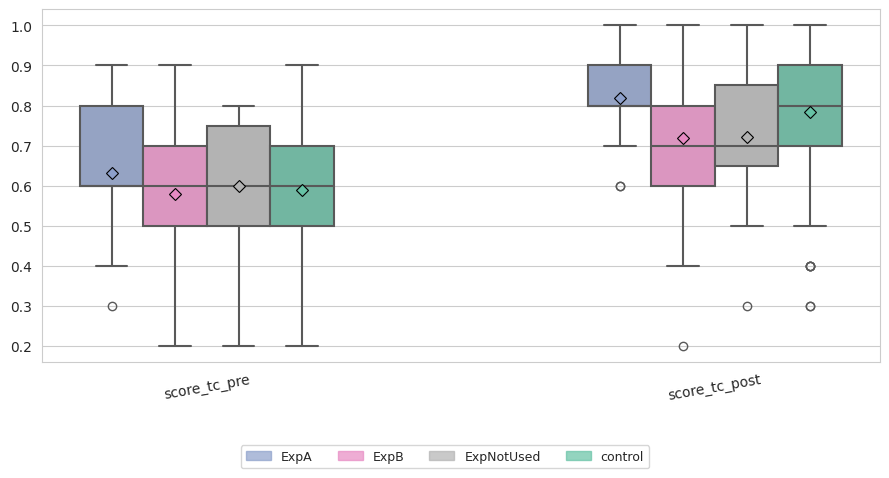

In [36]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_quality.pdf')
)

In [37]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'
GROUP     = 'group_segmented_quality'
ORDER     = ['control', 'ExpA', 'ExpB', 'ExpNotUsed']   # orden de presentación
EXCLUDE   = 'RamiroMaeztu'   # centro que concentra los no usuarios

d = df.dropna(subset=[OUTCOME, COVARIATE, GROUP, 'school']).copy()
d[GROUP] = d[GROUP].astype(str)

pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean
d['delta'] = d[OUTCOME] - d[COVARIATE]

order = [g for g in ORDER if g in d[GROUP].unique()]


# ================== FUNCIONES ==================
def fit_with_reference(data, outcome, group, reference, covariate='pre_c',
                       method=None):
    """Ajusta M2 (o M1 si covariate=None) recodificando la referencia del factor."""
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs = f"{term} + {covariate}" if covariate else term
    model = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
    kw = {'method': method} if method is not None else {}
    return model.fit(reml=True, **kw)


def llf(data, outcome, rhs, method=None):
    """Log-verosimilitud bajo ML, tolerante a Hessianos singulares."""
    m = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                    groups=data['school'], re_formula="1")
    kw = {'method': method} if method is not None else {}
    try:
        return m.fit(reml=False, **kw).llf
    except np.linalg.LinAlgError:
        # Varianza de grupo en la frontera: la verosimilitud sí es calculable.
        return m.fit(reml=False, full_output=False, **kw).llf


def lr_test(data, outcome, rhs_full, rhs_null, df_k, label, method=None):
    lr = 2 * (llf(data, outcome, rhs_full, method)
              - llf(data, outcome, rhs_null, method))
    p = stats.chi2.sf(lr, df_k)
    print(f"{label}: chi2 = {lr:.4f}, df = {df_k}, p = {p:.4f}")
    return lr, p


def print_contrasts(res, reference, label, p_adj=None, interaction=False):
    """Contrastes del factor; interaction=True imprime los términos ':pre_c'."""
    print(f"\n--- {label} (reference = {reference}) ---")
    ci = res.conf_int()
    for name in res.params.index:
        if not name.startswith('C('):
            continue
        if (':pre_c' in name) != interaction:
            continue
        lvl = name.split('[T.')[-1].split(']')[0]
        line = (f"{lvl:<12} beta = {res.params[name]:+.4f} "
                f"(SE {res.bse[name]:.4f}, p {res.pvalues[name]:.4f}, "
                f"95% CI [{ci.loc[name,0]:+.4f}, {ci.loc[name,1]:+.4f}])")
        if p_adj is not None and lvl in p_adj:
            line += f"  |  p_holm = {p_adj[lvl]:.4f}"
        print(line)


def holm_family(res, label):
    """Holm sobre la familia de contrastes frente a la referencia del modelo."""
    names = [n for n in res.params.index
             if n.startswith('C(') and ':pre_c' not in n]
    lvls = [n.split('[T.')[-1].split(']')[0] for n in names]
    ps = [res.pvalues[n] for n in names]
    rej, p_adj, _, _ = multipletests(ps, alpha=0.05, method='holm')
    print(f"\n--- Holm correction ({label}, {len(ps)} contrasts) ---")
    for lvl, p, pa, r in zip(lvls, ps, p_adj, rej):
        print(f"{lvl:<12} p = {p:.4f} -> p_holm = {pa:.4f}{'  *' if r else ''}")
    return dict(zip(lvls, p_adj))


def slopes_by_group(data, outcome, group, levels):
    """Pendiente del pre dentro de cada grupo: menor pendiente = más compensatorio."""
    for lvl in levels:
        sub = data[data[group] == lvl]
        try:
            m = smf.mixedlm(f"{outcome} ~ pre_c", sub, groups=sub['school'],
                            re_formula="1").fit(reml=True)
            ci_s = m.conf_int().loc['pre_c']
            print(f"  {lvl:<12} n = {len(sub):>3} | slope = {m.params['pre_c']:+.4f} "
                  f"(p {m.pvalues['pre_c']:.4f}, "
                  f"95% CI [{ci_s[0]:+.4f}, {ci_s[1]:+.4f}])")
        except Exception as exc:
            print(f"  {lvl:<12} n = {len(sub):>3} | no estimable: {type(exc).__name__}")


# ================== DESCRIPTIVOS ==================
print("--- Descriptivos por grupo ---")
print((d.groupby(GROUP)
         .agg(n=(OUTCOME, 'size'),
              pre_mean=(COVARIATE, 'mean'), pre_sd=(COVARIATE, 'std'),
              pre_median=(COVARIATE, 'median'),
              post_mean=(OUTCOME, 'mean'), post_sd=(OUTCOME, 'std'),
              post_median=(OUTCOME, 'median'),
              change=('delta', 'mean'), change_sd=('delta', 'std'))
         .reindex(order).round(4)), "\n")

print("--- Cuartiles por grupo ---")
print((d.groupby(GROUP)[[COVARIATE, OUTCOME]]
         .quantile([0.25, 0.5, 0.75]).unstack().reindex(order).round(3)), "\n")

print("--- Dirección del cambio ---")
print((d.groupby(GROUP)['delta']
         .agg(improve=lambda s: (s > 0).mean(),
              same=lambda s: (s == 0).mean(),
              worsen=lambda s: (s < 0).mean())
         .reindex(order).round(3)), "\n")

print("--- Techo en el post ---")
print((d.groupby(GROUP)[OUTCOME]
         .agg(at_max=lambda s: (s == 1.0).mean(),
              ge_09=lambda s: (s >= 0.9).mean())
         .reindex(order).round(3)), "\n")

print("--- Distribución de los estratos por centro ---")
print(pd.crosstab(d['school'], d[GROUP]).reindex(columns=order), "\n")


# ================== M2: POST AJUSTADO POR EL PRE ==================
res_ctrl = fit_with_reference(d, OUTCOME, GROUP, 'control')
res_expa = fit_with_reference(d, OUTCOME, GROUP, 'ExpA')

var_school, var_resid = float(res_ctrl.cov_re.iloc[0, 0]), float(res_ctrl.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

term = f"C({GROUP}, Treatment(reference='control'))"
k_df = d[GROUP].nunique() - 1

print("=" * 62)
print(f"OUTCOME = {OUTCOME} | COVARIATE = {COVARIATE} (mean {pre_mean:.4f})")
print(f"n = {len(d)} | schools = {d['school'].nunique()} "
      f"| converged = {res_ctrl.converged}")
print(f"group sizes: {d[GROUP].value_counts().reindex(order).to_dict()}")

p_holm_post = holm_family(res_ctrl, "POST, vs control")
print_contrasts(res_ctrl, 'control', 'POST, adjusted for prior knowledge',
                p_adj=p_holm_post)
print_contrasts(res_expa, 'ExpA', 'POST, adjusted for prior knowledge '
                                  '(secondary contrasts, no multiplicity correction)')

print(f"\npre_c beta = {res_ctrl.params['pre_c']:+.4f} "
      f"(SE {res_ctrl.bse['pre_c']:.4f}, p {res_ctrl.pvalues['pre_c']:.4f})")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
lr_test(d, OUTCOME, f"{term} + pre_c", "pre_c", k_df, "Omnibus LR test (POST)")


# ================== M1: DIFERENCIAS BASALES ENTRE ESTRATOS ==================
res_pre_ctrl = fit_with_reference(d, COVARIATE, GROUP, 'control', covariate=None)
res_pre_expa = fit_with_reference(d, COVARIATE, GROUP, 'ExpA', covariate=None)

p_holm_pre = holm_family(res_pre_ctrl, "PRE, vs control")
print_contrasts(res_pre_ctrl, 'control', 'PRE, baseline differences (M1)',
                p_adj=p_holm_pre)
print_contrasts(res_pre_expa, 'ExpA', 'PRE, baseline differences (M1) '
                                      '(secondary contrasts)')
print()
lr_test(d, COVARIATE, term, "1", k_df, "Omnibus LR test (PRE)")


# ================== ROBUSTEZ ==================
print("\n--- Robustez del modelo PRE frente al optimizador ---")
for m in [None, ['lbfgs', 'bfgs', 'cg'], ['cg', 'bfgs'], ['powell', 'bfgs']]:
    lbl = 'default' if m is None else '+'.join(m)
    try:
        r = fit_with_reference(d, COVARIATE, GROUP, 'control',
                               covariate=None, method=m)
        betas = {n.split('[T.')[-1].split(']')[0]: round(r.params[n], 4)
                 for n in r.params.index if n.startswith('C(')}
        print(f"{lbl:<18} converged={r.converged} "
              f"| var_school={float(r.cov_re.iloc[0,0]):.6f} | betas={betas}")
    except Exception as exc:
        print(f"{lbl:<18} falló: {type(exc).__name__}: {exc}")

d_sens = d[d['school'] != EXCLUDE]
res_sens = fit_with_reference(d_sens, OUTCOME, GROUP, 'control')
print(f"\n[sensibilidad] n = {len(d_sens)} | "
      f"tamaños: {d_sens[GROUP].value_counts().reindex(order).to_dict()}")
print_contrasts(res_sens, 'control', f'POST, excluding {EXCLUDE}')


# ================== DESCRIPTIVOS ORIENTADOS A RQ3 ==================
# Complementan la moderación modelizada más abajo. Los terciles se calculan
# sobre la muestra completa, de modo que las celdas son comparables entre
# estratos. Con celdas de 6 a 10 estudiantes, son indicativos, no estimaciones.
print("\n" + "=" * 62)
print(f"Descriptivos RQ3 por '{GROUP}'")
print("=" * 62)

q33, q67 = d[COVARIATE].quantile([1/3, 2/3])
d['pre_tercile'] = pd.cut(d[COVARIATE], [-np.inf, q33, q67, np.inf],
                          labels=['T1 (low)', 'T2 (mid)', 'T3 (high)'])
print(f"\nCortes de tercil del pre: {q33:.2f} / {q67:.2f}")

print("\n(a) Media del post por grupo y tercil del pre:")
pt = (d.pivot_table(index=GROUP, columns='pre_tercile', values=OUTCOME,
                    aggfunc='mean', observed=True).reindex(order))
print(pt.round(3))
print("\n    n por celda:")
print(pd.crosstab(d[GROUP], d['pre_tercile']).reindex(order))
print("\n    diferencia T3 - T1 en el post (dispersión del resultado final):")
for gname in order:
    if gname in pt.index and pt.loc[gname].notna().all():
        print(f"      {gname:<14} "
              f"{pt.loc[gname,'T3 (high)'] - pt.loc[gname,'T1 (low)']:+.3f}")

print("\n(b) Proporción que mejora (post > pre), por grupo y tercil:")
print(d.assign(improved=(d[OUTCOME] > d[COVARIATE]).astype(float))
       .pivot_table(index=GROUP, columns='pre_tercile', values='improved',
                    aggfunc='mean', observed=True)
       .reindex(order).round(3))

base = smf.ols(f"{OUTCOME} ~ {COVARIATE}", data=d).fit()
d['resid'] = base.resid
print(f"\n(c) Residuo medio respecto a la recta global "
      f"(post = {base.params['Intercept']:.3f} + "
      f"{base.params[COVARIATE]:.3f} x pre), por grupo y tercil:")
print(d.pivot_table(index=GROUP, columns='pre_tercile', values='resid',
                    aggfunc='mean', observed=True).reindex(order).round(3))
print("\n    residuo medio global por grupo:")
print(d.groupby(GROUP, observed=True)['resid'].mean().reindex(order).round(3))

print("\n(b2) Proporción que empeora (post < pre), por grupo y tercil:")
print(d.assign(worsened=(d[OUTCOME] < d[COVARIATE]).astype(float))
       .pivot_table(index=GROUP, columns='pre_tercile', values='worsened',
                    aggfunc='mean', observed=True)
       .reindex(order).round(3))
print("\n    global por grupo:")
print(d.assign(worsened=(d[OUTCOME] < d[COVARIATE]).astype(float))
       .groupby(GROUP, observed=True)['worsened'].mean()
       .reindex(order).round(3))

print("\n    global por grupo (mejora):")
print(d.assign(improved=(d[OUTCOME] > d[COVARIATE]).astype(float))
       .groupby(GROUP, observed=True)['improved'].mean()
       .reindex(order).round(3))

print("\n(d) Correlación pre-post dentro de cada grupo:")
for gname in order:
    sub = d[d[GROUP] == gname]
    if len(sub) > 3:
        print(f"      {gname:<14} n = {len(sub):>3} | r = "
              f"{sub[COVARIATE].corr(sub[OUTCOME]):+.3f}")
        
# ================== RQ3: MODERACIÓN POR CONOCIMIENTO PREVIO ==================
print("\n" + "=" * 62)
print("RQ3: ¿algún perfil es compensatorio o amplificador?")
print("=" * 62)

mi = smf.mixedlm(f"{OUTCOME} ~ {term} * pre_c", data=d,
                 groups=d['school'], re_formula="1").fit(reml=True)

print_contrasts(mi, 'control',
                'Interactions (beta < 0 = more compensatory than control)',
                interaction=True)
print()
lr_test(d, OUTCOME, f"{term} * pre_c", f"{term} + pre_c", k_df,
        "LR test (interaction block)")

print("\nDependencia del resultado final respecto al conocimiento previo, por grupo:")
slopes_by_group(d, OUTCOME, GROUP, order)

print("\nMagnitud mínima detectable por contraste (1.96 x SE):")
for name in mi.params.index:
    if name.startswith('C(') and ':pre_c' in name:
        lvl = name.split('[T.')[-1].split(']')[0]
        print(f"  {lvl:<12} |beta| > {1.96 * mi.bse[name]:.3f}")

--- Descriptivos por grupo ---
                          n  pre_mean  pre_sd  pre_median  post_mean  post_sd  \
group_segmented_quality                                                         
control                  95    0.5884  0.1809         0.6     0.7842   0.1746   
ExpA                     25    0.6320  0.1492         0.6     0.8200   0.1080   
ExpB                     36    0.5806  0.1754         0.6     0.7194   0.1802   
ExpNotUsed               27    0.6000  0.1617         0.6     0.7222   0.1695   

                         post_median  change  change_sd  
group_segmented_quality                                  
control                          0.8  0.1958     0.2062  
ExpA                             0.8  0.1880     0.1787  
ExpB                             0.7  0.1389     0.2321  
ExpNotUsed                       0.7  0.1222     0.1888   

--- Cuartiles por grupo ---
                        score_tc_pre            score_tc_post           
                               

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(

Omnibus LR test (POST): chi2 = 8.7348, df = 3, p = 0.0330


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat


--- Holm correction (PRE, vs control, 3 contrasts) ---
ExpA         p = 0.3002 -> p_holm = 0.9005
ExpB         p = 0.8637 -> p_holm = 1.0000
ExpNotUsed   p = 0.9363 -> p_holm = 1.0000

--- PRE, baseline differences (M1) (reference = control) ---
ExpA         beta = +0.0401 (SE 0.0387, p 0.3002, 95% CI [-0.0357, +0.1158])  |  p_holm = 0.9005
ExpB         beta = -0.0057 (SE 0.0332, p 0.8637, 95% CI [-0.0707, +0.0593])  |  p_holm = 1.0000
ExpNotUsed   beta = +0.0031 (SE 0.0382, p 0.9363, 95% CI [-0.0718, +0.0779])  |  p_holm = 1.0000

--- PRE, baseline differences (M1) (secondary contrasts) (reference = ExpA) ---
ExpB         beta = -0.0457 (SE 0.0444, p 0.3031, 95% CI [-0.1328, +0.0413])
ExpNotUsed   beta = -0.0370 (SE 0.0495, p 0.4547, 95% CI [-0.1340, +0.0600])
control      beta = -0.0401 (SE 0.0387, p 0.3002, 95% CI [-0.1158, +0.0357])

Omnibus LR test (PRE): chi2 = 1.3271, df = 3, p = 0.7227

--- Robustez del modelo PRE frente al optimizador ---
default            converged=True | v

...

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat


--- Interactions (beta < 0 = more compensatory than control) (reference = control) ---
ExpA         beta = -0.3699 (SE 0.2298, p 0.1075, 95% CI [-0.8204, +0.0806])
ExpB         beta = -0.1176 (SE 0.1747, p 0.5009, 95% CI [-0.4599, +0.2248])
ExpNotUsed   beta = +0.0301 (SE 0.2065, p 0.8840, 95% CI [-0.3747, +0.4349])



/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

LR test (interaction block): chi2 = 2.7003, df = 3, p = 0.4402

Dependencia del resultado final respecto al conocimiento previo, por grupo:
  control      n =  95 | slope = +0.2444 (p 0.0078, 95% CI [+0.0645, +0.4243])
  ExpA         n =  25 | slope = +0.0447 (p 0.7613, 95% CI [-0.2436, +0.3330])
  ExpB         n =  36 | slope = +0.1320 (p 0.4541, 95% CI [-0.2137, +0.4778])
  ExpNotUsed   n =  27 | slope = +0.3602 (p 0.0874, 95% CI [-0.0529, +0.7734])

Magnitud mínima detectable por contraste (1.96 x SE):
  ExpA         |beta| > 0.450
  ExpB         |beta| > 0.342
  ExpNotUsed   |beta| > 0.405


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.759996
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter spa

In [38]:
if 'score_tc_cat_pre' in d.columns:
    print("\n    coincidencia con score_tc_cat_pre:")
    print(pd.crosstab(d['pre_tercile'], d['score_tc_cat_pre']))


    coincidencia con score_tc_cat_pre:
score_tc_cat_pre  High  Low  Medium
pre_tercile                        
T1 (low)             0   63       0
T2 (mid)             0    0      82
T3 (high)           38    0       0


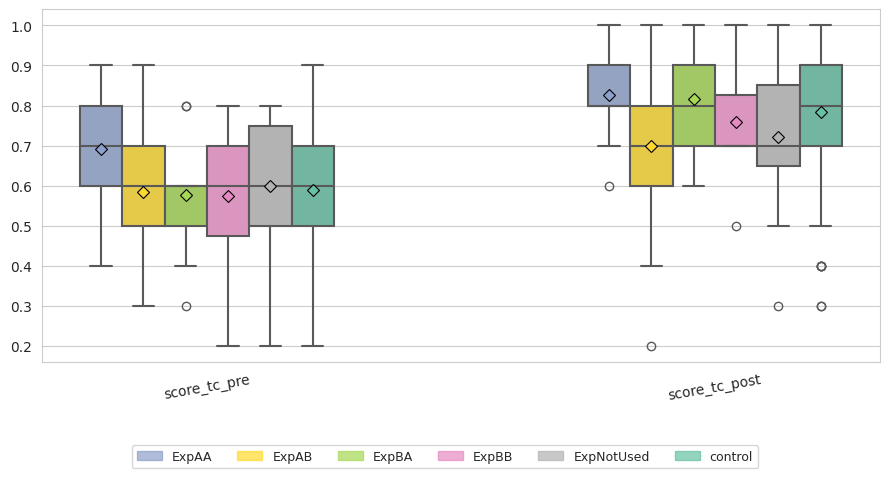

In [39]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group_segmented_freq_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_freq_quality.pdf')
)

In [40]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'
GROUP     = 'group_segmented_freq_quality'
ORDER     = ['control', 'ExpAA', 'ExpBA', 'ExpAB', 'ExpBB', 'ExpNotUsed']

d = df.dropna(subset=[OUTCOME, COVARIATE, GROUP, 'school']).copy()
d[GROUP] = d[GROUP].astype(str)

pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean
d['delta'] = d[OUTCOME] - d[COVARIATE]

order = [g for g in ORDER if g in d[GROUP].unique()]
missing = set(d[GROUP].unique()) - set(ORDER)
if missing:
    print(f"[aviso] niveles no contemplados en ORDER: {missing}\n")

# ================== DESCRIPTIVOS ==================
print("--- Descriptivos por grupo ---")
desc = (d.groupby(GROUP)
          .agg(n=(OUTCOME, 'size'),
               pre_mean=(COVARIATE, 'mean'), pre_sd=(COVARIATE, 'std'),
               pre_median=(COVARIATE, 'median'),
               post_mean=(OUTCOME, 'mean'), post_sd=(OUTCOME, 'std'),
               post_median=(OUTCOME, 'median'),
               change=('delta', 'mean'), change_sd=('delta', 'std'))
          .reindex(order).round(4))
print(desc, "\n")

print("--- Cuartiles por grupo ---")
qt = (d.groupby(GROUP)[[COVARIATE, OUTCOME]]
        .quantile([0.25, 0.5, 0.75]).unstack().reindex(order).round(3))
print(qt, "\n")

print("--- Dirección del cambio ---")
dirn = (d.groupby(GROUP)['delta']
          .agg(improve=lambda s: (s > 0).mean(),
               same=lambda s: (s == 0).mean(),
               worsen=lambda s: (s < 0).mean())
          .reindex(order).round(3))
print(dirn, "\n")

print("--- Techo en el post ---")
ceil = (d.groupby(GROUP)[OUTCOME]
          .agg(at_max=lambda s: (s == 1.0).mean(),
               ge_09=lambda s: (s >= 0.9).mean())
          .reindex(order).round(3))
print(ceil, "\n")

print("--- Distribución de los estratos por centro ---")
print(pd.crosstab(d['school'], d[GROUP]).reindex(columns=order), "\n")


# ================== MODELOS ==================
def fit_with_reference(data, outcome, group, reference, covariate='pre_c',
                       method=None):
    """Ajusta M2 (o M1 si covariate=None) recodificando la referencia del factor."""
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs = f"{term} + {covariate}" if covariate else term
    model = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
    kw = {'method': method} if method is not None else {}
    return model.fit(reml=True, **kw)


def omnibus(data, outcome, group, covariate=None, method=None,
            reference='control'):
    """LR test del factor de grupo; invariante a la referencia. Requiere ML."""
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs_full = f"{term} + {covariate}" if covariate else term
    rhs_null = covariate if covariate else "1"
    kw = {'method': method} if method is not None else {}

    def _llf(rhs):
        m = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
        try:
            return m.fit(reml=False, **kw).llf
        except np.linalg.LinAlgError:
            return m.fit(reml=False, full_output=False, **kw).llf

    lr = 2 * (_llf(rhs_full) - _llf(rhs_null))
    k = data[group].nunique() - 1
    return lr, k, stats.chi2.sf(lr, k)


def print_contrasts(res, reference, label, p_adj=None):
    print(f"\n--- {label} (reference = {reference}) ---")
    ci = res.conf_int()
    for name in res.params.index:
        if name.startswith('C('):
            lvl = name.split('[T.')[-1].rstrip(']')
            line = (f"{lvl:<12} beta = {res.params[name]:+.4f} "
                    f"(SE {res.bse[name]:.4f}, p {res.pvalues[name]:.4f}, "
                    f"95% CI [{ci.loc[name,0]:+.4f}, {ci.loc[name,1]:+.4f}])")
            if p_adj is not None and lvl in p_adj:
                line += f"  |  p_holm = {p_adj[lvl]:.4f}"
            print(line)


def holm_family(res, label):
    names = [n for n in res.params.index if n.startswith('C(')]
    lvls = [n.split('[T.')[-1].rstrip(']') for n in names]
    ps = [res.pvalues[n] for n in names]
    rej, p_adj, _, _ = multipletests(ps, alpha=0.05, method='holm')
    print(f"\n--- Holm correction ({label}, {len(ps)} contrasts) ---")
    for lvl, p, pa, r in zip(lvls, ps, p_adj, rej):
        print(f"{lvl:<12} p = {p:.4f} -> p_holm = {pa:.4f}{'  *' if r else ''}")
    return dict(zip(lvls, p_adj))


# ---- POST ajustado por el pre (M2) ----
res_ctrl = fit_with_reference(d, OUTCOME, GROUP, 'control')

var_school, var_resid = float(res_ctrl.cov_re.iloc[0, 0]), float(res_ctrl.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

lr, k_df, p_omni = omnibus(d, OUTCOME, GROUP, covariate='pre_c')

print("=" * 60)
print(f"OUTCOME = {OUTCOME} | COVARIATE = {COVARIATE} (mean {pre_mean:.4f})")
print(f"n = {len(d)} | schools = {d['school'].nunique()} "
      f"| converged = {res_ctrl.converged}")
print(f"group sizes: {d[GROUP].value_counts().reindex(order).to_dict()}")

p_holm_post = holm_family(res_ctrl, "POST, vs control")
print_contrasts(res_ctrl, 'control', 'POST, adjusted for prior knowledge',
                p_adj=p_holm_post)

print(f"\npre_c beta = {res_ctrl.params['pre_c']:.4f} "
      f"(SE {res_ctrl.bse['pre_c']:.4f}, p {res_ctrl.pvalues['pre_c']:.4f})")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Omnibus LR test (POST): LR = {lr:.4f}, df = {k_df}, p = {p_omni:.4f}")

# Referencia secundaria: el estrato de mayor calidad y mayor frecuencia
if 'ExpAA' in order:
    res_expaa = fit_with_reference(d, OUTCOME, GROUP, 'ExpAA')
    print_contrasts(res_expaa, 'ExpAA', 'POST (secondary, unadjusted)')


# ---- PRE: ¿difieren los estratos en el punto de partida? (M1) ----
res_pre_ctrl = fit_with_reference(d, COVARIATE, GROUP, 'control', covariate=None)
lr_p, k_p, p_omni_pre = omnibus(d, COVARIATE, GROUP, covariate=None)

p_holm_pre = holm_family(res_pre_ctrl, "PRE, vs control")
print_contrasts(res_pre_ctrl, 'control', 'PRE, baseline differences (M1)',
                p_adj=p_holm_pre)
print(f"\nOmnibus LR test (PRE): LR = {lr_p:.4f}, df = {k_p}, p = {p_omni_pre:.4f}")


# ---- Contraste dirigido: ¿importa la frecuencia dentro de cada nivel de calidad? ----
# Compara ExpAA vs ExpBA (alta calidad, alta vs baja frecuencia)
#       y ExpAB vs ExpBB (baja calidad, alta vs baja frecuencia)
print("\n--- Efecto de la frecuencia dentro de cada nivel de calidad ---")
for ref, other, lbl in [('ExpBA', 'ExpAA', 'high quality: high vs low frequency'),
                        ('ExpBB', 'ExpAB', 'low quality: high vs low frequency')]:
    if ref in order and other in order:
        r = fit_with_reference(d, OUTCOME, GROUP, ref)
        name = [n for n in r.params.index
                if n.startswith('C(') and n.endswith(f'[T.{other}]')]
        if name:
            n0 = name[0]
            ci = r.conf_int().loc[n0]
            print(f"{lbl:<38} {other} vs {ref}: beta = {r.params[n0]:+.4f} "
                  f"(p {r.pvalues[n0]:.4f}, 95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}])")

--- Descriptivos por grupo ---
                               n  pre_mean  pre_sd  pre_median  post_mean  \
group_segmented_freq_quality                                                
control                       95    0.5884  0.1809         0.6     0.7842   
ExpAA                         12    0.6917  0.1443         0.7     0.8250   
ExpBA                         13    0.5769  0.1363         0.6     0.8154   
ExpAB                         24    0.5833  0.1711         0.6     0.7000   
ExpBB                         12    0.5750  0.1913         0.6     0.7583   
ExpNotUsed                    27    0.6000  0.1617         0.6     0.7222   

                              post_sd  post_median  change  change_sd  
group_segmented_freq_quality                                           
control                        0.1746          0.8  0.1958     0.2062  
ExpAA                          0.1055          0.8  0.1333     0.1723  
ExpBA                          0.1144          0.8  0.2385     0

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

OUTCOME = score_tc_post | COVARIATE = score_tc_pre (mean 0.5945)
n = 183 | schools = 4 | converged = True
group sizes: {'control': 95, 'ExpAA': 12, 'ExpBA': 13, 'ExpAB': 24, 'ExpBB': 12, 'ExpNotUsed': 27}

--- Holm correction (POST, vs control, 5 contrasts) ---
ExpAA        p = 0.8193 -> p_holm = 1.0000
ExpAB        p = 0.0142 -> p_holm = 0.0712
ExpBA        p = 0.6931 -> p_holm = 1.0000
ExpBB        p = 0.8296 -> p_holm = 1.0000
ExpNotUsed   p = 0.0279 -> p_holm = 0.1116

--- POST, adjusted for prior knowledge (reference = control) ---
ExpAA        beta = +0.0110 (SE 0.0481, p 0.8193, 95% CI [-0.0833, +0.1053])  |  p_holm = 1.0000
ExpAB        beta = -0.0859 (SE 0.0350, p 0.0142, 95% CI [-0.1545, -0.0172])  |  p_holm = 0.0712
ExpBA        beta = +0.0180 (SE 0.0457, p 0.6931, 95% CI [-0.0715, +0.1075])  |  p_holm = 1.0000
ExpBB        beta = -0.0101 (SE 0.0469, p 0.8296, 95% CI [-0.1021, +0.0819])  |  p_holm = 1.0000
ExpNotUsed   beta = -0.0763 (SE 0.0347, p 0.0279, 95% CI [-0.1443, -0

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


--- Holm correction (PRE, vs control, 5 contrasts) ---
ExpAA        p = 0.0516 -> p_holm = 0.2578
ExpAB        p = 0.9114 -> p_holm = 1.0000
ExpBA        p = 0.7486 -> p_holm = 1.0000
ExpBB        p = 0.8778 -> p_holm = 1.0000
ExpNotUsed   p = 0.9553 -> p_holm = 1.0000

--- PRE, baseline differences (M1) (reference = control) ---
ExpAA        beta = +0.1019 (SE 0.0524, p 0.0516, 95% CI [-0.0007, +0.2046])  |  p_holm = 0.2578
ExpAB        beta = -0.0043 (SE 0.0386, p 0.9114, 95% CI [-0.0800, +0.0714])  |  p_holm = 1.0000
ExpBA        beta = -0.0161 (SE 0.0502, p 0.7486, 95% CI [-0.1146, +0.0824])  |  p_holm = 1.0000
ExpBB        beta = -0.0080 (SE 0.0518, p 0.8778, 95% CI [-0.1095, +0.0936])  |  p_holm = 1.0000
ExpNotUsed   beta = +0.0021 (SE 0.0381, p 0.9553, 95% CI [-0.0725, +0.0768])  |  p_holm = 1.0000

Omnibus LR test (PRE): LR = 4.4212, df = 5, p = 0.4905

--- Efecto de la frecuencia dentro de cada nivel de calidad ---
high quality: high vs low frequency    ExpAA vs ExpBA: beta =

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


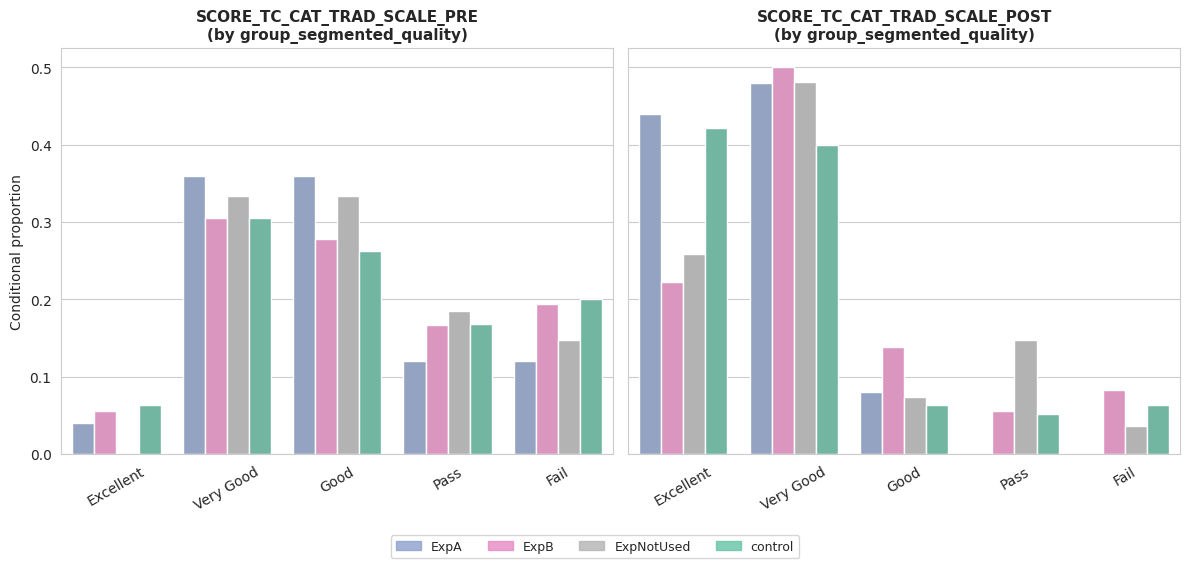

In [41]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['score_tc_cat_trad_scale_pre'], ['score_tc_cat_trad_scale_post'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.14),
    group_by='group_segmented_quality',
    sharey=True,
    order=['Excellent', 'Very Good', 'Good', 'Pass', 'Fail'],
    subplots_title=True,
    save_path=os.path.join(knowledge_path, 'pre_post_trad_scale.pdf')
)

In [42]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

PRE_CAT   = 'score_tc_cat_trad_scale_pre'
POST_CAT  = 'score_tc_cat_trad_scale_post'
GROUP     = 'group_segmented_quality'
ORDER     = ['control', 'ExpA', 'ExpB', 'ExpNotUsed']
LEVELS    = ['Fail', 'Pass', 'Good', 'Very Good', 'Excellent']   # de peor a mejor

d = df.dropna(subset=[PRE_CAT, POST_CAT, GROUP, 'school']).copy()
d[GROUP] = d[GROUP].astype(str)
order = [g for g in ORDER if g in d[GROUP].unique()]

d['pass_pre']  = (~d[PRE_CAT].isin(['Fail', 'Pass'])).astype(int)
d['pass_post'] = (~d[POST_CAT].isin(['Fail', 'Pass'])).astype(int)
d['high_pre']  = d[PRE_CAT].isin(['Very Good', 'Excellent']).astype(int)
d['high_post'] = d[POST_CAT].isin(['Very Good', 'Excellent']).astype(int)

# ================== DESCRIPTIVOS ==================
print("--- Distribución de grados (proporciones por grupo) ---")
for lbl, col in [('PRE', PRE_CAT), ('POST', POST_CAT)]:
    tab = (pd.crosstab(d[GROUP], d[col], normalize='index')
             .reindex(index=order, columns=LEVELS).round(3))
    print(f"\n{lbl}:\n{tab}")

print("\n--- Recuentos absolutos (POST) ---")
print(pd.crosstab(d[GROUP], d[POST_CAT]).reindex(index=order, columns=LEVELS), "\n")

print("--- Umbrales binarios (proporciones) ---")
thr = (d.groupby(GROUP)[['pass_pre', 'pass_post', 'high_pre', 'high_post']]
         .mean().reindex(order).round(3))
thr['n'] = d.groupby(GROUP).size().reindex(order)
print(thr, "\n")

print("--- Movimiento de categoría (pre -> post) ---")
rank = {lvl: i for i, lvl in enumerate(LEVELS)}
d['cat_move'] = d[POST_CAT].map(rank) - d[PRE_CAT].map(rank)
mv = (d.groupby(GROUP)['cat_move']
        .agg(up=lambda s: (s > 0).mean(),
             same=lambda s: (s == 0).mean(),
             down=lambda s: (s < 0).mean(),
             mean_shift='mean')
        .reindex(order).round(3))
print(mv, "\n")


# ================== MODELOS ==================
# Regresión de Poisson modificada (GEE, enlace log, errores robustos):
# estima riesgos relativos, preferibles al OR con desenlaces frecuentes.
# El umbral de aprobado no es modelable (0% de ExpA por debajo -> separación completa).
def fit_gee(data, outcome, group, reference, covariate='high_pre',
            family='poisson', cov='exchangeable'):
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs = f"{term} + {covariate}" if covariate else term
    fam = (sm.families.Poisson() if family == 'poisson'
           else sm.families.Binomial())
    cs = Exchangeable() if cov == 'exchangeable' else Independence()
    return GEE.from_formula(f"{outcome} ~ {rhs}", groups='school', data=data,
                            family=fam, cov_struct=cs).fit()


def print_gee(res, reference, label, measure='RR', p_adj=None):
    print(f"\n--- {label} (reference = {reference}) ---")
    ci = res.conf_int()
    for name in res.params.index:
        if name.startswith('C('):
            lvl = name.split('[T.')[-1].rstrip(']')
            est, lo, hi = (np.exp(res.params[name]),
                           np.exp(ci.loc[name, 0]), np.exp(ci.loc[name, 1]))
            line = (f"{lvl:<12} beta = {res.params[name]:+.4f} | "
                    f"{measure} = {est:.3f} (95% CI [{lo:.3f}, {hi:.3f}]) | "
                    f"p = {res.pvalues[name]:.4f}")
            if p_adj is not None and lvl in p_adj:
                line += f"  |  p_holm = {p_adj[lvl]:.4f}"
            print(line)


def holm_gee(res, label):
    names = [n for n in res.params.index if n.startswith('C(')]
    lvls = [n.split('[T.')[-1].rstrip(']') for n in names]
    ps = [res.pvalues[n] for n in names]
    _, p_adj, _, _ = multipletests(ps, alpha=0.05, method='holm')
    print(f"\n--- Holm correction ({label}, {len(ps)} contrasts) ---")
    for lvl, p, pa in zip(lvls, ps, p_adj):
        print(f"{lvl:<12} p = {p:.4f} -> p_holm = {pa:.4f}")
    return dict(zip(lvls, p_adj))


print("=" * 60)
print(f"n = {len(d)} | schools = {d['school'].nunique()}")
print(f"group sizes: {d[GROUP].value_counts().reindex(order).to_dict()}")

# ---- Principal: RR con referencia control (familia corregida por Holm) ----
res_ctrl = fit_gee(d, 'high_post', GROUP, 'control')
p_holm = holm_gee(res_ctrl, "POST high grade, vs control")
print_gee(res_ctrl, 'control',
          'POST: P(Very Good or Excellent), adjusted for baseline grade [RR]',
          measure='RR', p_adj=p_holm)
print(f"\nhigh_pre beta = {res_ctrl.params['high_pre']:+.4f} "
      f"(RR {np.exp(res_ctrl.params['high_pre']):.3f}, "
      f"p {res_ctrl.pvalues['high_pre']:.4f})")

# ---- Secundario: mismos contrastes con referencia ExpA (sin corregir) ----
res_expa = fit_gee(d, 'high_post', GROUP, 'ExpA')
print_gee(res_expa, 'ExpA',
          'POST: P(Very Good or Excellent), adjusted for baseline grade [RR] '
          '(secondary contrasts, no multiplicity correction)',
          measure='RR')

# ---- Baseline: ¿difieren los estratos en el grado previo? ----
res_pre_ctrl = fit_gee(d, 'high_pre', GROUP, 'control', covariate=None)
res_pre_expa = fit_gee(d, 'high_pre', GROUP, 'ExpA', covariate=None)
print_gee(res_pre_ctrl, 'control',
          'PRE: P(Very Good or Excellent) [RR] (no covariate)', measure='RR')
print_gee(res_pre_expa, 'ExpA',
          'PRE: P(Very Good or Excellent) [RR] (no covariate, secondary)',
          measure='RR')

# ---- Robustez 1: escala de odds (especificación logística) ----
res_or = fit_gee(d, 'high_post', GROUP, 'control', family='binomial')
print_gee(res_or, 'control',
          'POST: logistic specification (robustness) [OR]', measure='OR')

# ---- Robustez 2: estructura de correlación independiente ----
# Con solo 4 clusters, los errores robustos pueden ser anticonservadores.
# Comparar ambas estructuras indica cuánta precisión depende del supuesto.
res_ind = fit_gee(d, 'high_post', GROUP, 'control', cov='independence')
print_gee(res_ind, 'control',
          'POST: independence working correlation (robustness) [RR]',
          measure='RR')

print("\n--- Anchura de los IC: exchangeable vs independence ---")
ci_e, ci_i = res_ctrl.conf_int(), res_ind.conf_int()
for name in res_ctrl.params.index:
    if name.startswith('C('):
        lvl = name.split('[T.')[-1].rstrip(']')
        we = np.exp(ci_e.loc[name, 1]) - np.exp(ci_e.loc[name, 0])
        wi = np.exp(ci_i.loc[name, 1]) - np.exp(ci_i.loc[name, 0])
        print(f"{lvl:<12} exchangeable = {we:.3f} | independence = {wi:.3f} "
              f"| ratio = {wi/we:.2f}")

# ---- Comprobación descriptiva: chi-cuadrado sobre la tabla completa ----
print("\n--- Chi-square on the full 4x5 table (descriptive check) ---")
for lbl, col in [('PRE', PRE_CAT), ('POST', POST_CAT)]:
    tab = pd.crosstab(d[GROUP], d[col]).reindex(index=order, columns=LEVELS).fillna(0)
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    n_small = (exp < 5).sum()
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    print(f"{lbl}: chi2 = {chi2:.3f}, df = {dof}, p = {p:.4f}, "
          f"Cramer's V = {v:.3f} | celdas con esperada < 5: {n_small}/{exp.size}")

--- Distribución de grados (proporciones por grupo) ---

PRE:
score_tc_cat_trad_scale_pre   Fail   Pass   Good  Very Good  Excellent
group_segmented_quality                                               
control                      0.200  0.168  0.263      0.305      0.063
ExpA                         0.120  0.120  0.360      0.360      0.040
ExpB                         0.194  0.167  0.278      0.306      0.056
ExpNotUsed                   0.148  0.185  0.333      0.333      0.000

POST:
score_tc_cat_trad_scale_post   Fail   Pass   Good  Very Good  Excellent
group_segmented_quality                                                
control                       0.063  0.053  0.063      0.400      0.421
ExpA                          0.000  0.000  0.080      0.480      0.440
ExpB                          0.083  0.056  0.139      0.500      0.222
ExpNotUsed                    0.037  0.148  0.074      0.481      0.259

--- Recuentos absolutos (POST) ---
score_tc_cat_trad_scale_post  Fail  P

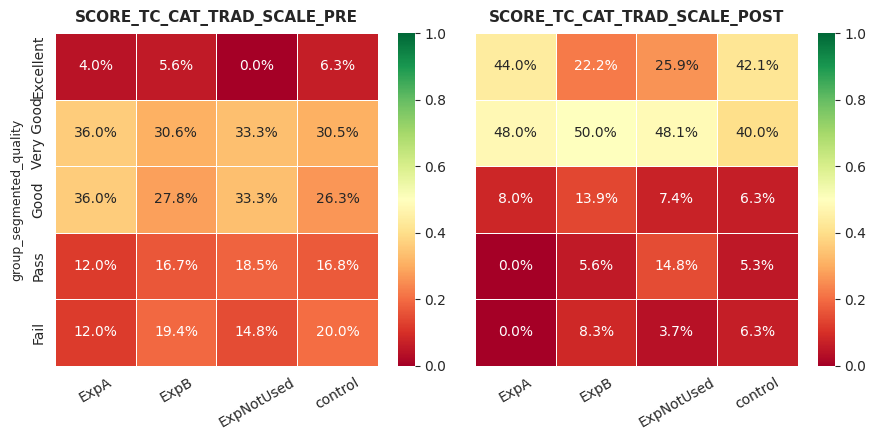

In [43]:
plot_cat_comparison_heatmap(
    df=forms_interactions_df,
    comparisons=[
        ['score_tc_cat_trad_scale_pre'], ['score_tc_cat_trad_scale_post'],
    ],
    group_by='group_segmented_quality',
    order=['Excellent', 'Very Good', 'Good', 'Pass', 'Fail'],
    title=None
)

EXPERIMENTAL:


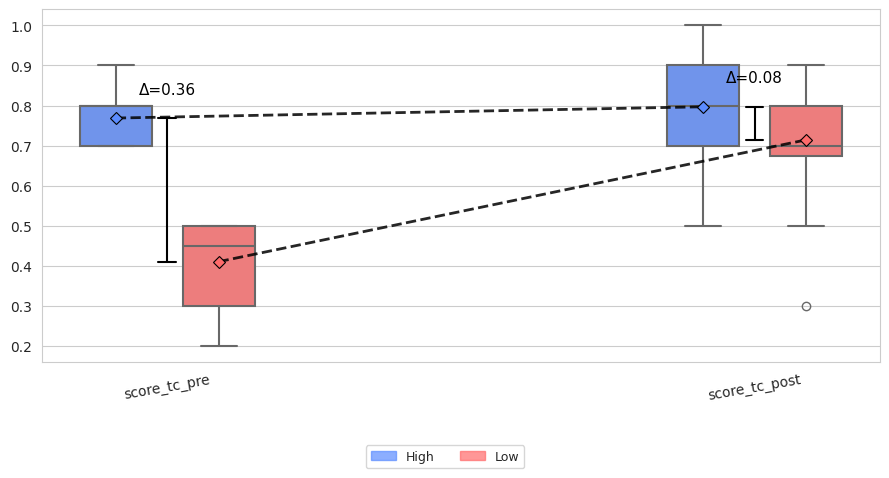

CONTROL:


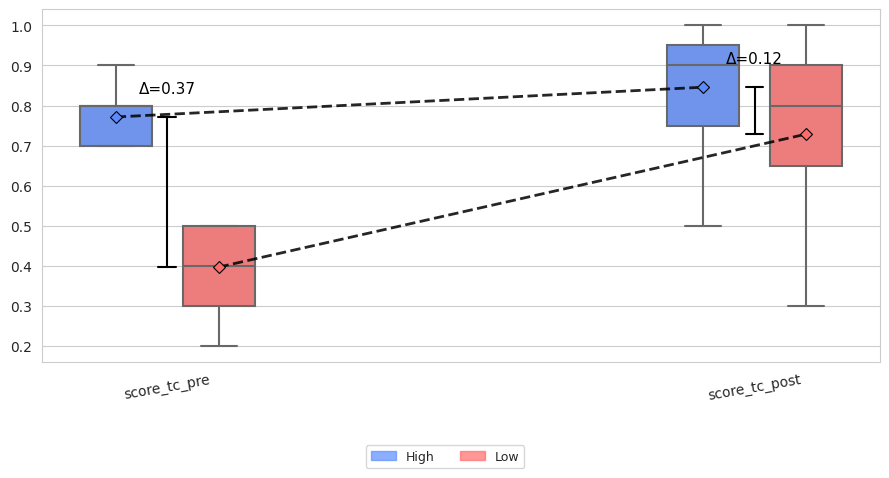

In [44]:
# Categorización adicional según el group al que pertenecen (solo para score_tc)
col = 'score_tc_pre'
df_cat_group = (
    forms_interactions_df.with_columns(
        pl.when(pl.col(col) <= 0.5).then(pl.lit("Low"))
        .when(pl.col(col) >= 0.7).then(pl.lit("High"))
        .alias(f"{col}_cat_new_group")
    )
)

df_cat_group_exp = df_cat_group.filter(
    pl.col("group") == "experimental"
)
df_cat_group_control = df_cat_group.filter(
    pl.col("group") == "control"
)

print("EXPERIMENTAL:")
plot_quant_comparison(
    figsize=(9, 4),
    df=df_cat_group_exp,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by=f"{col}_cat_new_group",
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    show_mean_lines=True,
    save_path=os.path.join(knowledge_path, 'mathew_experimental.pdf')
)

print("CONTROL:")
plot_quant_comparison(
    figsize=(9, 4),
    df=df_cat_group_control,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by=f"{col}_cat_new_group",
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    show_mean_lines=True,
    save_path=os.path.join(knowledge_path, 'mathew_control.pdf')
)

EXPNOTUSED


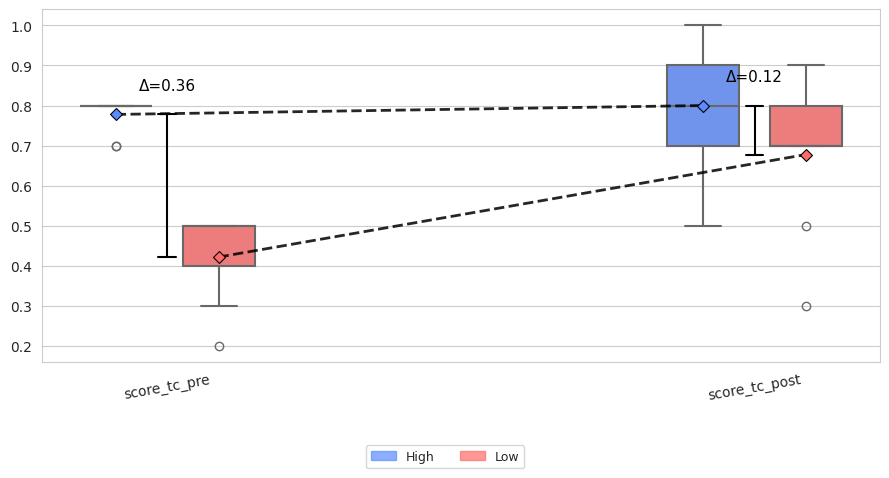

EXPA


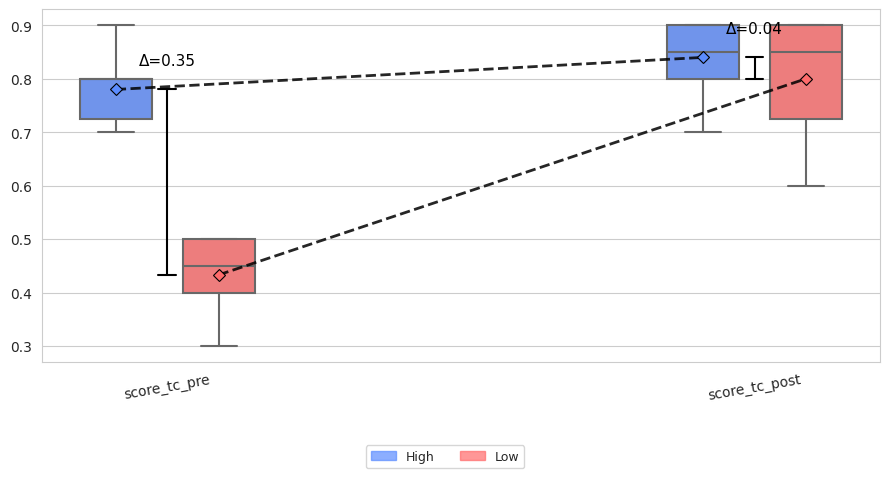

EXPB


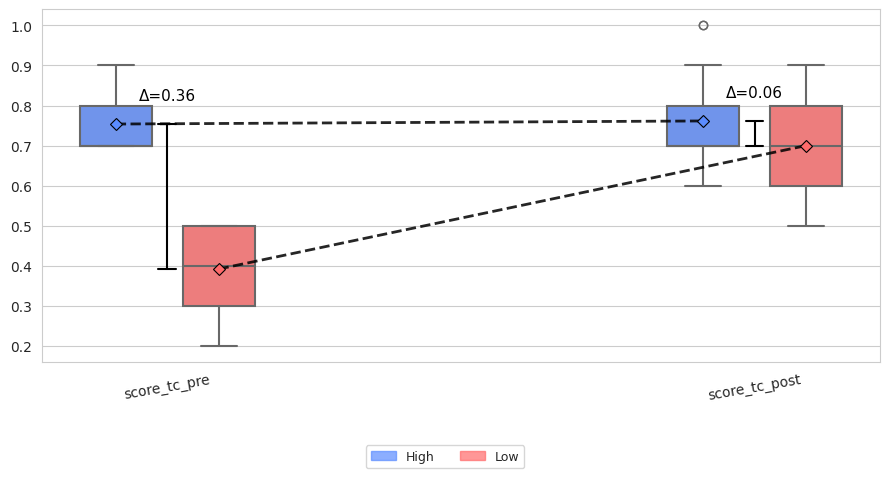

In [45]:
variable = "experimental_type_quality"

for g in df_cat_group_exp[variable].unique().to_list():
    print(g.upper())
    plot_quant_comparison(
        figsize=(9, 4),
        df=df_cat_group_exp.filter(
            pl.col(variable)==g
        ),
        comparisons=[
            ["score_tc_pre", "score_tc_post"]
        ],
        group_by=f"{col}_cat_new_group",
        showfliers=True,
        title=None,
        labelbottom=True,
        xlabel_rotation=10,
        bbox_to_anchor=(0.5, -0.2),
        show_mean_lines=True,
        save_path=os.path.join(knowledge_path, f'mathew_{g}.pdf')
    )

EXPAB


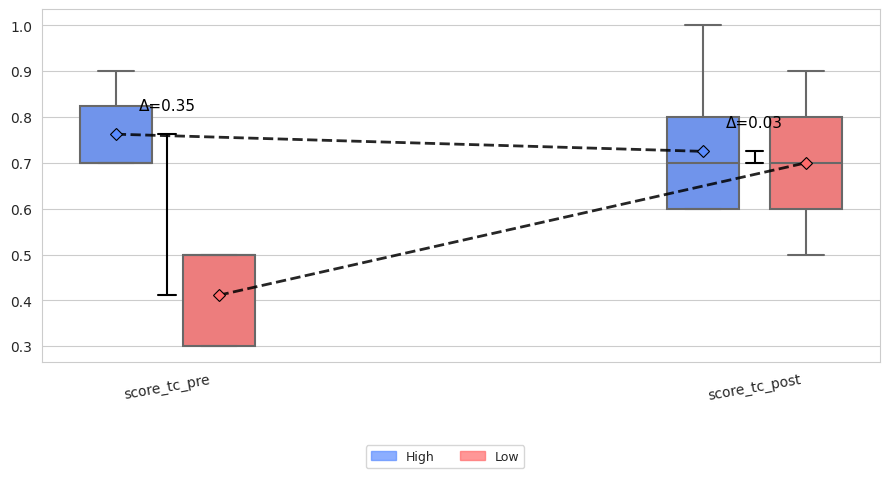

EXPNOTUSED


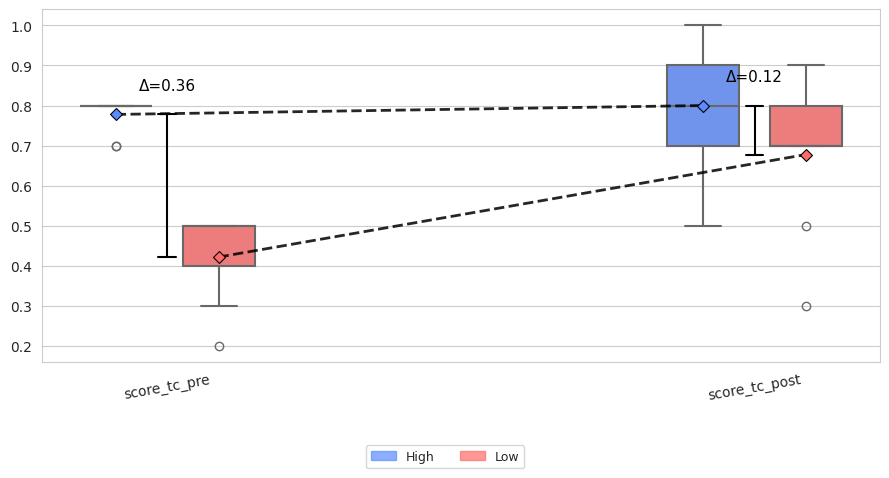

EXPBA


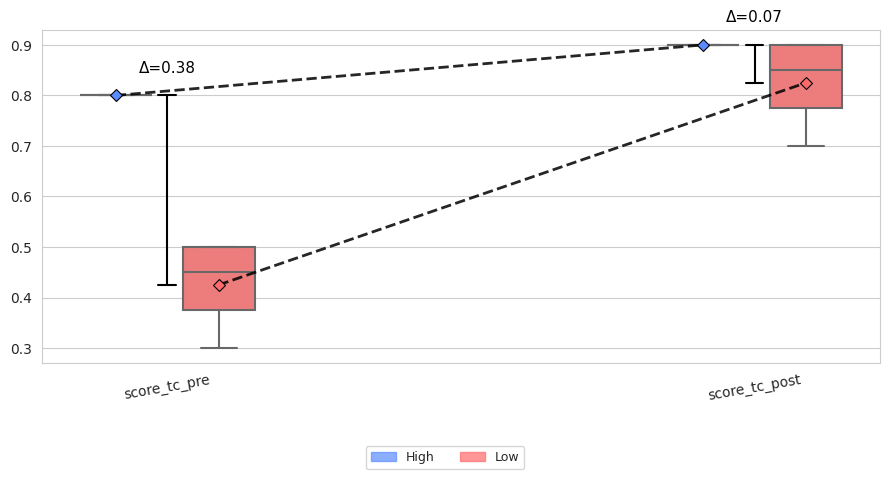

EXPAA


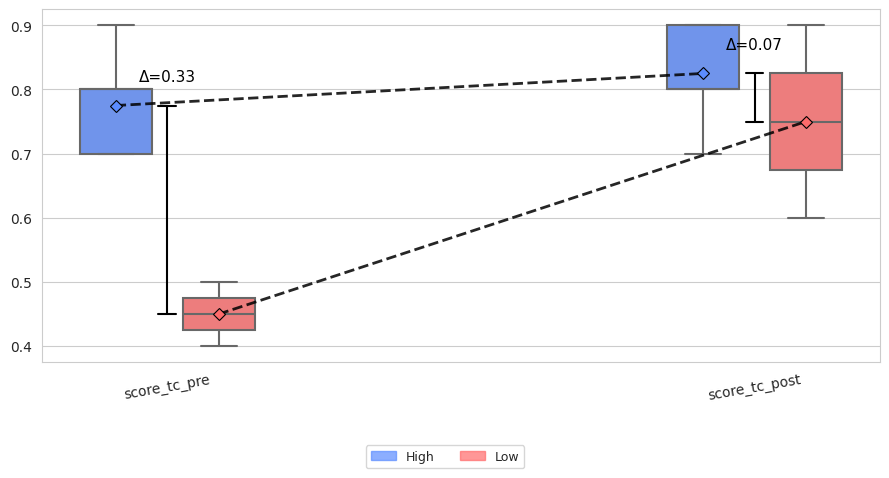

EXPBB


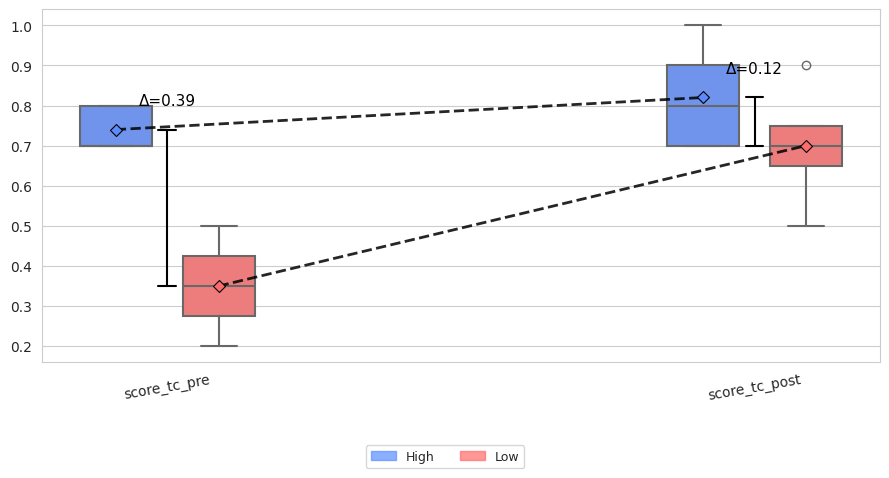

In [46]:
variable = "experimental_type_freq_quality"

for g in df_cat_group_exp[variable].unique().to_list():
    print(g.upper())
    plot_quant_comparison(
        figsize=(9, 4),
        df=df_cat_group_exp.filter(
            pl.col(variable)==g
        ),
        comparisons=[
            ["score_tc_pre", "score_tc_post"]
        ],
        group_by=f"{col}_cat_new_group",
        showfliers=True,
        title=None,
        labelbottom=True,
        xlabel_rotation=10,
        bbox_to_anchor=(0.5, -0.2),
        show_mean_lines=True,
        save_path=os.path.join(knowledge_path, f'mathew_{g}.pdf')
    )

In [47]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'

d = df.dropna(subset=[OUTCOME, COVARIATE, 'group', 'school']).copy()
d['group_binary'] = (d['group'] == 'experimental').astype(int)
pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean

# Misma categorización que la figura: cortes fijos, franja central excluida
d['prior_cat'] = np.where(d[COVARIATE] <= 0.5, 'Low',
                   np.where(d[COVARIATE] >= 0.7, 'High', None))

print("--- Cobertura de la categorización de la figura ---")
print(f"Low  (<= 0.5): {(d['prior_cat'] == 'Low').sum()}")
print(f"High (>= 0.7): {(d['prior_cat'] == 'High').sum()}")
print(f"Excluidos (0.5 < pre < 0.7): {d['prior_cat'].isna().sum()} "
      f"de {len(d)} ({d['prior_cat'].isna().mean():.1%})\n")

# ================== DESCRIPTIVOS: brechas por estrato ==================
def gap_table(data, label):
    sub = data.dropna(subset=['prior_cat'])
    if sub['prior_cat'].nunique() < 2:
        print(f"{label:<14} datos insuficientes")
        return None
    g = sub.groupby('prior_cat')[[COVARIATE, OUTCOME]].mean()
    n = sub.groupby('prior_cat').size()
    gap_pre  = g.loc['High', COVARIATE] - g.loc['Low', COVARIATE]
    gap_post = g.loc['High', OUTCOME]   - g.loc['Low', OUTCOME]
    print(f"{label:<14} n(High/Low) = {n.get('High',0):>2}/{n.get('Low',0):<2} | "
          f"High {g.loc['High',COVARIATE]:.3f}->{g.loc['High',OUTCOME]:.3f} | "
          f"Low {g.loc['Low',COVARIATE]:.3f}->{g.loc['Low',OUTCOME]:.3f} | "
          f"gap {gap_pre:.3f}->{gap_post:.3f} ({1-gap_post/gap_pre:.1%} reduction)")
    return dict(label=label, n_high=n.get('High', 0), n_low=n.get('Low', 0),
                gap_pre=gap_pre, gap_post=gap_post)

print("--- Brechas alto/bajo rendimiento previo (cortes fijos de la figura) ---")
rows = [gap_table(d[d['group'] == 'control'], 'Control'),
        gap_table(d[d['group'] == 'experimental'], 'Experimental')]
for lvl in ['ExpA', 'ExpB', 'ExpNotUsed']:
    if lvl in d['group_segmented_quality'].astype(str).unique():
        rows.append(gap_table(d[d['group_segmented_quality'].astype(str) == lvl], lvl))
for lvl in ['ExpAA', 'ExpBA', 'ExpAB', 'ExpBB']:
    if lvl in d['group_segmented_freq_quality'].astype(str).unique():
        rows.append(gap_table(
            d[d['group_segmented_freq_quality'].astype(str) == lvl], lvl))

# ================== REGRESIÓN A LA MEDIA ==================
# Bajo ausencia total de efecto diferencial, la brecha se reduce por el simple
# hecho de haber seleccionado los extremos del pre. La magnitud esperada de esa
# reducción es 1 - r, con r la correlación pre-post dentro de cada condición.
print("\n--- Cierre esperado por regresión a la media ---")
for lbl, sub in [('Control', d[d['group'] == 'control']),
                 ('Experimental', d[d['group'] == 'experimental'])]:
    r = sub[COVARIATE].corr(sub[OUTCOME])
    print(f"{lbl:<14} r(pre, post) = {r:.3f} -> reducción esperada de la brecha "
          f"por regresión a la media ~ {1-r:.1%}")

# ================== MODELO: moderación por rendimiento previo ==================
# La pregunta "¿se cierra más la brecha en el grupo experimental?" es, formalmente,
# si el efecto de la condición varía con el nivel previo: el término de interacción.
print("\n--- M3: interacción condición x conocimiento previo (escala continua) ---")
m2 = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", d,
                 groups=d['school'], re_formula="1").fit(reml=True)
m3 = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", d,
                 groups=d['school'], re_formula="1").fit(reml=True)

t = 'group_binary:pre_c'
ci = m3.conf_int().loc[t]
print(f"beta3 = {m3.params[t]:+.4f} (SE {m3.bse[t]:.4f}, p {m3.pvalues[t]:.4f}, "
      f"95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}])")

m2ml = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", d, groups=d['school'],
                   re_formula="1").fit(reml=False)
m3ml = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", d, groups=d['school'],
                   re_formula="1").fit(reml=False)
lr = 2 * (m3ml.llf - m2ml.llf)
print(f"LR test M2 vs M3: chi2 = {lr:.4f}, df = 1, p = {stats.chi2.sf(lr,1):.4f}")

# Pendiente pre->post dentro de cada condición: si el experimental "compensa",
# su pendiente debería ser MENOR (menos dependencia del punto de partida).
print("\n--- Pendiente del pre dentro de cada condición ---")
for lbl, sub in [('Control', d[d['group'] == 'control']),
                 ('Experimental', d[d['group'] == 'experimental'])]:
    m = smf.mixedlm(f"{OUTCOME} ~ pre_c", sub, groups=sub['school'],
                    re_formula="1").fit(reml=True)
    ci_s = m.conf_int().loc['pre_c']
    print(f"{lbl:<14} beta_pre = {m.params['pre_c']:+.4f} "
          f"(SE {m.bse['pre_c']:.4f}, p {m.pvalues['pre_c']:.4f}, "
          f"95% CI [{ci_s[0]:+.4f}, {ci_s[1]:+.4f}])")

# Misma interacción dentro del grupo experimental, por perfil de uso
print("\n--- Interacción perfil x conocimiento previo (solo experimental) ---")
de = d[d['group'] == 'experimental'].copy()
de['prof'] = de['group_segmented_quality'].astype(str)
try:
    mi = smf.mixedlm(f"{OUTCOME} ~ C(prof, Treatment(reference='ExpA')) * pre_c",
                     de, groups=de['school'], re_formula="1").fit(reml=True)
    for name in mi.params.index:
        if ':pre_c' in name and name.startswith('C('):
            lvl = name.split('[T.')[-1].split(']')[0]
            ci_i = mi.conf_int().loc[name]
            print(f"{lvl:<12} beta = {mi.params[name]:+.4f} "
                  f"(p {mi.pvalues[name]:.4f}, 95% CI [{ci_i[0]:+.4f}, {ci_i[1]:+.4f}])")
except Exception as exc:
    print(f"no estimable: {type(exc).__name__}: {exc}")

--- Cobertura de la categorización de la figura ---
Low  (<= 0.5): 63
High (>= 0.7): 67
Excluidos (0.5 < pre < 0.7): 53 de 183 (29.0%)

--- Brechas alto/bajo rendimiento previo (cortes fijos de la figura) ---
Control        n(High/Low) = 35/35 | High 0.771->0.846 | Low 0.397->0.729 | gap 0.374->0.117 (68.7% reduction)
Experimental   n(High/Low) = 32/28 | High 0.769->0.797 | Low 0.411->0.714 | gap 0.358->0.083 (76.9% reduction)
ExpA           n(High/Low) = 10/6  | High 0.780->0.840 | Low 0.433->0.800 | gap 0.347->0.040 (88.5% reduction)
ExpB           n(High/Low) = 13/13 | High 0.754->0.762 | Low 0.392->0.700 | gap 0.362->0.062 (83.0% reduction)
ExpNotUsed     n(High/Low) =  9/9  | High 0.778->0.800 | Low 0.422->0.678 | gap 0.356->0.122 (65.6% reduction)
ExpAA          n(High/Low) =  8/2  | High 0.775->0.825 | Low 0.450->0.750 | gap 0.325->0.075 (76.9% reduction)
ExpBA          n(High/Low) =  2/4  | High 0.800->0.900 | Low 0.425->0.825 | gap 0.375->0.075 (80.0% reduction)
ExpAB         

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

beta3 = -0.0976 (SE 0.1358, p 0.4725, 95% CI [-0.3638, +0.1687])
LR test M2 vs M3: chi2 = 0.5284, df = 1, p = 0.4673

--- Pendiente del pre dentro de cada condición ---
Control        beta_pre = +0.2444 (SE 0.0918, p 0.0078, 95% CI [+0.0645, +0.4243])
Experimental   beta_pre = +0.1951 (SE 0.1078, p 0.0703, 95% CI [-0.0162, +0.4064])

--- Interacción perfil x conocimiento previo (solo experimental) ---
ExpB         beta = +0.1367 (p 0.6088, 95% CI [-0.3867, +0.6600])
ExpNotUsed   beta = +0.3278 (p 0.2517, 95% CI [-0.2327, +0.8884])


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

#### Hake Gain

In [48]:
no_efecto_techo_df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)).filter(
    pl.col("score_tc_pre") < 0.8	
)

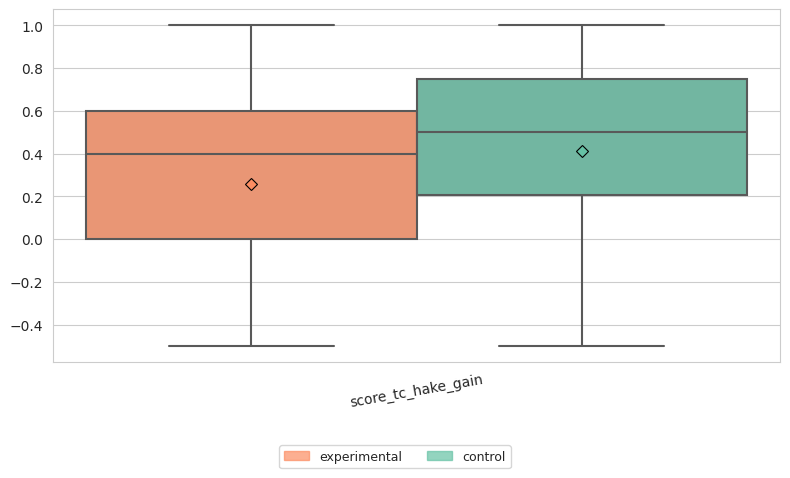

In [49]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
         ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    order=['experimental', 'control'],
    figsize=(8,4),
    save_path=os.path.join(knowledge_path, 'hake_gain_comparison.pdf')
)

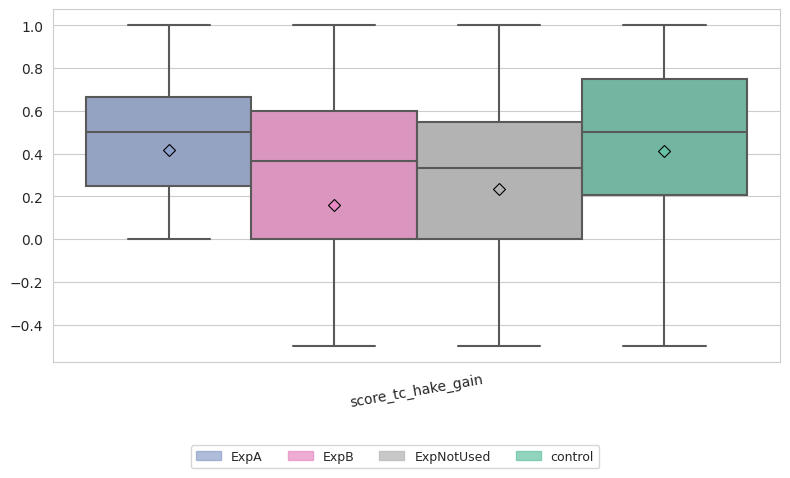

In [50]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    figsize=(8,4),
    save_path=os.path.join(knowledge_path, 'hake_gain_quality.pdf')
)

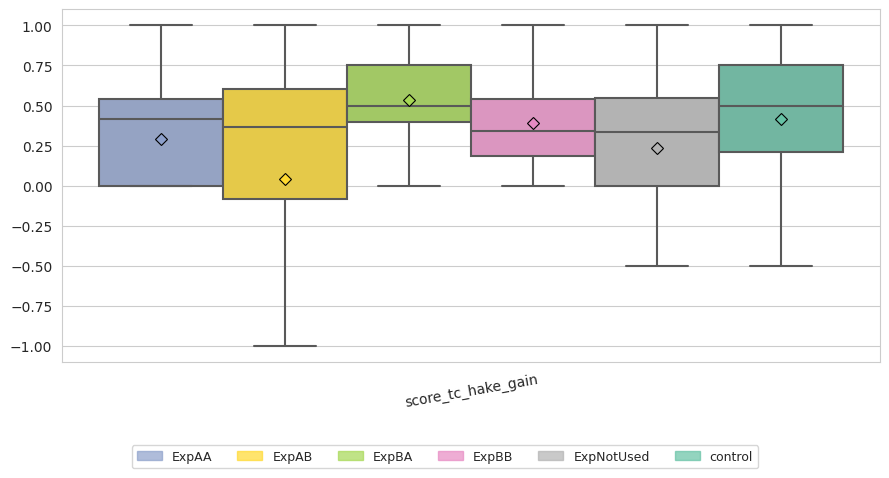

In [51]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_freq_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    save_path=os.path.join(knowledge_path, 'hake_gain_frq_quality.pdf')
)

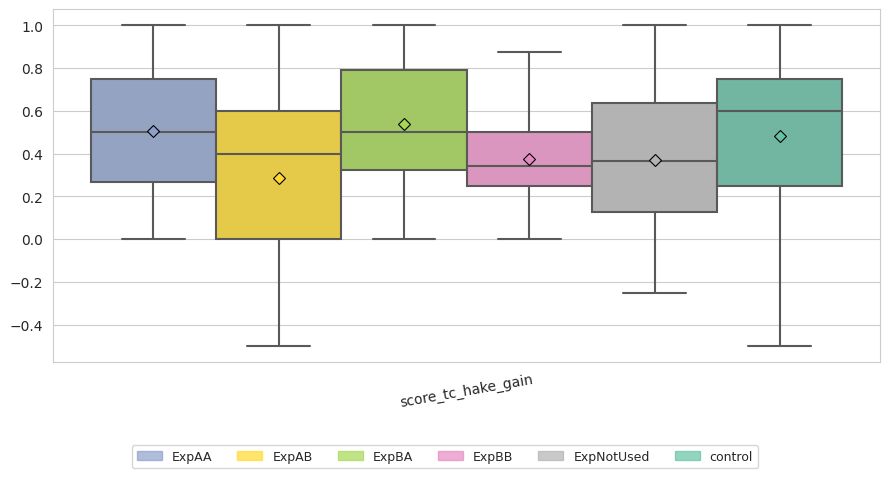

In [52]:
plot_quant_comparison(
    figsize = (9,4),
    df = no_efecto_techo_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_freq_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    save_path=os.path.join(knowledge_path, 'hake_gain_frq_quality_no_ceiling_effect.pdf')
)

#### Correlation plots

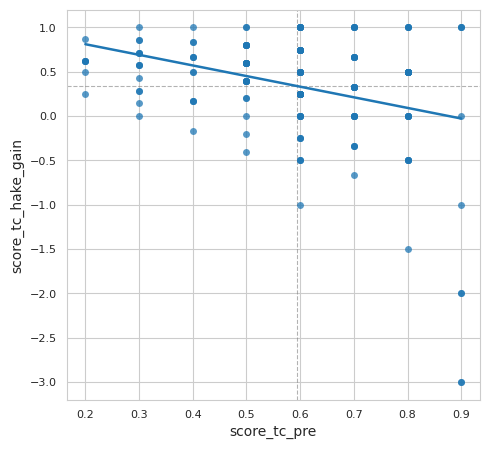

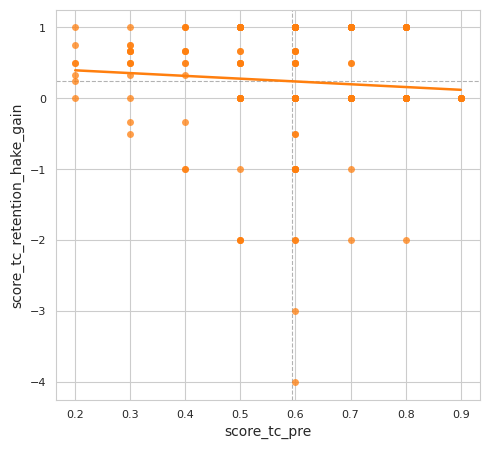

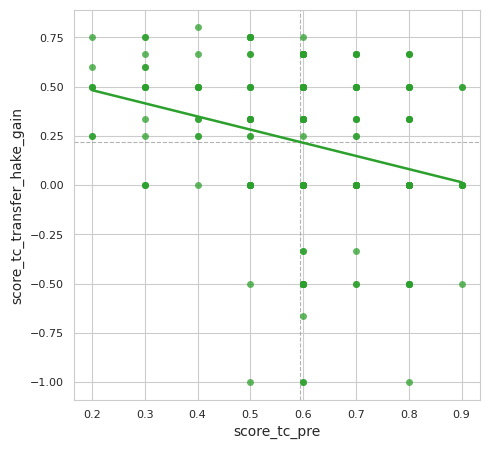

In [53]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_transfer.pdf')
)

In [54]:
cols_2 = [
    "score_tc_hake_gain",
    "score_tc_retention_hake_gain",
    "score_tc_transfer_hake_gain"
]

for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_tc_pre",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(-0.3303549661488646), 'pearson_p': np.float64(4.94228432965472e-06)}, 'spearman': {'spearman_r': np.float64(-0.23970104513400112), 'spearman_p': np.float64(0.001082433961517392)}}
{'pearson': {'pearson_r': np.float64(-0.0828299323285747), 'pearson_p': np.float64(0.2649612576166353)}, 'spearman': {'spearman_r': np.float64(-0.12400637083543542), 'spearman_p': np.float64(0.0944269202777078)}}
{'pearson': {'pearson_r': np.float64(-0.2859764563651373), 'pearson_p': np.float64(8.695113509220445e-05)}, 'spearman': {'spearman_r': np.float64(-0.2982355668792863), 'spearman_p': np.float64(4.1222469433788804e-05)}}


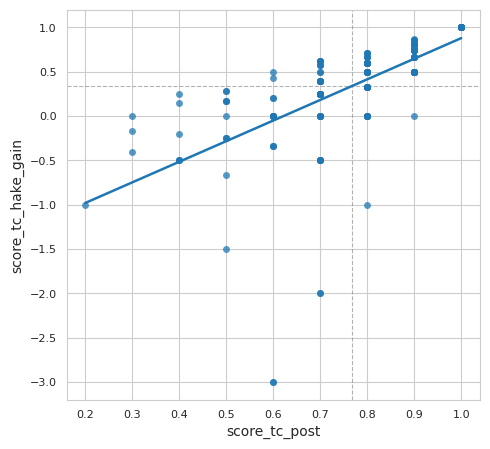

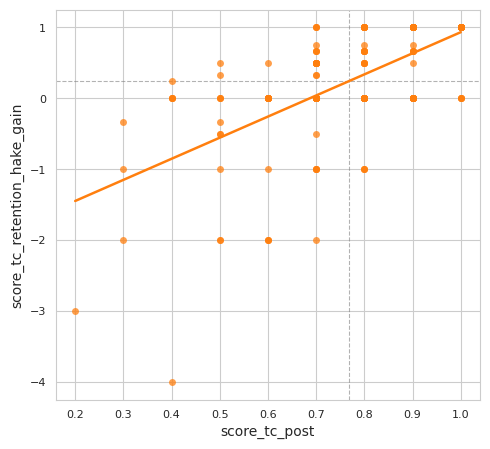

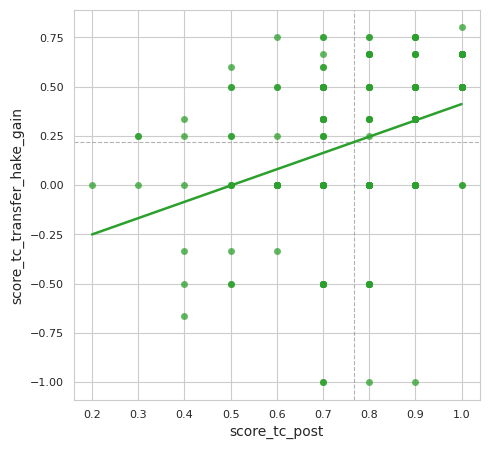

In [55]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_hake_gain"), 
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_transfer.pdf')
)

In [56]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_tc_post",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.6320305667479138), 'pearson_p': np.float64(8.436020257319716e-22)}, 'spearman': {'spearman_r': np.float64(0.8383864054743115), 'spearman_p': np.float64(1.4022925270836607e-49)}}
{'pearson': {'pearson_r': np.float64(0.618584411328048), 'pearson_p': np.float64(1.048724120601157e-20)}, 'spearman': {'spearman_r': np.float64(0.6310623205350168), 'spearman_p': np.float64(1.015653988539298e-21)}}
{'pearson': {'pearson_r': np.float64(0.34913251103443593), 'pearson_p': np.float64(1.2730487103658886e-06)}, 'spearman': {'spearman_r': np.float64(0.41220153870660214), 'spearman_p': np.float64(6.718948596500451e-09)}}


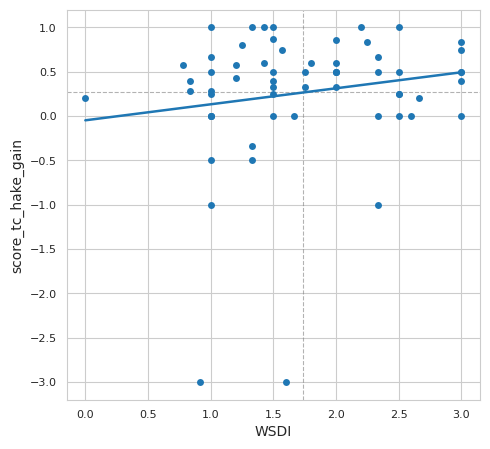

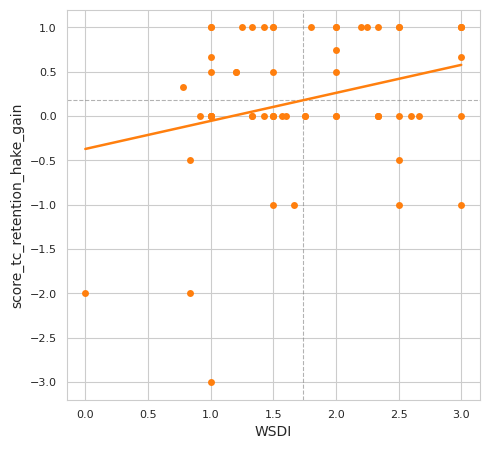

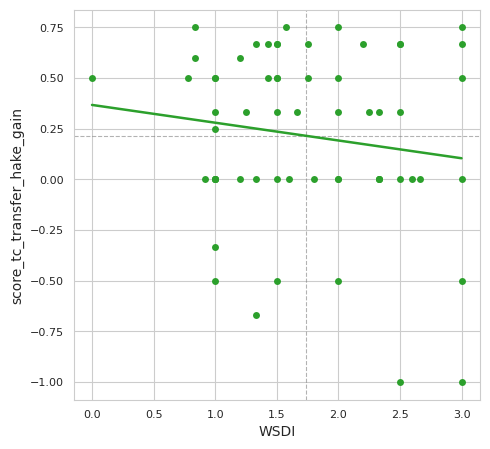

In [57]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_transfer.pdf')
)

In [58]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "WSDI",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.17076180264597193), 'pearson_p': np.float64(0.1882448377650559)}, 'spearman': {'spearman_r': np.float64(0.1419290349279892), 'spearman_p': np.float64(0.2752273614240606)}}
{'pearson': {'pearson_r': np.float64(0.2726747702999409), 'pearson_p': np.float64(0.03349756279237063)}, 'spearman': {'spearman_r': np.float64(0.1829850520048646), 'spearman_p': np.float64(0.15808473703519776)}}
{'pearson': {'pearson_r': np.float64(-0.14389869333487126), 'pearson_p': np.float64(0.268551618375761)}, 'spearman': {'spearman_r': np.float64(-0.06528380666380786), 'spearman_p': np.float64(0.6171678474816557)}}


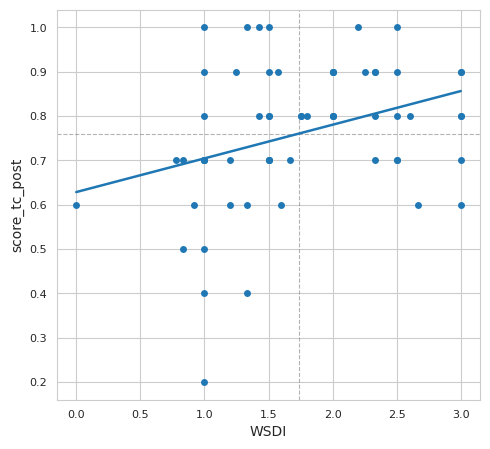

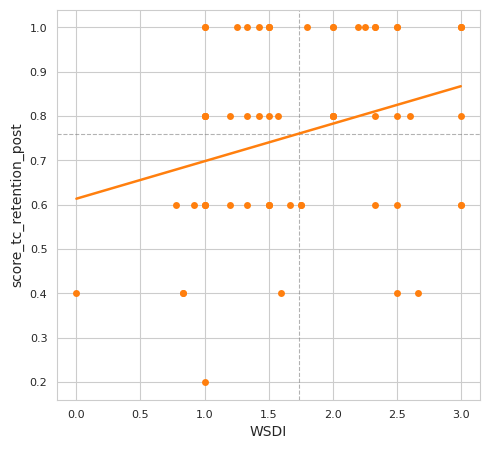

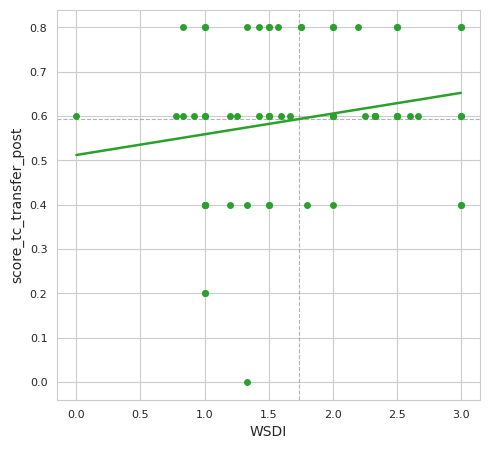

In [59]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_post")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_tc_post.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_retention_post")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_tc_retention_post.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_transfer_post")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_tc_transfer_post.pdf')
)

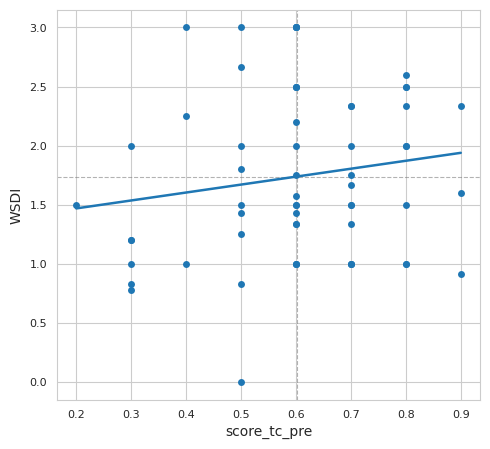

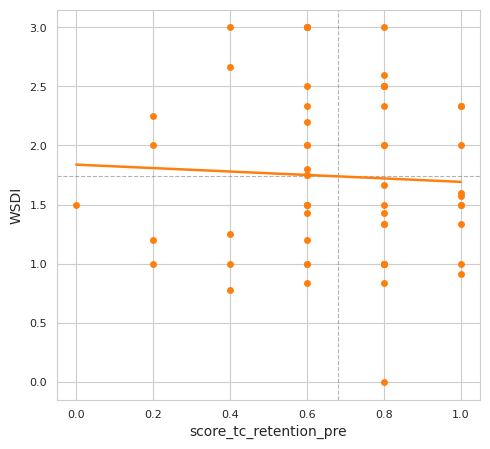

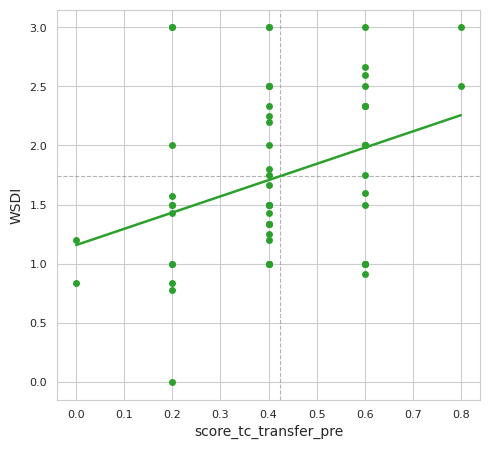

In [60]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_retention_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_transfer_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_transfer.pdf')
)

In [61]:
cols_1 = [
    "score_tc_pre",
    "score_tc_retention_pre",
    "score_tc_transfer_pre"
]

for col in cols_1:
    results = compute_correlations(
        forms_interactions_df,
        col1 = col,
        col2 = "WSDI",
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.15747280276523373), 'pearson_p': np.float64(0.22549817544982453)}, 'spearman': {'spearman_r': np.float64(0.15141953889330345), 'spearman_p': np.float64(0.24406359935805919)}}
{'pearson': {'pearson_r': np.float64(-0.04783642776665884), 'pearson_p': np.float64(0.7142942830378234)}, 'spearman': {'spearman_r': np.float64(-0.05871664901124009), 'spearman_p': np.float64(0.6530763636824426)}}
{'pearson': {'pearson_r': np.float64(0.3406172649132083), 'pearson_p': np.float64(0.0072289801744809595)}, 'spearman': {'spearman_r': np.float64(0.32227234132433946), 'spearman_p': np.float64(0.011311383289604382)}}


In [62]:
# plot_cat_comparison_faceted(
#     forms_interactions_df,
#     comparisons=[
#         ["WSDI_cat_v2"],
#     ],
#     outer_group_by= "WSDI_cat_v2",
#     outer_order=['Deep', 'Superficial', 'Cheating', 'Out of context', 'Not Used'],
#     order=["Low", "Medium", "High"],
#     group_by="score_tc_cat_pre",   #          
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     #save_path=os.path.join(knowledge_path, 'improvement_nota_pre.pdf')
# )

In [63]:
# ---- Preparación: solo usuarios del chat consultivo ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

d = df[df['group'] == 'experimental'].copy()
d = d.dropna(subset=['WSDI', 'school']).copy()

print("=" * 62)
print(f"Muestra con WSDI definido: n = {len(d)} | schools = {d['school'].nunique()}")
print(f"Distribución por centro: {d['school'].value_counts().to_dict()}")
print("=" * 62)

# ================== DESCRIPTIVOS DEL WSDI ==================
print("\n--- Distribución del WSDI ---")
print(d['WSDI'].describe().round(3))
print(f"\nvalores únicos: {d['WSDI'].nunique()}")
if 'WSDI_cat' in d.columns:
    print("\nreparto por categoría ordinal:")
    print(d['WSDI_cat'].value_counts().to_frame('n')
            .assign(pct=lambda x: (x['n']/len(d)*100).round(1)))

if 'chat_interactions_counts' in d.columns:
    print("\n--- Consultas por estudiante ---")
    print(d['chat_interactions_counts'].describe().round(2))
    print(f"total de consultas = {d['chat_interactions_counts'].sum():.0f}")

# Reparto retención/transferencia POR ESTUDIANTE, no por consulta
if {'count_retention', 'count_transfer'}.issubset(d.columns):
    tot = d['count_retention'] + d['count_transfer']
    d['pct_retention'] = np.where(tot > 0, d['count_retention'] / tot, np.nan)
    print("\n--- Orientación de las consultas ---")
    print(f"consultas de retención: {d['count_retention'].sum():.0f} | "
          f"de transferencia: {d['count_transfer'].sum():.0f}")
    print(f"estudiantes con al menos una consulta de transferencia: "
          f"{(d['count_transfer'] > 0).sum()} de {(tot > 0).sum()}")
    print(f"proporción de consultas de retención por estudiante: "
          f"media {d['pct_retention'].mean():.3f}, "
          f"mediana {d['pct_retention'].median():.3f}")


# ================== FUNCIONES ==================
def fit_wsdi(data, outcome, covariate=None, extra=None, label=""):
    """
    WSDI como predictor continuo, centrado, con intercepto aleatorio por centro.
    outcome ~ WSDI_c [+ covariate_c] [+ extra] + (1 | school)
    """
    sub = data.dropna(subset=[outcome, 'WSDI', 'school']
                      + ([covariate] if covariate else [])
                      + ([extra] if extra else [])).copy()
    sub['WSDI_c'] = sub['WSDI'] - sub['WSDI'].mean()
    rhs = "WSDI_c"
    if covariate:
        sub['cov_c'] = sub[covariate] - sub[covariate].mean()
        rhs += " + cov_c"
    if extra:
        sub['extra_c'] = sub[extra] - sub[extra].mean()
        rhs += " + extra_c"
    res = smf.mixedlm(f"{outcome} ~ {rhs}", sub,
                      groups=sub['school'], re_formula="1").fit(reml=True)
    ci = res.conf_int()
    print(f"\n--- {label} (n = {len(sub)}) ---")
    print(f"  formula: {outcome} ~ {rhs} + (1 | school)")
    for term in [t for t in ['WSDI_c', 'cov_c', 'extra_c'] if t in res.params.index]:
        name = {'WSDI_c': 'WSDI', 'cov_c': covariate, 'extra_c': extra}[term]
        print(f"  {name:<28} beta = {res.params[term]:+.4f} "
              f"(SE {res.bse[term]:.4f}, p {res.pvalues[term]:.4f}, "
              f"95% CI [{ci.loc[term,0]:+.4f}, {ci.loc[term,1]:+.4f}])")
    vs, vr = float(res.cov_re.iloc[0, 0]), float(res.scale)
    print(f"  ICC = {vs/(vs+vr):.4f} | converged = {res.converged}")
    return res

def icc_of(res):
    vs, vr = float(res.cov_re.iloc[0, 0]), float(res.scale)
    return vs / (vs + vr)

# ================== FIGURA 5: WSDI -> RESULTADO ==================
# Se modela el POST ajustado por el PRE, en lugar de la ganancia de Hake,
# por coherencia con el resto del paper y para evitar la cola no acotada.
print("\n" + "=" * 62)
print("FIGURA 5: ¿predice la calidad de interacción el resultado final?")
print("=" * 62)

for out, cov, lbl in [
    ('score_tc_post', 'score_tc_pre', 'Overall knowledge'),
    ('score_tc_retention_post', 'score_tc_retention_pre', 'Retention'),
    ('score_tc_transfer_post', 'score_tc_transfer_pre', 'Transfer'),
]:
    if out in d.columns and cov in d.columns:
        fit_wsdi(d, out, covariate=cov, label=lbl)

# Comparación con la especificación anterior (ganancia de Hake), para poder
# documentar la discrepancia si la hay
print("\n--- Comparación con la especificación previa (Hake gain) ---")
for out, lbl in [('score_tc_retention_hake_gain', 'Retention (Hake)'),
                 ('score_tc_transfer_hake_gain', 'Transfer (Hake)')]:
    if out in d.columns:
        sub = d.dropna(subset=[out, 'WSDI'])
        r, p = stats.pearsonr(sub['WSDI'], sub[out])
        print(f"  {lbl:<20} r = {r:+.3f}, p = {p:.4f}, n = {len(sub)} | "
              f"rango del outcome: [{sub[out].min():.2f}, {sub[out].max():.2f}]")
        fit_wsdi(d, out, label=f"{lbl} (LMM)")


# ================== FIGURA 6: CONOCIMIENTO PREVIO -> WSDI ==================
print("\n" + "=" * 62)
print("FIGURA 6: ¿predice el conocimiento previo la calidad de interacción?")
print("=" * 62)

for pre, lbl in [('score_tc_pre', 'Overall prior knowledge'),
                 ('score_tc_retention_pre', 'Prior retention'),
                 ('score_tc_transfer_pre', 'Prior transfer')]:
    if pre in d.columns:
        sub = d.dropna(subset=[pre, 'WSDI', 'school']).copy()
        sub['pre_c'] = sub[pre] - sub[pre].mean()
        res = smf.mixedlm("WSDI ~ pre_c", sub, groups=sub['school'],
                          re_formula="1").fit(reml=True)
        ci = res.conf_int().loc['pre_c']
        r, p = stats.pearsonr(sub[pre], sub['WSDI'])
        print(f"\n--- {lbl} (n = {len(sub)}) ---")
        print(f"  formula: WSDI ~ {pre} + (1 | school)")
        print(f"  ICC = {icc_of(res):.4f} | converged = {res.converged}")
        print(f"  beta = {res.params['pre_c']:+.4f} (SE {res.bse['pre_c']:.4f}, "
              f"p {res.pvalues['pre_c']:.4f}, 95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}])")
        print(f"  correlación simple: r = {r:+.3f}, p = {p:.4f}")

# Ambos subtipos en el mismo modelo: ¿aporta transferencia por encima de retención?
if {'score_tc_retention_pre', 'score_tc_transfer_pre'}.issubset(d.columns):
    sub = d.dropna(subset=['score_tc_retention_pre', 'score_tc_transfer_pre',
                           'WSDI', 'school']).copy()
    sub['ret_c'] = sub['score_tc_retention_pre'] - sub['score_tc_retention_pre'].mean()
    sub['tra_c'] = sub['score_tc_transfer_pre'] - sub['score_tc_transfer_pre'].mean()
    res = smf.mixedlm("WSDI ~ ret_c + tra_c", sub, groups=sub['school'],
                      re_formula="1").fit(reml=True)
    ci = res.conf_int()
    print(f"\n--- Ambos subtipos conjuntamente (n = {len(sub)}) ---")
    print("  formula: WSDI ~ score_tc_retention_pre + score_tc_transfer_pre + (1 | school)")
    for term, name in [('ret_c', 'prior retention'), ('tra_c', 'prior transfer')]:
        print(f"  {name:<18} beta = {res.params[term]:+.4f} "
              f"(p {res.pvalues[term]:.4f}, "
              f"95% CI [{ci.loc[term,0]:+.4f}, {ci.loc[term,1]:+.4f}])")
    print(f"  ICC = {icc_of(res):.4f} | converged = {res.converged}")
    print(f"  correlación entre ambos predictores: "
          f"r = {sub['score_tc_retention_pre'].corr(sub['score_tc_transfer_pre']):+.3f}")


# ================== FRECUENCIA Y SU INTERACCIÓN CON LA CALIDAD ==================
print("\n" + "=" * 62)
print("Frecuencia de uso, y calidad x frecuencia")
print("=" * 62)

for freq in ['chat_interactions_counts', 'tool_usage_score']:
    if freq in d.columns and 'score_tc_post' in d.columns:
        fit_wsdi(d, 'score_tc_post', covariate='score_tc_pre', extra=freq,
                 label=f"Post knowledge ~ WSDI + {freq}")

# Interacción calidad x frecuencia
if {'chat_interactions_counts', 'score_tc_post', 'score_tc_pre'}.issubset(d.columns):
    sub = d.dropna(subset=['chat_interactions_counts', 'score_tc_post',
                           'score_tc_pre', 'school']).copy()
    for col, new in [('WSDI', 'WSDI_c'), ('chat_interactions_counts', 'freq_c'),
                     ('score_tc_pre', 'pre_c')]:
        sub[new] = sub[col] - sub[col].mean()
    res = smf.mixedlm("score_tc_post ~ WSDI_c * freq_c + pre_c", sub,
                      groups=sub['school'], re_formula="1").fit(reml=True)
    ci = res.conf_int()
    print(f"\n--- Quality x frequency (n = {len(sub)}) ---")
    print("  formula: score_tc_post ~ WSDI * chat_interactions_counts "
          "+ score_tc_pre + (1 | school)")
    print(f"  ICC = {icc_of(res):.4f} | converged = {res.converged}")
    for term in ['WSDI_c', 'freq_c', 'WSDI_c:freq_c', 'pre_c']:
        if term in res.params.index:
            print(f"  {term:<16} beta = {res.params[term]:+.4f} "
                  f"(p {res.pvalues[term]:.4f}, "
                  f"95% CI [{ci.loc[term,0]:+.4f}, {ci.loc[term,1]:+.4f}])")

Muestra con WSDI definido: n = 61 | schools = 4
Distribución por centro: {'JesusMaria': 20, 'JoseGarciaNieto': 14, 'Laguna': 14, 'RamiroMaeztu': 13}

--- Distribución del WSDI ---
count    61.000
mean      1.739
std       0.707
min       0.000
25%       1.200
50%       1.571
75%       2.333
max       3.000
Name: WSDI, dtype: float64

valores únicos: 23

reparto por categoría ordinal:
                 n   pct
WSDI_cat                
Superficial     22  36.1
Cheating        20  32.8
Deep            18  29.5
Out of context   1   1.6

--- Consultas por estudiante ---
count    61.00
mean      3.70
std       2.35
min       1.00
25%       2.00
50%       3.00
75%       5.00
max      12.00
Name: chat_interactions_counts, dtype: float64
total de consultas = 226

FIGURA 5: ¿predice la calidad de interacción el resultado final?

--- Overall knowledge (n = 61) ---
  formula: score_tc_post ~ WSDI_c + cov_c + (1 | school)
  WSDI                         beta = +0.0734 (SE 0.0283, p 0.0094, 95% CI [+0

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


--- Transfer (Hake) (LMM) (n = 61) ---
  formula: score_tc_transfer_hake_gain ~ WSDI_c + (1 | school)
  WSDI                         beta = -0.0877 (SE 0.0585, p 0.1336, 95% CI [-0.2024, +0.0269])
  ICC = 0.0000 | converged = True

FIGURA 6: ¿predice el conocimiento previo la calidad de interacción?

--- Overall prior knowledge (n = 61) ---
  formula: WSDI ~ score_tc_pre + (1 | school)
  ICC = 0.0198 | converged = True
  beta = +0.6905 (SE 0.5503, p 0.2096, 95% CI [-0.3881, +1.7692])
  correlación simple: r = +0.157, p = 0.2255

--- Prior retention (n = 61) ---
  formula: WSDI ~ score_tc_retention_pre + (1 | school)
  ICC = 0.0081 | converged = True
  beta = -0.1339 (SE 0.4060, p 0.7416, 95% CI [-0.9295, +0.6618])
  correlación simple: r = -0.048, p = 0.7143

--- Prior transfer (n = 61) ---
  formula: WSDI ~ score_tc_transfer_pre + (1 | school)
  ICC = 0.0000 | converged = True
  beta = +1.3729 (SE 0.5046, p 0.0065, 95% CI [+0.3840, +2.3619])
  correlación simple: r = +0.341, p = 0.00

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(


--- Ambos subtipos conjuntamente (n = 61) ---
  formula: WSDI ~ score_tc_retention_pre + score_tc_transfer_pre + (1 | school)
  prior retention    beta = -0.3665 (p 0.4812, 95% CI [-1.3866, +0.6535])
  prior transfer     beta = +1.4692 (p 0.0174, 95% CI [+0.2589, +2.6795])
  ICC = 0.0000 | converged = True
  correlación entre ambos predictores: r = +0.199

Frecuencia de uso, y calidad x frecuencia

--- Post knowledge ~ WSDI + chat_interactions_counts (n = 61) ---
  formula: score_tc_post ~ WSDI_c + cov_c + extra_c + (1 | school)
  WSDI                         beta = +0.0713 (SE 0.0296, p 0.0159, 95% CI [+0.0133, +0.1292])
  score_tc_pre                 beta = +0.0849 (SE 0.1266, p 0.5026, 95% CI [-0.1633, +0.3330])
  chat_interactions_counts     beta = -0.0024 (SE 0.0088, p 0.7872, 95% CI [-0.0195, +0.0148])
  ICC = 0.0612 | converged = True

--- Post knowledge ~ WSDI + tool_usage_score (n = 61) ---
  formula: score_tc_post ~ WSDI_c + cov_c + extra_c + (1 | school)
  WSDI             

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [64]:
df.columns

Index(['id', 'school', 'group', 'score_tc_hake_gain',
       'score_tc_retention_hake_gain', 'score_tc_transfer_hake_gain',
       'score_tc_hake_gain_cat', 'score_tc_retention_hake_gain_cat',
       'score_tc_transfer_hake_gain_cat', 'score_tc_units_hake_gain',
       ...
       'direccion', 'curso', 'lat', 'lon', 'seccion_censal', 'municipio',
       'provincia', 'mediana_renta_uc_eur', 'renta_media_hogar_eur',
       'renta_media_persona_eur'],
      dtype='str', length=110)

In [65]:
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

df['prop_learning'] = (df['count_superficial'] + df['count_deep']) / df['chat_interactions_counts']
print(df[['WSDI', 'prop_learning']].corr())

                   WSDI  prop_learning
WSDI           1.000000       0.903698
prop_learning  0.903698       1.000000


In [66]:
print(df[['WSDI', 'prop_learning']].corr(method='spearman'))

                   WSDI  prop_learning
WSDI           1.000000       0.927852
prop_learning  0.927852       1.000000


In [67]:
data_path = os.path.join(project_path, 'data', 'interactions', 'processed_data', 'semantic_depth.parquet')
interactions_df = pl.read_parquet(data_path)
interactions_df = interactions_df.filter(~ pl.col('id').is_in(problematic_ids))
interactions_df = interactions_df.to_pandas()
pd.DataFrame({
    'conteo': interactions_df['semantic_depth_level'].value_counts(),
    'proporcion': interactions_df['semantic_depth_level'].value_counts(normalize=True),
    'porcentaje (%)': interactions_df['semantic_depth_level'].value_counts(normalize=True) * 100
}).sort_index()

,conteo,proporcion,porcentaje (%)
semantic_depth_level,,,
0,28,0.123894,12.389381
1,80,0.353982,35.398230
2,65,0.287611,28.761062
3,53,0.234513,23.451327


In [68]:
print("suma de chat_interactions_counts:", df['chat_interactions_counts'].sum())
print("filas en interactions tras filtrar:", len(interactions_df))
print("con nivel asignado:", interactions_df['semantic_depth_level'].notna().sum())

suma de chat_interactions_counts: 226.0
filas en interactions tras filtrar: 226
con nivel asignado: 226


In [69]:
ids_d = set(forms_interactions_df['id'])
ids_int = set(interactions_df['id'])
print("en interacciones pero no en d:", ids_int - ids_d)
print("en d pero sin interacciones:", ids_d - ids_int)

en interacciones pero no en d: set()
en d pero sin interacciones: {'JoseGarciaNieto-wba', 'RamiroMaeztu-80a', 'RamiroMaeztu-4gj', 'JesusMaria-i04', 'RamiroMaeztu-h3l', 'Laguna-wct', 'JoseGarciaNieto-baj', 'JoseGarciaNieto-nnx', 'RamiroMaeztu-86g', 'RamiroMaeztu-5p9', 'JesusMaria-d01', 'JesusMaria-m40', 'Laguna-gum', 'RamiroMaeztu-a28', 'JesusMaria-s17', 'Laguna-fgv', 'RamiroMaeztu-5yc', 'Laguna-6vh', 'JesusMaria-hs2', 'Laguna-17x', 'JesusMaria-m9b', 'JesusMaria-fxv', 'Laguna-v6h', 'JesusMaria-1qm', 'JesusMaria-7u7', 'Laguna-uvx', 'JesusMaria-64o', 'RamiroMaeztu-sum', 'Laguna-c6j', 'Laguna-pt8', 'Laguna-k93', 'RamiroMaeztu-8pr', 'RamiroMaeztu-e6m', 'Laguna-i9p', 'RamiroMaeztu-04b', 'JesusMaria-szt', 'JesusMaria-ub4', 'JesusMaria-a6g', 'Laguna-vft', 'Laguna-bej', 'RamiroMaeztu-39p', 'JesusMaria-a65', 'JesusMaria-shf', 'Laguna-776', 'JoseGarciaNieto-dh0', 'RamiroMaeztu-u9m', 'JesusMaria-ecq', 'RamiroMaeztu-x5e', 'Laguna-yfr', 'RamiroMaeztu-st5', 'RamiroMaeztu-4ux', 'JesusMaria-o95', 'Jesu

#### Mejora

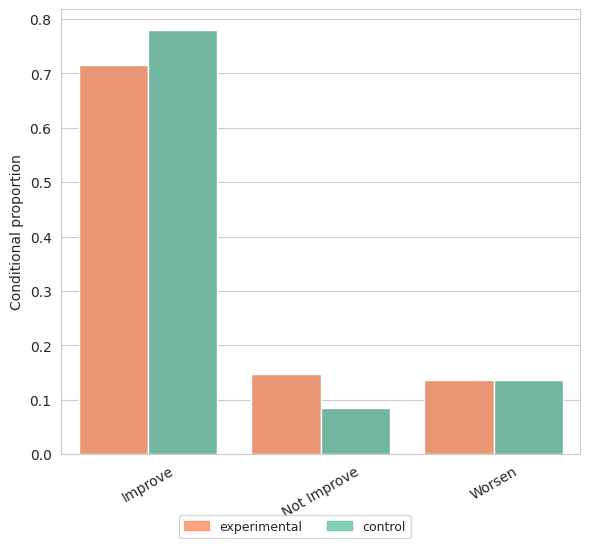

In [70]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group',
    order=['Improve', 'Not Improve', 'Worsen'],
    hue_order=['experimental', 'control'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_comparison.pdf')
)

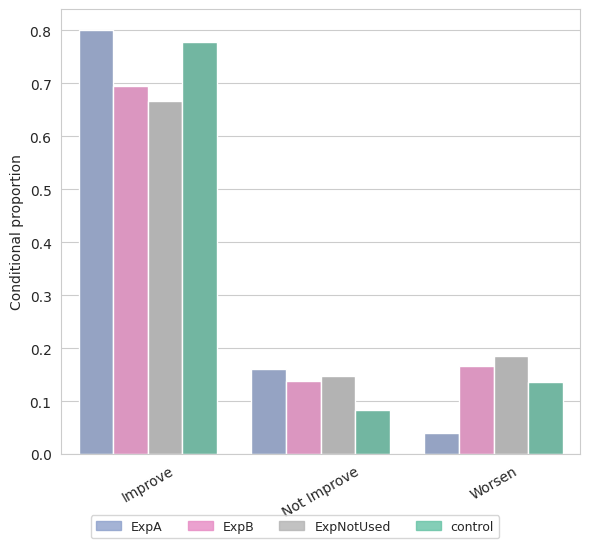

In [71]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_quality.pdf')
)


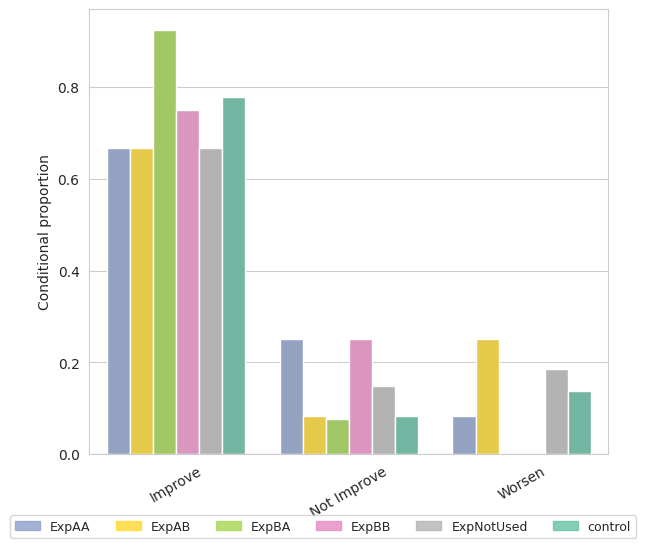

In [72]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_freq_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_frq_quality.pdf')
)

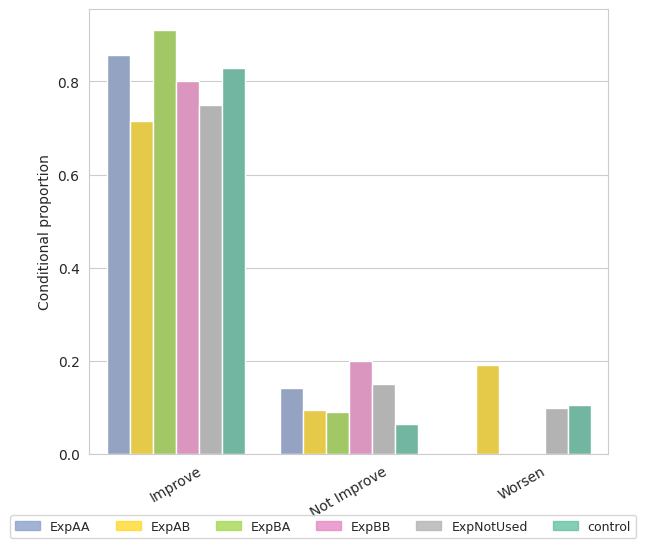

In [73]:
plot_cat_comparison(
    df=no_efecto_techo_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_freq_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_frq_quality_ceiling_effect.pdf')
)


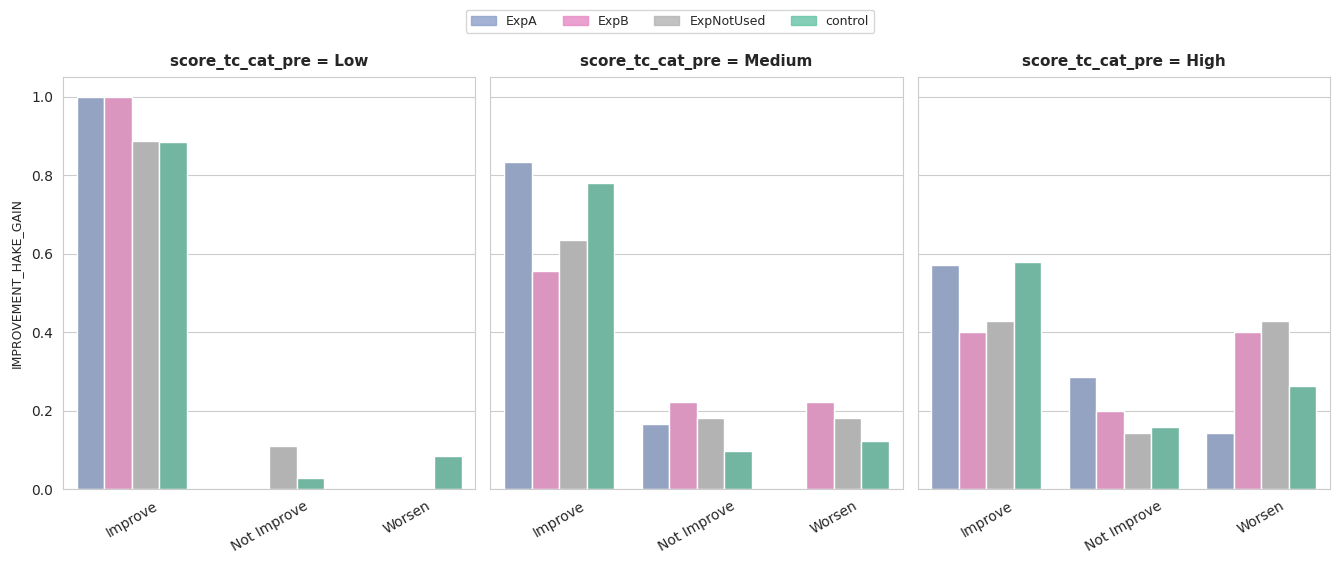

In [74]:
plot_cat_comparison_faceted(
    forms_interactions_df,
    comparisons=[
        ["improvement_hake_gain"],
    ],
    outer_group_by= "score_tc_cat_pre",
    outer_order=["Low", "Medium", "High"],
    order=['Improve', 'Not Improve', 'Worsen'],
    group_by="group_segmented_quality",            
    palette="Set2",
    bbox_to_anchor=(0.5, 1),
    sharey="all",
    save_path=os.path.join(knowledge_path, 'improvement_nota_pre.pdf')
)

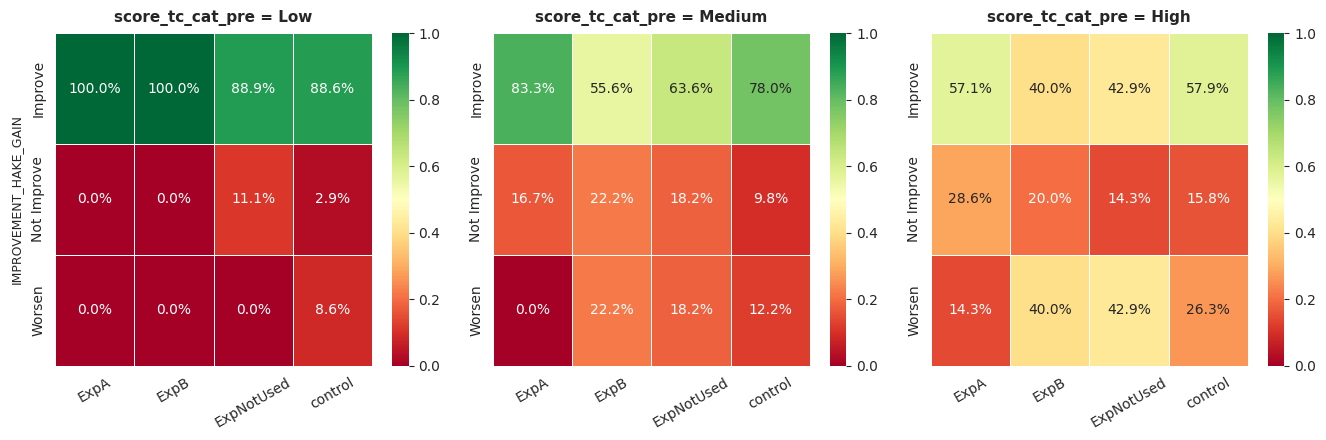

In [75]:
plot_cat_comparison_faceted_heatmap(
    forms_interactions_df,
    comparisons=[
        ["improvement_hake_gain"],
    ],
    outer_group_by="score_tc_cat_pre",
    outer_order=["Low", "Medium", "High"],
    order=['Improve', 'Not Improve', 'Worsen'],
    group_by="group_segmented_quality",
    cmap="RdYlGn",
    show_counts=True,
    save_path=os.path.join(knowledge_path, 'improvement_nota_pre_heatmap.pdf'),
)

#### Evaluation Chat

In [76]:
# plot_cat_comparison(
#     df=forms_interactions_df.filter(
#         pl.col('group') == 'experimental',
#         pl.col('evaluation_pass').is_not_null()
#     ), 
#     comparisons=[
#         ['evaluation_pass'],
#     ], 
#     title=None,
#     hue_order=["Not Used", "Out of context", "Cheating", "Superficial", "Deep"], 
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='WSDI_cat_v2',
#     subplots_title=False,
#     save_path=os.path.join(knowledge_path, 'evaluation_pass_by_depth.pdf')
# )

In [77]:
# cheating_not_cheating = forms_interactions_df.with_columns(
#     pl.when(pl.col("WSDI_cat_v2") == "Cheating")
#     .then(pl.lit("Cheating"))
#     .otherwise(pl.lit("No Cheating"))
#     .alias("do_cheat")
# ).filter(
#     pl.col("evaluation_pass").is_not_null()
# ).with_columns(
#     pl.col("evaluation_pass").cast(pl.String),
# )

# plot_cat_comparison_faceted(
#     cheating_not_cheating,
#     comparisons=[
#         ["improvement_hake_gain_v2"],
#     ],
#     outer_group_by="do_cheat",
#     group_by="evaluation_pass",        
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     order=['Improve', 'Not Improve', 'Worsen'],
#     save_path=os.path.join(knowledge_path, 'evaluation_pass_mejora.pdf')
# )

In [78]:
# ---- Preparación ----
PASS = 'evaluation_pass'
LEVEL_COL, ID_COL = 'semantic_depth_level', 'id'

data_path = os.path.join(project_path, 'data', 'interactions',
                         'processed_data', 'semantic_depth.parquet')
interactions_df = pl.read_parquet(data_path)
interactions_df = interactions_df.filter(~ pl.col('id').is_in(problematic_ids))
interactions_df = interactions_df.to_pandas()

ev = d[d['group'] == 'experimental'].copy()
print(f"experimentales: {len(ev)}")
print(f"con resultado del chat evaluativo: {ev[PASS].notna().sum()}")
print(f"sin resultado: {ev[PASS].isna().sum()}\n")

ev = ev.dropna(subset=[PASS, 'school']).copy()
ev['passed'] = ev[PASS].astype(int)
ev['used_chat'] = ev['WSDI'].notna().astype(int)

print(f"n analítico = {len(ev)} | tasa global de aprobado = {ev['passed'].mean():.3f}")
print(f"usuarios del chat consultivo: {ev['used_chat'].sum()} | "
      f"no usuarios: {(1 - ev['used_chat']).sum()}\n")

# ================== DESCRIPTIVOS ==================
print("--- Aprobado según uso del chat consultivo ---")
print(ev.groupby('used_chat')['passed'].agg(['sum', 'size', 'mean']).round(3), "\n")

u = ev[ev['used_chat'] == 1].copy()

print("--- Aprobado por banda de WSDI (solo usuarios) ---")
print(u.groupby('WSDI_cat', observed=True)['passed']
       .agg(['sum', 'size', 'mean']).round(3), "\n")

print("--- WSDI continuo: media por resultado ---")
print(u.groupby('passed')['WSDI'].agg(['mean', 'std', 'size']).round(3), "\n")

# ---- Consultas de reproducción de ítems por estudiante ----
rep = (interactions_df.assign(is_rep=lambda x: (x[LEVEL_COL] == 1).astype(int))
                      .groupby(ID_COL)
                      .agg(n_rep=('is_rep', 'sum'), n_total=('is_rep', 'size'))
                      .reset_index())
rep['prop_rep'] = rep['n_rep'] / rep['n_total']
u = u.merge(rep, on=ID_COL, how='left')

print("--- Consultas de reproducción de ítems ---")
print(f"estudiantes con al menos una: {(u['n_rep'] > 0).sum()} de {len(u)}")
print(f"proporción media: {u['prop_rep'].mean():.3f} | "
      f"mediana: {u['prop_rep'].median():.3f}")
q1, q3 = u['prop_rep'].quantile([0.25, 0.75])
print(f"cuartiles: Q1 = {q1:.3f}, Q3 = {q3:.3f} (rango IQ = {q3-q1:.3f})\n")

print("aprobado según si reprodujo algún ítem:")
print(u.assign(any_rep=(u['n_rep'] > 0).astype(int))
       .groupby('any_rep')['passed'].agg(['sum', 'size', 'mean']).round(3), "\n")

print("--- Cruce: profundidad y reproducción de ítems ---")
cross = u.assign(rep_lbl=(u['n_rep'] > 0).map({True: 'copió', False: 'no copió'}))
print("tasas de aprobado:")
print(pd.crosstab(cross['WSDI_cat'], cross['rep_lbl'],
                  values=cross['passed'], aggfunc='mean').round(3))
print("\nn por celda:")
print(pd.crosstab(cross['WSDI_cat'], cross['rep_lbl']), "\n")


# ================== MODELOS ==================
# Variables centradas y reescaladas para que los coeficientes sean interpretables:
# WSDI en puntos del índice (0-3) y reproducción de ítems en decenas de puntos
# porcentuales, en lugar de en el rango completo 0-1.
u['WSDI_c']   = u['WSDI'] - u['WSDI'].mean()
u['rep_10pp'] = (u['prop_rep'] - u['prop_rep'].mean()) * 10
u['pre_c2']   = u['score_tc_pre'] - u['score_tc_pre'].mean()
u['WSDI_sq']  = u['WSDI_c'] ** 2


def gee(data, rhs, outcome='passed', family='poisson', cov='exchangeable'):
    """Poisson modificada (RR) por defecto; binomial (OR) como comprobación."""
    fam = (sm.families.Poisson() if family == 'poisson'
           else sm.families.Binomial())
    cs = Exchangeable() if cov == 'exchangeable' else Independence()
    return GEE.from_formula(f"{outcome} ~ {rhs}", groups='school', data=data,
                            family=fam, cov_struct=cs).fit()


def report(res, label, measure='RR'):
    print(f"\n--- {label} [{measure}] ---")
    ci = res.conf_int()
    for n in res.params.index:
        if n == 'Intercept':
            continue
        print(f"  {n:<22} {measure} = {np.exp(res.params[n]):.3f} "
              f"(95% CI [{np.exp(ci.loc[n,0]):.3f}, {np.exp(ci.loc[n,1]):.3f}]) "
              f"| p = {res.pvalues[n]:.4f}")
    if measure == 'RR':
        f = res.fittedvalues
        flag = "" if (f <= 1).all() else "  [!] hay valores > 1: RR no admisible"
        print(f"  probabilidades ajustadas: [{f.min():.3f}, {f.max():.3f}]{flag}")


print("=" * 62)
print("¿Qué predice aprobar el chat evaluativo?")
print("=" * 62)

# (1) ¿Basta con haber usado el chat consultivo?
report(gee(ev, "used_chat"), "P(pass) ~ used consultative chat")

# (2) Entre usuarios: profundidad sola
report(gee(u, "WSDI_c"), "P(pass) ~ WSDI (users only)")

# (3) Reproducción de ítems sola
report(gee(u, "rep_10pp"), "P(pass) ~ item reproduction (per 10 pp)")

# (4) Ambas: aquí aparece la supresión mutua
res_main = gee(u, "WSDI_c + rep_10pp")
report(res_main, "P(pass) ~ WSDI + item reproduction (per 10 pp)")

# (5) Ajustando por conocimiento previo
report(gee(u, "WSDI_c + rep_10pp + pre_c2"),
       "P(pass) ~ WSDI + item reproduction + prior knowledge")

# (6) ¿No monotonía en la profundidad?
report(gee(u, "WSDI_c + WSDI_sq"), "P(pass) ~ WSDI + WSDI^2")

# (7) Comprobación en escala de odds
report(gee(u, "WSDI_c + rep_10pp", family='binomial'),
       "P(pass) ~ WSDI + item reproduction (logistic check)", measure='OR')


# ================== INTERPRETACIÓN EN ESCALA ORIGINAL ==================
print("\n" + "=" * 62)
print("Magnitudes interpretables")
print("=" * 62)

b_rep = res_main.params['rep_10pp']
b_wsdi = res_main.params['WSDI_c']
print(f"RR por cada 10 pp más de consultas que reproducen ítems: "
      f"{np.exp(b_rep):.3f}")
print(f"RR sobre el rango intercuartílico de reproducción "
      f"({q1:.2f} a {q3:.2f}): {np.exp(b_rep * (q3 - q1) * 10):.3f}")
print(f"RR por cada punto de WSDI: {np.exp(b_wsdi):.3f}")
print(f"RR sobre el rango intercuartílico de WSDI "
      f"({u['WSDI'].quantile(.25):.2f} a {u['WSDI'].quantile(.75):.2f}): "
      f"{np.exp(b_wsdi * (u['WSDI'].quantile(.75) - u['WSDI'].quantile(.25))):.3f}")

# Probabilidades predichas en los cuartiles, manteniendo la otra variable en su media
print("\nProbabilidad predicha de aprobar:")
for var, lbl, qs in [('WSDI_c', 'WSDI', u['WSDI'].quantile([.25, .5, .75])),
                     ('rep_10pp', 'item reproduction',
                      u['prop_rep'].quantile([.25, .5, .75]))]:
    for q, val in qs.items():
        tmp = u.copy()
        tmp['WSDI_c'] = 0
        tmp['rep_10pp'] = 0
        tmp[var] = ((val - u['WSDI'].mean()) if var == 'WSDI_c'
                    else (val - u['prop_rep'].mean()) * 10)
        print(f"  {lbl:<20} Q{int(q*100):<3} ({val:.2f}) -> "
              f"P(pass) = {res_main.predict(tmp).mean():.3f}")


# ================== ROBUSTEZ ==================
print("\n--- Robustez: independence vs exchangeable ---")
r_i = gee(u, "WSDI_c + rep_10pp", cov='independence')
for n in ['WSDI_c', 'rep_10pp']:
    ce, cin = res_main.conf_int(), r_i.conf_int()
    we = np.exp(ce.loc[n, 1]) - np.exp(ce.loc[n, 0])
    wi = np.exp(cin.loc[n, 1]) - np.exp(cin.loc[n, 0])
    print(f"  {n:<10} RR exch = {np.exp(res_main.params[n]):.3f} | "
          f"indep = {np.exp(r_i.params[n]):.3f} | "
          f"anchura ratio = {wi/we:.2f}")

# ============ COMPARACIÓN DE MAGNITUDES ENTRE PREDICTORES ============
# Los coeficientes no son comparables tal cual: están en unidades distintas
# (puntos de WSDI frente a decenas de puntos porcentuales de bypass).
# Se comparan sobre tres escalas comunes.

# Coeficientes y variables en las unidades en que entran al modelo
terms = {'WSDI':   ('WSDI_c',   u['WSDI']),
         'bypass': ('rep_10pp', u['prop_rep'] * 10)}

rows = []
for lbl, (term, x) in terms.items():
    b = res_main.params[term]
    iqr = x.quantile(0.75) - x.quantile(0.25)
    sd  = x.std(ddof=1)
    rng = x.max() - x.min()
    rows.append({
        'predictor': lbl,
        'RR per unit': np.exp(b),
        'RR over IQR': np.exp(b * iqr),
        'RR per SD':   np.exp(b * sd),
        'RR over range': np.exp(b * rng),
        'IQR': iqr, 'SD': sd, 'range': rng,
    })
print(pd.DataFrame(rows).set_index('predictor').round(3), "\n")

# ---- Probabilidades predichas: mover una variable, fijar la otra en su media ----
print("Probabilidad predicha de aprobar (la otra variable en su media):")
for lbl, (term, x) in terms.items():
    for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
        tmp = u.copy()
        tmp['WSDI_c'], tmp['rep_10pp'] = 0.0, 0.0      # ambas en su media
        tmp[term] = x.quantile(q) - x.mean()            # solo una se mueve
        orig = (u['WSDI'] if lbl == 'WSDI' else u['prop_rep']).quantile(q)
        print(f"  {lbl:<7} P{int(q*100):<3} ({orig:.2f}) -> {res_main.predict(tmp).mean():.3f}")
    print()

# ---- Cuánta variabilidad explica cada uno: coeficientes estandarizados ----
us = u.copy()
for term, x in [(t, xx) for t, xx in terms.values()]:
    us[term + '_z'] = (x - x.mean()) / x.std(ddof=1)
res_z = GEE.from_formula("passed ~ WSDI_c_z + rep_10pp_z", groups='school', data=us,
                         family=sm.families.Poisson(),
                         cov_struct=Exchangeable()).fit()
ci = res_z.conf_int()
print("Coeficientes estandarizados (RR por desviación típica):")
for t, lbl in [('WSDI_c_z', 'WSDI'), ('rep_10pp_z', 'bypass')]:
    print(f"  {lbl:<7} RR = {np.exp(res_z.params[t]):.3f} "
          f"(95% CI [{np.exp(ci.loc[t,0]):.3f}, {np.exp(ci.loc[t,1]):.3f}]) "
          f"| p = {res_z.pvalues[t]:.4f}")

# ---- Cuál contribuye más al ajuste: quitar cada uno por separado ----
print("\nAjuste con y sin cada predictor (QIC, menor es mejor):")
full = res_main
only_w = GEE.from_formula("passed ~ WSDI_c", groups='school', data=u,
                          family=sm.families.Poisson(), cov_struct=Exchangeable()).fit()
only_r = GEE.from_formula("passed ~ rep_10pp", groups='school', data=u,
                          family=sm.families.Poisson(), cov_struct=Exchangeable()).fit()
for lbl, m in [('WSDI + bypass', full), ('solo WSDI', only_w), ('solo bypass', only_r)]:
    try:
        print(f"  {lbl:<15} QIC = {m.qic()[0]:.2f}")
    except Exception:
        print(f"  {lbl:<15} QIC no disponible")

experimentales: 61
con resultado del chat evaluativo: 57
sin resultado: 4

n analítico = 57 | tasa global de aprobado = 0.509
usuarios del chat consultivo: 57 | no usuarios: 0

--- Aprobado según uso del chat consultivo ---
           sum  size   mean
used_chat                  
1           29    57  0.509 

--- Aprobado por banda de WSDI (solo usuarios) ---
                sum  size   mean
WSDI_cat                        
Cheating         11    18  0.611
Deep             10    17  0.588
Out of context    0     1  0.000
Superficial       8    21  0.381 

--- WSDI continuo: media por resultado ---
         mean    std  size
passed                    
0       1.652  0.642    28
1       1.809  0.760    29 

--- Consultas de reproducción de ítems ---
estudiantes con al menos una: 39 de 57
proporción media: 0.365 | mediana: 0.333
cuartiles: Q1 = 0.000, Q3 = 0.556 (rango IQ = 0.556)

aprobado según si reprodujo algún ítem:
         sum  size   mean
any_rep                  
0          9    1

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


### Self-efficiency

In [79]:
self_efficacy_path = os.path.join(plots_path, '5_2', '5_2_3')
os.makedirs(self_efficacy_path, exist_ok=True)

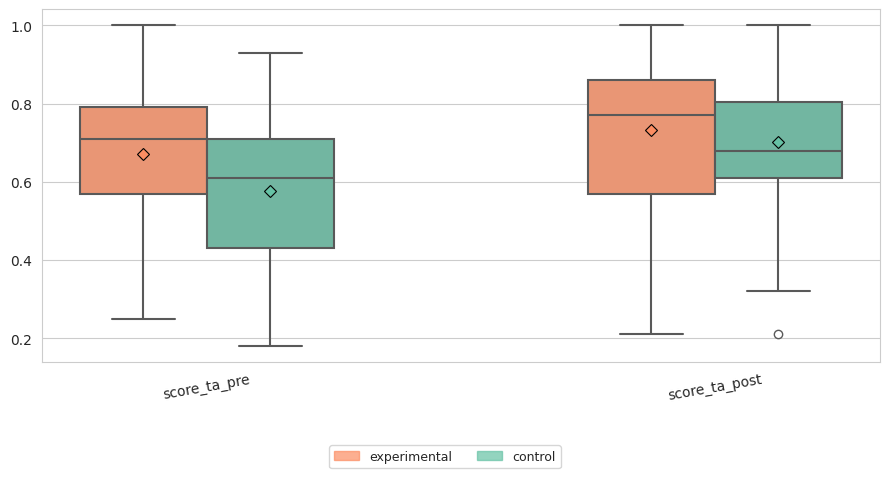

In [80]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_ta_pre', 'score_ta_post']
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(self_efficacy_path, 'self_confidence_comparison.pdf')
)

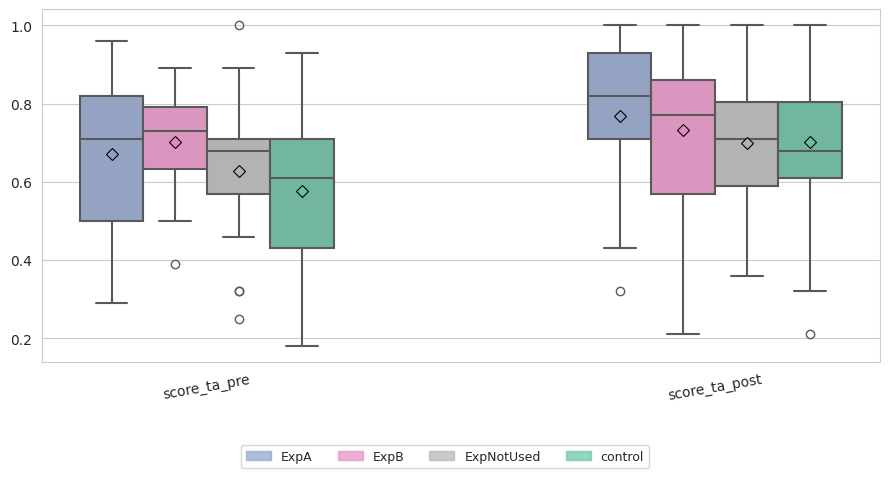

In [81]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_ta_pre', 'score_ta_post']
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(self_efficacy_path, 'self_confidence_quality.pdf')
)

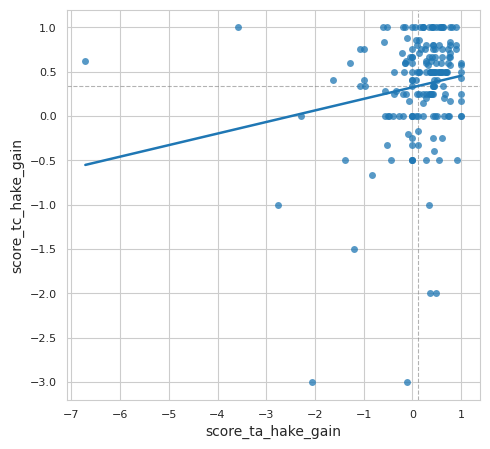

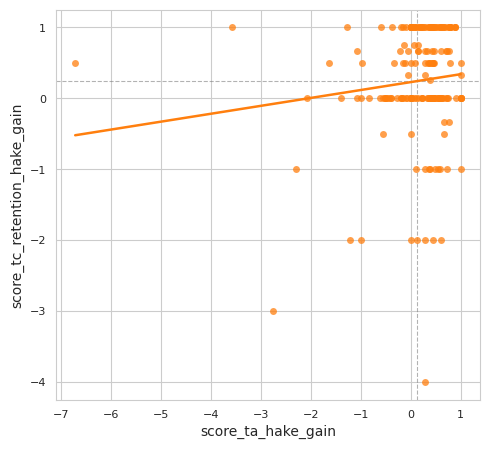

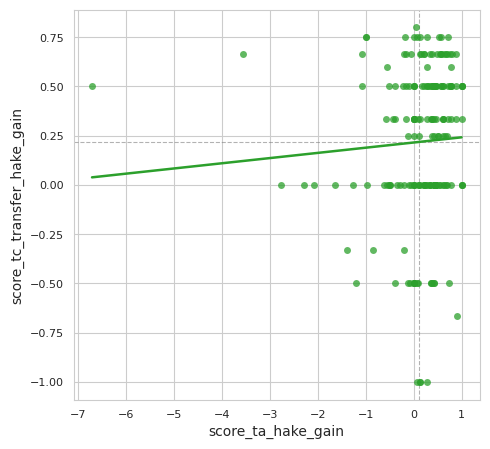

In [82]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_transfer.pdf')
)

In [83]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_ta_hake_gain",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.17343781097847621), 'pearson_p': np.float64(0.018876078902059116)}, 'spearman': {'spearman_r': np.float64(0.169282223198895), 'spearman_p': np.float64(0.021970646312647984)}}
{'pearson': {'pearson_r': np.float64(0.11352089686819852), 'pearson_p': np.float64(0.12598949837470325)}, 'spearman': {'spearman_r': np.float64(0.06798571172414279), 'spearman_p': np.float64(0.36048026757682683)}}
{'pearson': {'pearson_r': np.float64(0.054373062654112084), 'pearson_p': np.float64(0.4647509925258034)}, 'spearman': {'spearman_r': np.float64(0.1500702286235837), 'spearman_p': np.float64(0.04259093494571448)}}


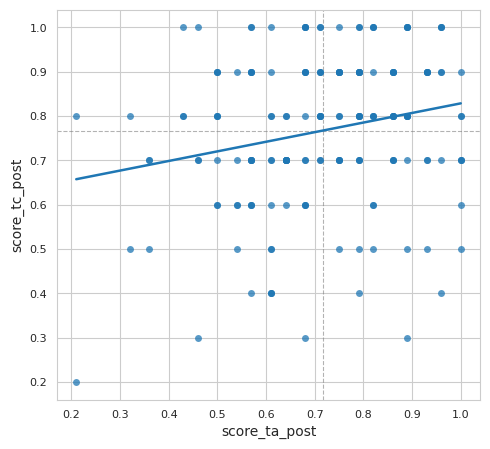

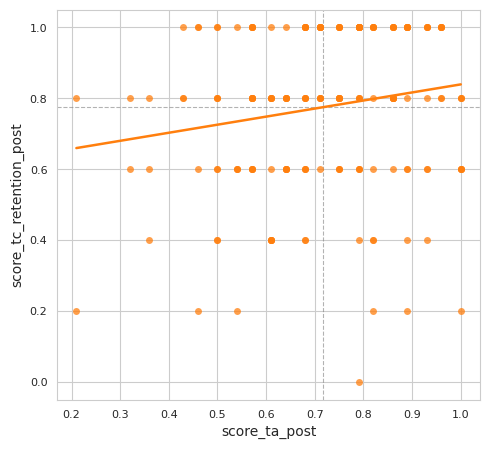

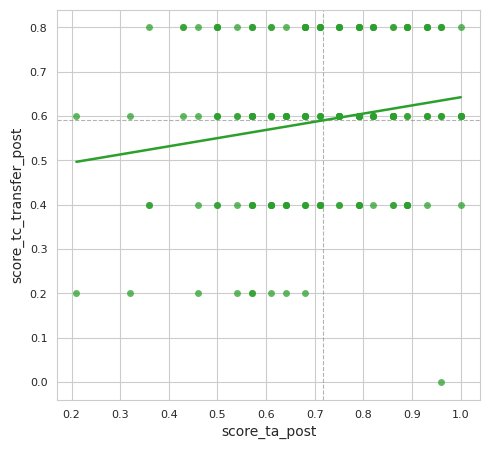

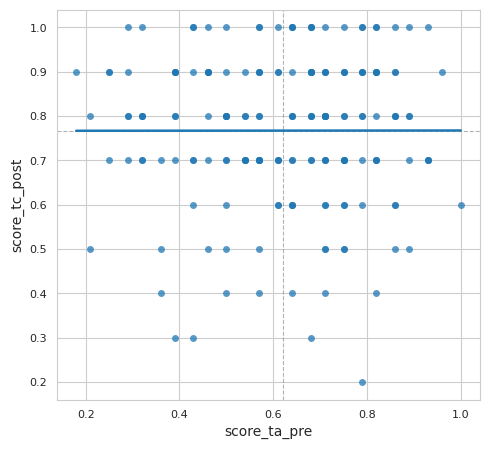

In [84]:
# Autoeficacia final frente a rendimiento final: es la relación que estima
# el modelo score_tc_post ~ score_ta_post + score_tc_pre + score_ta_pre
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_post", "score_tc_post")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_post_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_post", "score_tc_retention_post")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_post_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_post", "score_tc_transfer_post")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_post_transfer.pdf')
)

# Autoeficacia PREVIA frente a rendimiento final: ilustra el coeficiente
# negativo del modelo, que es el hallazgo más destacable de la sección
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_pre", "score_tc_post")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_pre_vs_post_score.pdf')
)

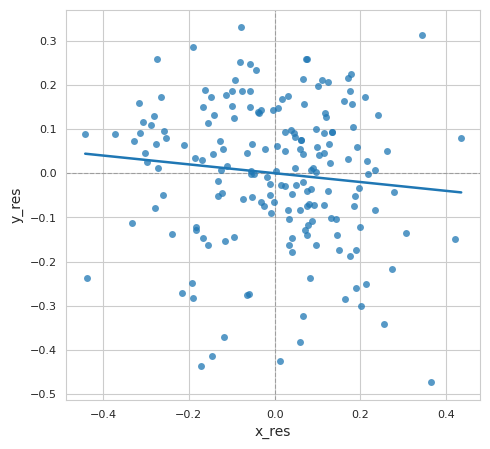

In [85]:
import statsmodels.formula.api as smf

d = (forms_interactions_df.to_pandas()
     if hasattr(forms_interactions_df, 'to_pandas')
     else forms_interactions_df.copy())
d = d.dropna(subset=['score_tc_post','score_ta_post','score_tc_pre','score_ta_pre'])

# Residualizar ambos ejes respecto a los demás predictores del modelo
rest = "score_ta_post + score_tc_pre"
d['y_res'] = smf.ols(f"score_tc_post ~ {rest}", d).fit().resid
d['x_res'] = smf.ols(f"score_ta_pre  ~ {rest}", d).fit().resid

plot_quant_scatter(
    pl.DataFrame(d), comparisons=[("x_res", "y_res")],
    palette="tab10", alpha=0.75, bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False, subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_pre_partial.pdf')
)

In [86]:
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

TA_PRE, TA_POST = 'score_ta_pre', 'score_ta_post'
TC_PRE, TC_POST = 'score_tc_pre', 'score_tc_post'
GROUP, PROFILE = 'group', 'group_segmented_quality'
ORDER = ['control', 'ExpA', 'ExpB', 'ExpNotUsed']

d = df.dropna(subset=[TA_PRE, TA_POST, TC_PRE, TC_POST, GROUP, 'school']).copy()
d['group_binary'] = (d[GROUP] == 'experimental').astype(int)
for c in [TA_PRE, TA_POST, TC_PRE, TC_POST]:
    d[c + '_c'] = d[c] - d[c].mean()
order = [g for g in ORDER if g in d[PROFILE].astype(str).unique()]
d[PROFILE] = d[PROFILE].astype(str)

print(f"n = {len(d)} | schools = {d['school'].nunique()}")
print(f"rango observado TA: pre [{d[TA_PRE].min():.2f}, {d[TA_PRE].max():.2f}], "
      f"post [{d[TA_POST].min():.2f}, {d[TA_POST].max():.2f}]\n")


def fit(formula, data=None, label=""):
    dd = data if data is not None else d
    res = smf.mixedlm(formula, dd, groups=dd['school'], re_formula="1").fit(reml=True)
    ci = res.conf_int()
    print(f"\n--- {label} (n = {len(dd)}) ---")
    print(f"  {formula} + (1 | school)")
    for t in res.params.index:
        if t in ('Intercept', 'Group Var'):
            continue
        print(f"  {t:<34} beta = {res.params[t]:+.4f} (SE {res.bse[t]:.4f}, "
              f"p {res.pvalues[t]:.4f}, 95% CI [{ci.loc[t,0]:+.4f}, {ci.loc[t,1]:+.4f}])")
    vs, vr = float(res.cov_re.iloc[0, 0]), float(res.scale)
    print(f"  ICC = {vs/(vs+vr):.4f} | converged = {res.converged}")
    return res


# ================== DESCRIPTIVOS ==================
print("--- Autoeficacia por condición y momento ---")
print(d.melt(id_vars=GROUP, value_vars=[TA_PRE, TA_POST],
             var_name='moment', value_name='score')
       .groupby(['moment', GROUP])['score']
       .agg(n='size', mean='mean', sd='std', median='median',
            q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75),
            min='min', max='max').round(4), "\n")

print("--- Por perfil de uso ---")
print(d.groupby(PROFILE).agg(
    n=(TA_POST, 'size'),
    ta_pre=(TA_PRE, 'mean'), ta_post=(TA_POST, 'mean'),
    change=(TA_POST, lambda s: (d.loc[s.index, TA_POST]
                                - d.loc[s.index, TA_PRE]).mean())
).reindex(order).round(4), "\n")

d['ta_delta'] = d[TA_POST] - d[TA_PRE]
print("--- Dirección del cambio en autoeficacia ---")
print(d.groupby(PROFILE)['ta_delta'].agg(
    up=lambda s: (s > 0).mean(), same=lambda s: (s == 0).mean(),
    down=lambda s: (s < 0).mean()).reindex(order).round(3), "\n")

print("--- Techo en el post ---")
print(d.groupby(GROUP)[TA_POST].agg(
    at_max=lambda s: (s >= 0.999).mean(), ge_09=lambda s: (s >= 0.9).mean()).round(3), "\n")

print(f"correlación TA pre-post: "
      f"exp {d[d.group_binary==1][TA_PRE].corr(d[d.group_binary==1][TA_POST]):.3f}, "
      f"ctrl {d[d.group_binary==0][TA_PRE].corr(d[d.group_binary==0][TA_POST]):.3f}\n")


# ================== 1. EFECTO DE LA CONDICIÓN ==================
print("=" * 62); print("1. Efecto de la condición sobre la autoeficacia final")
fit(f"{TA_POST} ~ group_binary + {TA_PRE}_c", label="M2: condición")
fit(f"{TA_POST} ~ group_binary * {TA_PRE}_c", label="M3: moderación por autoeficacia previa")

# Ajustando también por conocimiento previo: ¿el efecto es de la herramienta
# o del rendimiento con el que llegaban?
fit(f"{TA_POST} ~ group_binary + {TA_PRE}_c + {TC_PRE}_c",
    label="M2 + conocimiento previo")


# ================== 2. EFECTO DEL PERFIL DE USO ==================
print("\n" + "=" * 62); print("2. Efecto del perfil de uso")
term = f"C({PROFILE}, Treatment(reference='control'))"
fit(f"{TA_POST} ~ {term} + {TA_PRE}_c", label="M2: perfil vs control")
fit(f"{TA_POST} ~ C({PROFILE}, Treatment(reference='ExpA')) + {TA_PRE}_c",
    label="M2: perfil vs ExpA")

# Ómnibus
def lr(f_full, f_null, k, lbl, data=None):
    dd = data if data is not None else d
    def _llf(f):
        return smf.mixedlm(f, dd, groups=dd['school'], re_formula="1").fit(reml=False).llf
    v = 2 * (_llf(f_full) - _llf(f_null))
    print(f"{lbl}: chi2 = {v:.4f}, df = {k}, p = {stats.chi2.sf(v, k):.4f}")

lr(f"{TA_POST} ~ {term} + {TA_PRE}_c", f"{TA_POST} ~ {TA_PRE}_c",
   len(order) - 1, "\nOmnibus perfil (TA post)")


# ================== 3. WSDI Y AUTOEFICACIA ==================
print("\n" + "=" * 62); print("3. ¿Predice la profundidad de interacción la autoeficacia final?")
u = d[(d[GROUP] == 'experimental') & d['WSDI'].notna()].copy()
u['WSDI_c'] = u['WSDI'] - u['WSDI'].mean()
fit(f"{TA_POST} ~ WSDI_c + {TA_PRE}_c", data=u, label="WSDI -> autoeficacia final")
fit(f"{TA_POST} ~ WSDI_c + {TA_PRE}_c + {TC_POST}_c", data=u,
    label="WSDI -> autoeficacia, ajustado por rendimiento final")


# ================== 4. CONOCIMIENTO Y AUTOEFICACIA ==================
print("\n" + "=" * 62); print("4. Relación entre autoeficacia y rendimiento")
# Sustituye la correlación entre ganancias de Hake
fit(f"{TC_POST} ~ {TA_POST}_c + {TC_PRE}_c + {TA_PRE}_c",
    label="¿Acompaña la autoeficacia final al rendimiento final?")
fit(f"{TC_POST} ~ {TA_PRE}_c + {TC_PRE}_c",
    label="¿Predice la autoeficacia PREVIA el rendimiento final?")


# ================== 5. CALIBRACIÓN ==================
# ¿Se corresponde la confianza con el rendimiento real? Y ¿está mejor
# calibrada entre quienes interactuaron en profundidad?
print("\n" + "=" * 62); print("5. Calibración: ¿refleja la confianza el rendimiento real?")
d['ta_z'] = (d[TA_POST] - d[TA_POST].mean()) / d[TA_POST].std(ddof=1)
d['tc_z'] = (d[TC_POST] - d[TC_POST].mean()) / d[TC_POST].std(ddof=1)
d['miscal'] = d['ta_z'] - d['tc_z']          # >0: se sobrevalora
d['miscal_abs'] = d['miscal'].abs()          # magnitud del desajuste

print("\nDesajuste medio (z autoeficacia - z rendimiento), por perfil:")
print(d.groupby(PROFILE)[['miscal', 'miscal_abs']].mean().reindex(order).round(3))
print("\ncorrelación autoeficacia-rendimiento (post) por perfil:")
for g in order:
    s = d[d[PROFILE] == g]
    print(f"  {g:<12} n = {len(s):>3} | r = {s[TA_POST].corr(s[TC_POST]):+.3f}")

fit(f"miscal_abs ~ {term}", label="¿Difiere la magnitud del desajuste por perfil?")
u['miscal_abs'] = d.loc[u.index, 'miscal_abs']
fit("miscal_abs ~ WSDI_c", data=u, label="¿Mejora la calibración con la profundidad?")

n = 183 | schools = 4
rango observado TA: pre [0.18, 1.00], post [0.21, 1.00]

--- Autoeficacia por condición y momento ---
                             n    mean      sd  median    q1     q3   min  \
moment        group                                                         
score_ta_post control       95  0.7011  0.1543    0.68  0.61  0.805  0.21   
              experimental  88  0.7323  0.1803    0.77  0.57  0.860  0.21   
score_ta_pre  control       95  0.5755  0.1877    0.61  0.43  0.710  0.18   
              experimental  88  0.6703  0.1632    0.71  0.57  0.790  0.25   

                             max  
moment        group               
score_ta_post control       1.00  
              experimental  1.00  
score_ta_pre  control       0.93  
              experimental  1.00   

--- Por perfil de uso ---
                          n  ta_pre  ta_post  change
group_segmented_quality                             
control                  95  0.5755   0.7011  0.1256
ExpA            

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat


--- M3: moderación por autoeficacia previa (n = 183) ---
  score_ta_post ~ group_binary * score_ta_pre_c + (1 | school)
  group_binary                       beta = +0.0060 (SE 0.0229, p 0.7939, 95% CI [-0.0390, +0.0509])
  score_ta_pre_c                     beta = +0.2189 (SE 0.0862, p 0.0112, 95% CI [+0.0498, +0.3879])
  group_binary:score_ta_pre_c        beta = +0.0693 (SE 0.1282, p 0.5889, 95% CI [-0.1820, +0.3205])
  ICC = 0.2040 | converged = False

--- M2 + conocimiento previo (n = 183) ---
  score_ta_post ~ group_binary + score_ta_pre_c + score_tc_pre_c + (1 | school)
  group_binary                       beta = +0.0062 (SE 0.0229, p 0.7859, 95% CI [-0.0387, +0.0512])
  score_ta_pre_c                     beta = +0.2479 (SE 0.0665, p 0.0002, 95% CI [+0.1175, +0.3783])
  score_tc_pre_c                     beta = +0.0561 (SE 0.0661, p 0.3964, 95% CI [-0.0735, +0.1857])
  ICC = 0.1569 | converged = True

2. Efecto del perfil de uso

--- M2: perfil vs control (n = 183) ---
  score_ta

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat


--- M2: perfil vs ExpA (n = 183) ---
  score_ta_post ~ C(group_segmented_quality, Treatment(reference='ExpA')) + score_ta_pre_c + (1 | school)
  C(group_segmented_quality, Treatment(reference='ExpA'))[T.ExpB] beta = -0.0225 (SE 0.0397, p 0.5710, 95% CI [-0.1003, +0.0553])
  C(group_segmented_quality, Treatment(reference='ExpA'))[T.ExpNotUsed] beta = +0.0035 (SE 0.0450, p 0.9376, 95% CI [-0.0847, +0.0917])
  C(group_segmented_quality, Treatment(reference='ExpA'))[T.control] beta = -0.0141 (SE 0.0348, p 0.6858, 95% CI [-0.0822, +0.0541])
  score_ta_pre_c                     beta = +0.2583 (SE 0.0670, p 0.0001, 95% CI [+0.1269, +0.3896])
  ICC = 0.1363 | converged = False


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 2.636833
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter spa


Omnibus perfil (TA post): chi2 = 0.2529, df = 3, p = 0.9686

3. ¿Predice la profundidad de interacción la autoeficacia final?

--- WSDI -> autoeficacia final (n = 61) ---
  score_ta_post ~ WSDI_c + score_ta_pre_c + (1 | school)
  WSDI_c                             beta = +0.0434 (SE 0.0320, p 0.1752, 95% CI [-0.0193, +0.1061])
  score_ta_pre_c                     beta = +0.3796 (SE 0.1414, p 0.0072, 95% CI [+0.1025, +0.6567])
  ICC = 0.1109 | converged = False

--- WSDI -> autoeficacia, ajustado por rendimiento final (n = 61) ---
  score_ta_post ~ WSDI_c + score_ta_pre_c + score_tc_post_c + (1 | school)
  WSDI_c                             beta = +0.0229 (SE 0.0330, p 0.4888, 95% CI [-0.0419, +0.0876])
  score_ta_pre_c                     beta = +0.4193 (SE 0.1403, p 0.0028, 95% CI [+0.1444, +0.6942])
  score_tc_post_c                    beta = +0.2500 (SE 0.1478, p 0.0908, 95% CI [-0.0397, +0.5397])
  ICC = 0.1697 | converged = True

4. Relación entre autoeficacia y rendimiento


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/fabio/fabio_scielzo


--- ¿Acompaña la autoeficacia final al rendimiento final? (n = 183) ---
  score_tc_post ~ score_ta_post_c + score_tc_pre_c + score_ta_pre_c + (1 | school)
  score_ta_post_c                    beta = +0.1947 (SE 0.0769, p 0.0114, 95% CI [+0.0439, +0.3455])
  score_tc_pre_c                     beta = +0.2083 (SE 0.0681, p 0.0022, 95% CI [+0.0749, +0.3417])
  score_ta_pre_c                     beta = -0.1359 (SE 0.0680, p 0.0456, 95% CI [-0.2692, -0.0027])
  ICC = 0.1516 | converged = True

--- ¿Predice la autoeficacia PREVIA el rendimiento final? (n = 183) ---
  score_tc_post ~ score_ta_pre_c + score_tc_pre_c + (1 | school)
  score_ta_pre_c                     beta = -0.0888 (SE 0.0663, p 0.1809, 95% CI [-0.2188, +0.0413])
  score_tc_pre_c                     beta = +0.2179 (SE 0.0688, p 0.0015, 95% CI [+0.0830, +0.3528])
  ICC = 0.1827 | converged = True

5. Calibración: ¿refleja la confianza el rendimiento real?

Desajuste medio (z autoeficacia - z rendimiento), por perfil:
          

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### Cognitive load

In [87]:
cognitive_load_path = os.path.join(plots_path, '5_2', '5_2_4')
os.makedirs(cognitive_load_path, exist_ok=True)

In [88]:
# plot_cat_comparison(
#     df=forms_interactions_df, 
#     comparisons=[
#         ['score_tcc_rel_cat_post'], ['score_tcc_ext_cat_post'], ['score_tcc_int_cat_post'],
#     ], 
#     title=None,
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='group',
#     order=["Low", "Medium", "High"],
#     hue_order=['experimental', 'control'],
#     save_path=os.path.join(cognitive_load_path, 'tcc_levels.pdf')
# )

In [89]:
# plot_cat_comparison(
#     df=forms_interactions_df, 
#     comparisons=[
#         ['score_tcc_rel_cat_post'], ['score_tcc_ext_cat_post'], ['score_tcc_int_cat_post'],
#     ], 
#     title=None,
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='group_segmented_quality',
#     order=["Low", "Medium", "High"],
#     save_path=os.path.join(cognitive_load_path, 'tcc_levels_quality.pdf')
# )

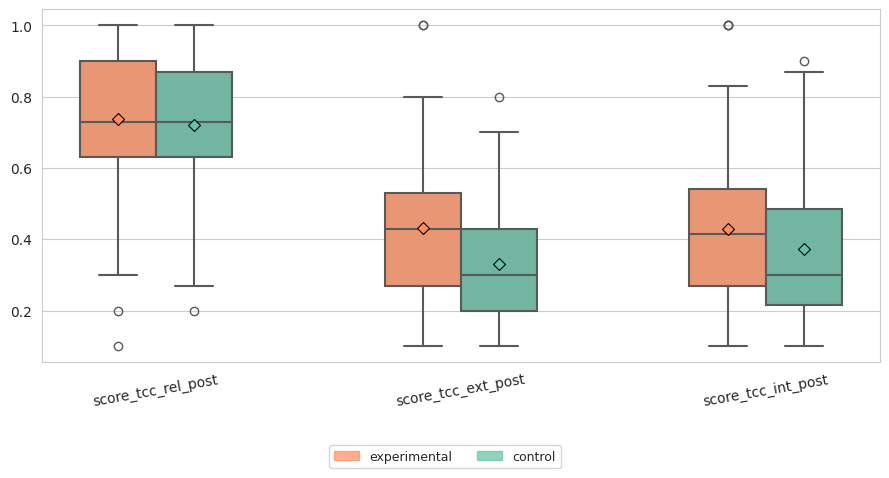

In [90]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_comparison.pdf')
)

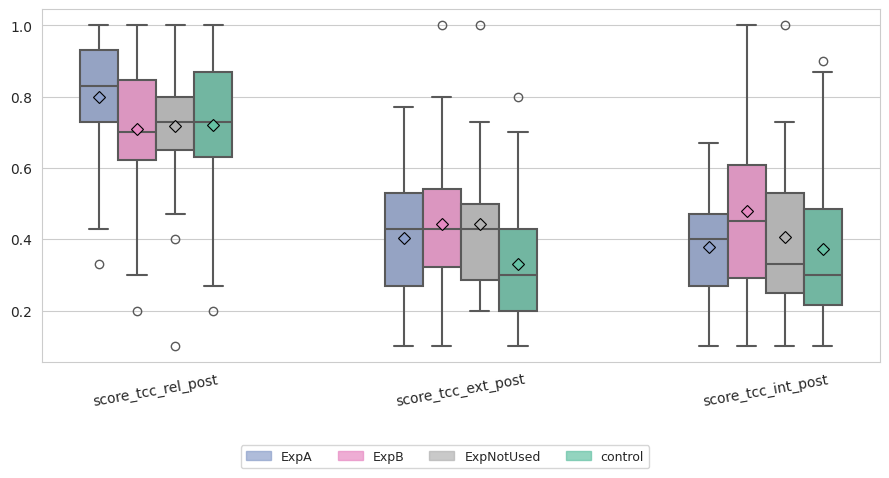

In [91]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_comparison_quality.pdf')
)

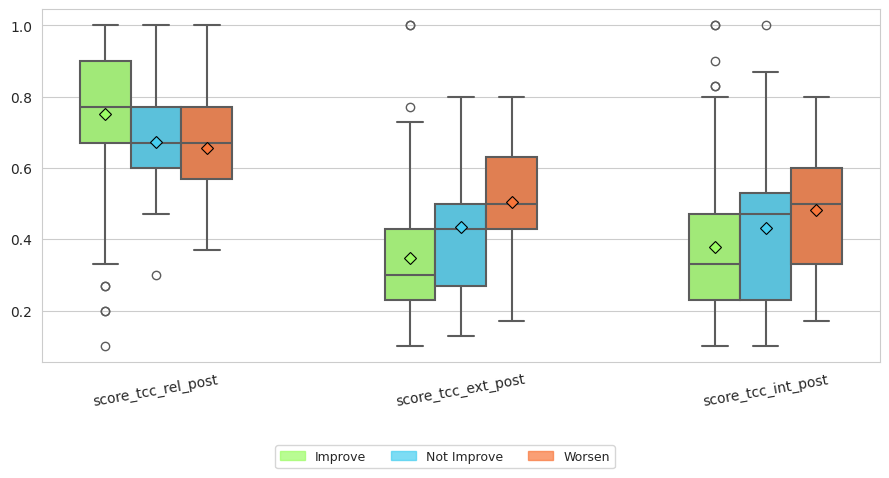

In [92]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='improvement_hake_gain',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_mejora.pdf')
)

In [93]:
# ================== PREPARACIÓN ==================
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

DIMS = {'score_tcc_int_post': 'intrinsic',
        'score_tcc_ext_post': 'extraneous',
        'score_tcc_rel_post': 'germane'}
PROF = 'group_segmented_quality'
PROFILES = ['control', 'ExpA', 'ExpB', 'ExpNotUsed']
IMPROVEMENT = ['Improve', 'No change', 'Worsen']

d = df.dropna(subset=list(DIMS) + ['group', 'school',
                                   'score_tc_pre', 'score_tc_post']).copy()
d['group_binary'] = (d['group'] == 'experimental').astype(int)
d['tc_pre_c'] = d['score_tc_pre'] - d['score_tc_pre'].mean()
d['ta_pre_c'] = d['score_ta_pre'] - d['score_ta_pre'].mean()
d['change'] = d['score_tc_post'] - d['score_tc_pre']
d['improvement'] = np.select([d['change'] > 0, d['change'] < 0],
                             ['Improve', 'Worsen'], default='No change')
for col, name in DIMS.items():
    d[f'{name}_c'] = d[col] - d[col].mean()

print(f"n = {len(d)} | schools = {d['school'].nunique()} | "
      f"exp = {d['group_binary'].sum()} | ctrl = {(1 - d['group_binary']).sum()}")


# ================== FUNCIONES ==================
def icc_of(res):
    vs, vr = float(res.cov_re.iloc[0, 0]), float(res.scale)
    return vs / (vs + vr)

def fit(formula, data, reml=True):
    return smf.mixedlm(formula, data, groups=data['school'],
                       re_formula="1").fit(reml=reml)

def show(res, terms, label):
    ci = res.conf_int()
    print(f"\n--- {label} (n = {int(res.nobs)}) ---")
    for t, name in terms.items():
        if t in res.params.index:
            print(f"  {name:<34} beta = {res.params[t]:+.4f} "
                  f"(SE {res.bse[t]:.4f}, p {res.pvalues[t]:.4f}, "
                  f"95% CI [{ci.loc[t,0]:+.4f}, {ci.loc[t,1]:+.4f}])")
    print(f"  ICC = {icc_of(res):.4f} | converged = {res.converged}")

def lr_test(full, reduced, data, df_diff):
    m1, m0 = fit(full, data, reml=False), fit(reduced, data, reml=False)
    lr = 2 * (m1.llf - m0.llf)
    return lr, df_diff, stats.chi2.sf(lr, df_diff)

def hedges_g(a, b):
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1-1)*a.var(ddof=1) + (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    g = (a.mean() - b.mean()) / sp * (1 - 3 / (4*(n1+n2) - 9))
    se = np.sqrt((n1+n2)/(n1*n2) + g**2 / (2*(n1+n2)))
    return g, g - 1.96*se, g + 1.96*se

def stability(formula, data, terms):
    """Reajusta con varios optimizadores y compara los efectos fijos."""
    out = {}
    for m in [None, ['lbfgs'], ['powell'], ['cg']]:
        try:
            kw = {} if m is None else {'method': m}
            r = smf.mixedlm(formula, data, groups=data['school'],
                            re_formula="1").fit(reml=True, **kw)
            out[str(m)] = r.params[list(terms)]
        except Exception as e:
            out[str(m)] = f"falla: {type(e).__name__}"
    ok = [v for v in out.values() if isinstance(v, pd.Series)]
    if len(ok) > 1:
        diff = pd.concat(ok, axis=1).apply(lambda r: r.max() - r.min(), axis=1)
        print(f"  [estabilidad] máx. diferencia entre optimizadores: "
              f"{diff.max():.6f} ({len(ok)} ajustes válidos)")
    for k, v in out.items():
        if not isinstance(v, pd.Series):
            print(f"  [estabilidad] {k}: {v}")


# ================== 0. DESCRIPTIVOS ==================
q = lambda p: (lambda s: s.quantile(p))
agg = dict(n='size', mean='mean', sd='std', median='median',
           q1=q(0.25), q3=q(0.75))

print("\n=== Descriptivos por condición ===")
for col, name in DIMS.items():
    print(f"\n{name}:")
    print(d.groupby('group')[col].agg(**agg).round(3))

print("\n=== Descriptivos por perfil de uso ===")
for col, name in DIMS.items():
    print(f"\n{name}:")
    print(d.groupby(PROF)[col].agg(**agg).reindex(PROFILES).round(3))

print("\n=== Correlaciones entre dimensiones (muestra completa) ===")
print(d[list(DIMS)].rename(columns=DIMS).corr().round(3))


# ================== C1. CONDICIÓN (M1, sin covariable) ==================
print("\n" + "=" * 62)
print("C1: ¿difieren las cargas entre condiciones?")
print("=" * 62)
pvals, rows = [], []
for col, name in DIMS.items():
    f = f"{col} ~ group_binary"
    res = fit(f, d)
    show(res, {'group_binary': 'Experimental vs control'}, f"C1 {name}")
    g, lo, hi = hedges_g(d.loc[d['group_binary'] == 1, col],
                         d.loc[d['group_binary'] == 0, col])
    print(f"  Hedges' g = {g:+.3f} (95% CI [{lo:+.3f}, {hi:+.3f}])")
    if not res.converged:
        stability(f, d, ['group_binary'])
    pvals.append(res.pvalues['group_binary']); rows.append(name)
holm = multipletests(pvals, method='holm')[1]
print("\nHolm a través de las tres dimensiones:")
for n_, p_, h_ in zip(rows, pvals, holm):
    print(f"  {n_:<12} p = {p_:.4f} -> p_holm = {h_:.4f}")


# ================== C1b. SENSIBILIDAD: AJUSTE POR VARIABLES PREVIAS ==================
print("\n" + "=" * 62)
print("C1b: ¿se mantiene la diferencia al ajustar por conocimiento y autoeficacia previos?")
print("=" * 62)
db = d.dropna(subset=['ta_pre_c'])
for col, name in DIMS.items():
    f = f"{col} ~ group_binary + tc_pre_c + ta_pre_c"
    res = fit(f, db)
    show(res, {'group_binary': 'Experimental vs control',
               'tc_pre_c': 'Prior knowledge',
               'ta_pre_c': 'Baseline self-efficacy'},
         f"C1b {name}")
    if not res.converged:
        stability(f, db, ['group_binary'])


# ================== C2. PERFIL DE USO ==================
print("\n" + "=" * 62)
print("C2: ¿dependen las cargas del perfil de uso?")
print("=" * 62)
for col, name in DIMS.items():
    term = f"C({PROF}, Treatment(reference='control'))"
    f = f"{col} ~ {term}"
    res = fit(f, d)
    labels = {f"{term}[T.{p}]": f"{p} vs control" for p in PROFILES[1:]}
    show(res, labels, f"C2 {name} (ref = control)")
    ps = [res.pvalues[k] for k in labels]
    print("  Holm (3 contrastes vs control): "
          + ", ".join(f"{p.split()[0]} {h:.4f}"
                      for p, h in zip(labels.values(),
                                      multipletests(ps, method='holm')[1])))
    if not res.converged:
        stability(f, d, list(labels))

    term_a = f"C({PROF}, Treatment(reference='ExpA'))"
    f_a = f"{col} ~ {term_a}"
    res_a = fit(f_a, d)
    labels_a = {f"{term_a}[T.ExpB]": "ExpB vs ExpA",
                f"{term_a}[T.ExpNotUsed]": "ExpNotUsed vs ExpA"}
    show(res_a, labels_a, f"C2 {name} (ref = ExpA, secundarios)")
    if not res_a.converged:
        stability(f_a, d, list(labels_a))

    lr, df_, p = lr_test(f, f"{col} ~ 1", d, 3)
    print(f"  Omnibus LR: chi2 = {lr:.4f}, df = {df_}, p = {p:.4f}")


# ================== C3. PROFUNDIDAD DE INTERACCIÓN (usuarios) ==================
print("\n" + "=" * 62)
print("C3: ¿dependen las cargas de la profundidad de interacción? (usuarios)")
print("=" * 62)
u = d[d['WSDI'].notna()].copy()
u['WSDI_c'] = u['WSDI'] - u['WSDI'].mean()
u['nq_c'] = u['chat_interactions_counts'] - u['chat_interactions_counts'].mean()
for col, name in DIMS.items():
    f = f"{col} ~ WSDI_c"
    res = fit(f, u)
    show(res, {'WSDI_c': 'WSDI, per point'}, f"C3 {name} ~ WSDI")
    if not res.converged:
        stability(f, u, ['WSDI_c'])

    f2 = f"{col} ~ WSDI_c + nq_c"
    res2 = fit(f2, u)
    show(res2, {'WSDI_c': 'WSDI, per point', 'nq_c': 'Number of queries'},
         f"C3 {name} ~ WSDI + n_queries")
    if not res2.converged:
        stability(f2, u, ['WSDI_c', 'nq_c'])


# ================== C4. CARGA Y APRENDIZAJE ==================
print("\n" + "=" * 62)
print("C4: ¿se asocian las cargas con el rendimiento final?")
print("=" * 62)
f = ("score_tc_post ~ intrinsic_c + extraneous_c + germane_c "
     "+ tc_pre_c + group_binary")
res = fit(f, d)
show(res, {'intrinsic_c': 'Intrinsic load', 'extraneous_c': 'Extraneous load',
           'germane_c': 'Germane load', 'tc_pre_c': 'Prior knowledge',
           'group_binary': 'Experimental vs control'},
     "C4 post knowledge ~ three loads + pre + group")
if not res.converged:
    stability(f, d, ['intrinsic_c', 'extraneous_c', 'germane_c', 'group_binary'])

print("\n--- ¿Atenúa la carga extrínseca la diferencia entre condiciones? ---")
k1 = fit("score_tc_post ~ group_binary + tc_pre_c", d)
k1e = fit("score_tc_post ~ group_binary + tc_pre_c + extraneous_c", d)
for lbl, r in [('K1 (sin carga)', k1), ('K1 + carga extrínseca', k1e)]:
    ci = r.conf_int().loc['group_binary']
    print(f"  {lbl:<24} beta_group = {r.params['group_binary']:+.4f} "
          f"(p {r.pvalues['group_binary']:.4f}, "
          f"95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]) | converged = {r.converged}")
b0, b1 = k1.params['group_binary'], k1e.params['group_binary']
print(f"  atenuación relativa = {(b0 - b1) / b0:.1%}")
show(k1e, {'extraneous_c': 'Extraneous load'}, "K1 + extraneous (término de carga)")


# ================== C5. VALIDEZ: CARGA INTRÍNSECA Y CONOCIMIENTO PREVIO ==================
print("\n" + "=" * 62)
print("C5: ¿baja la carga intrínseca con el conocimiento previo?")
print("=" * 62)
f = "score_tcc_int_post ~ tc_pre_c + group_binary"
res = fit(f, d)
show(res, {'tc_pre_c': 'Prior knowledge',
           'group_binary': 'Experimental vs control'},
     "C5 intrinsic ~ pre + group")
if not res.converged:
    stability(f, d, ['tc_pre_c', 'group_binary'])
print(f"  correlación simple intrinsic-pre: "
      f"r = {d['score_tcc_int_post'].corr(d['score_tc_pre']):+.3f}")


# ================== C6. CATEGORÍA DE MEJORA ==================
print("\n" + "=" * 62)
print("C6: cargas por categoría de mejora (post - pre)")
print("=" * 62)
print(d['improvement'].value_counts().reindex(IMPROVEMENT))
if 'improvement_hake_gain' in d.columns:
    print("\n(comprobación) coincidencia con la categoría basada en Hake:")
    print(pd.crosstab(d['improvement'], d['improvement_hake_gain']))
for col, name in DIMS.items():
    print(f"\n{name}:")
    print(d.groupby('improvement')[col].agg(**agg).reindex(IMPROVEMENT).round(3))
    lr, df_, p = lr_test(f"{col} ~ C(improvement)", f"{col} ~ 1", d,
                         d['improvement'].nunique() - 1)
    print(f"  Omnibus LR: chi2 = {lr:.4f}, df = {df_}, p = {p:.4f}")

n = 183 | schools = 4 | exp = 88 | ctrl = 95

=== Descriptivos por condición ===

intrinsic:
               n   mean     sd  median     q1     q3
group                                               
control       95  0.372  0.198   0.300  0.215  0.485
experimental  88  0.429  0.216   0.415  0.270  0.540

extraneous:
               n   mean     sd  median    q1    q3
group                                             
control       95  0.331  0.160    0.30  0.20  0.43
experimental  88  0.432  0.189    0.43  0.27  0.53

germane:
               n   mean     sd  median    q1    q3
group                                             
control       95  0.721  0.168    0.73  0.63  0.87
experimental  88  0.737  0.194    0.73  0.63  0.90

=== Descriptivos por perfil de uso ===

intrinsic:
                          n   mean     sd  median     q1     q3
group_segmented_quality                                        
control                  95  0.372  0.198    0.30  0.215  0.485
ExpA                

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/fabio/fabio_scielzo


--- C1 intrinsic (n = 183) ---
  Experimental vs control            beta = +0.0597 (SE 0.0301, p 0.0478, 95% CI [+0.0006, +0.1188])
  ICC = 0.0565 | converged = False
  Hedges' g = +0.273 (95% CI [-0.018, +0.564])


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.538407
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter spa

  [estabilidad] máx. diferencia entre optimizadores: 0.001405 (4 ajustes válidos)

--- C1 extraneous (n = 183) ---
  Experimental vs control            beta = +0.1025 (SE 0.0256, p 0.0001, 95% CI [+0.0522, +0.1528])
  ICC = 0.0207 | converged = True
  Hedges' g = +0.577 (95% CI [+0.281, +0.873])

--- C1 germane (n = 183) ---
  Experimental vs control            beta = +0.0128 (SE 0.0256, p 0.6156, 95% CI [-0.0373, +0.0630])
  ICC = 0.1485 | converged = True
  Hedges' g = +0.088 (95% CI [-0.202, +0.379])

Holm a través de las tres dimensiones:
  intrinsic    p = 0.0478 -> p_holm = 0.0956
  extraneous   p = 0.0001 -> p_holm = 0.0002
  germane      p = 0.6156 -> p_holm = 0.6156

C1b: ¿se mantiene la diferencia al ajustar por conocimiento y autoeficacia previos?


...

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


--- C5 intrinsic ~ pre + group (n = 183) ---
  Prior knowledge                    beta = -0.0715 (SE 0.0911, p 0.4328, 95% CI [-0.2500, +0.1071])
  Experimental vs control            beta = +0.0604 (SE 0.0302, p 0.0452, 95% CI [+0.0013, +0.1196])
  ICC = 0.0603 | converged = False
  [estabilidad] máx. diferencia entre optimizadores: 0.003980 (4 ajustes válidos)
  correlación simple intrinsic-pre: r = -0.086

C6: cargas por categoría de mejora (post - pre)
improvement
Improve      137
No change     21
Worsen        25
Name: count, dtype: int64

(comprobación) coincidencia con la categoría basada en Hake:
improvement_hake_gain  Improve  Not Improve  Worsen
improvement                                        
Improve                    137            0       0
No change                    0           21       0
Worsen                       0            0      25

intrinsic:


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/fabio/fabio_scielzo

               n   mean     sd  median    q1    q3
improvement                                       
Improve      137  0.379  0.203    0.33  0.23  0.47
No change     21  0.431  0.238    0.47  0.23  0.53
Worsen        25  0.483  0.197    0.50  0.33  0.60
  Omnibus LR: chi2 = 5.2874, df = 2, p = 0.0711

extraneous:
               n   mean     sd  median    q1    q3
improvement                                       
Improve      137  0.348  0.171    0.30  0.23  0.43
No change     21  0.433  0.197    0.43  0.27  0.50
Worsen        25  0.503  0.160    0.50  0.43  0.63
  Omnibus LR: chi2 = 18.7845, df = 2, p = 0.0001

germane:
               n   mean     sd  median    q1    q3
improvement                                       
Improve      137  0.750  0.182    0.77  0.67  0.90
No change     21  0.672  0.173    0.67  0.60  0.77
Worsen        25  0.657  0.154    0.67  0.57  0.77
  Omnibus LR: chi2 = 6.1143, df = 2, p = 0.0470


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimi

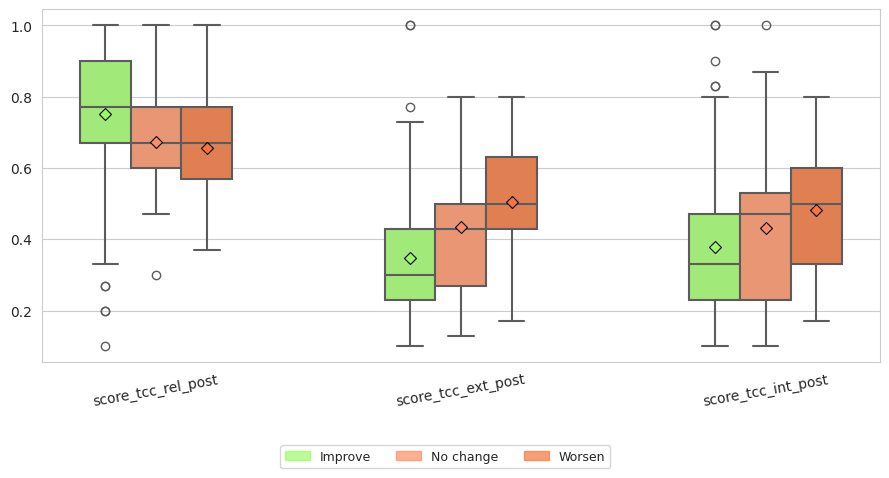

In [94]:
# ================== FIGURA POR CATEGORÍA DE MEJORA (sin Hake) ==================
plot_quant_comparison(
    figsize=(9, 4),
    df=pl.DataFrame(d),
    comparisons=[['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']],
    group_by='improvement',
    order=IMPROVEMENT,
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_mejora.pdf')
)

In [95]:
# ================== PREPARACIÓN ==================
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())
df = df[~df['id'].isin(problematic_ids)].copy()

PRE, POST = 'score_ta_pre', 'score_ta_post'
PROF = 'group_segmented_quality'

d = df.dropna(subset=[PRE, POST, 'group', PROF]).copy()
d['change'] = d[POST] - d[PRE]
d['improved'] = (d['change'] > 0).astype(float)

print(f"n = {len(d)} | control = {(d['group'] == 'control').sum()} "
      f"| experimental = {(d['group'] == 'experimental').sum()}")


# ================== DESCRIPTIVOS ==================
def describe(sub):
    return pd.Series({
        'n':          len(sub),
        'pre_mean':   sub[PRE].mean(),
        'pre_sd':     sub[PRE].std(ddof=1),
        'pre_median': sub[PRE].median(),
        'post_mean':  sub[POST].mean(),
        'post_sd':    sub[POST].std(ddof=1),
        'post_median': sub[POST].median(),
        'change':     sub['change'].mean(),
        'pct_improving': 100 * sub['improved'].mean(),
    })

rows = {
    'Control':      d[d['group'] == 'control'],
    'Experimental': d[d['group'] == 'experimental'],
    'ExpA':         d[d[PROF] == 'ExpA'],
    'ExpB':         d[d[PROF] == 'ExpB'],
    'ExpNotUsed':   d[d[PROF] == 'ExpNotUsed'],
}
tab = pd.DataFrame({k: describe(v) for k, v in rows.items()}).T
print("\n--- Autoeficacia: descriptivos por condición y perfil ---")
print(tab.round(3))


# ================== FILAS LATEX ==================
def sgn(x):
    return f"$+{x:.3f}$" if x >= 0 else f"$-{abs(x):.3f}$"

print("\n--- Filas para tab:descriptives (bloque Self-efficacy) ---")
print(r"\multicolumn{8}{l}{\textit{Self-efficacy}} \\")
for name, r in tab.iterrows():
    label = name if name in ('Control', 'Experimental') else rf"\quad \texttt{{{name}}}"
    print(f"{label} & {int(r['n'])} & "
          f"{r['pre_mean']:.3f} ({r['pre_sd']:.3f}) & {r['pre_median']:.2f} & "
          f"{r['post_mean']:.3f} ({r['post_sd']:.3f}) & {r['post_median']:.2f} & "
          f"{sgn(r['change'])} & {r['pct_improving']:.1f} \\\\")

n = 183 | control = 95 | experimental = 88

--- Autoeficacia: descriptivos por condición y perfil ---
                 n  pre_mean  pre_sd  pre_median  post_mean  post_sd  \
Control       95.0     0.575   0.188        0.61      0.701    0.154   
Experimental  88.0     0.670   0.163        0.71      0.732    0.180   
ExpA          25.0     0.671   0.197        0.71      0.769    0.186   
ExpB          36.0     0.701   0.122        0.73      0.731    0.192   
ExpNotUsed    27.0     0.628   0.174        0.68      0.700    0.158   

              post_median  change  pct_improving  
Control              0.68   0.126         72.632  
Experimental         0.77   0.062         60.227  
ExpA                 0.82   0.098         76.000  
ExpB                 0.77   0.030         52.778  
ExpNotUsed           0.71   0.071         55.556  

--- Filas para tab:descriptives (bloque Self-efficacy) ---
\multicolumn{8}{l}{\textit{Self-efficacy}} \\
Control & 95 & 0.575 (0.188) & 0.61 & 0.701 (0.154) &

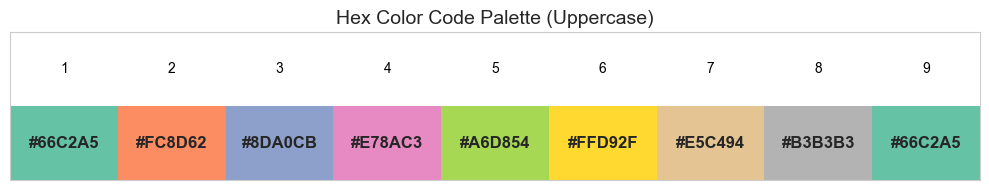

Uppercase hex palette:
['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3', '#A6D854', '#FFD92F', '#E5C494', '#B3B3B3', '#66C2A5']


In [213]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Get a color palette (any desired palette)
palette = sns.color_palette("Set2", 9)  # You can change this to any palette name

# Convert hex codes to uppercase
uppercase_palette = [mcolors.rgb2hex(color).upper() for color in palette]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Display colors
for i, color in enumerate(uppercase_palette):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none'))
    ax.text(i + 0.5, 0.5, color, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(i + 0.5, 1.5, str(i + 1), ha='center', va='center', fontsize=10, color='black')

ax.set_xlim(0, len(uppercase_palette))
ax.set_ylim(0, 2)
ax.set_title('Hex Color Code Palette (Uppercase)', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Print the palette for reference
print("Uppercase hex palette:")
print(uppercase_palette)